# 30-Month Work-Disability Risk in SLE
### Adapted from the 180-day post-chemo mortality survival pipeline

This notebook replicates the modeling pipeline of the original 180-day survival
notebook (LSTM, GRU, Logistic Regression, Random Survival Forest, Cox PH, plus
a cost-weighted threshold, confusion matrices, risk-sensitivity plots,
calibration, decision-curve analysis, and a SHAP dashboard) and retargets it at **systemic lupus erythematosus (SLE)**:

- **Outcome:** transition from `Employed` to `Disability Benefit` status
  (formal work disability), instead of 180-day mortality.
- **Horizon:** 30 months (≈913 days), instead of 180 days.
- **Data:** `sledatacutsdi.csv` (visit-level SLE registry extract with
  SLEDAI/SDI sub-scores and treatment fields), instead of the oncology
  `pcdata.csv`.
- **External validation is intentionally omitted**, per task instructions.

The landmarking and censoring logic below follows the "Step 1–3, as
implemented (v16)" specification supplied with this task: a growing-window
landmark set built from calendar-time visit gaps, with death (12-month) and
administrative-exit (6-month) censoring trims, and each landmark row
inverse-weighted by the number of landmarks contributed by its patient.

**Implementation note:** the sandbox this notebook was built in could not fit
both TensorFlow and PyTorch on disk, so the GRU/LSTM sequential models and all
denoising-autoencoder imputers use **PyTorch** rather than
TensorFlow/Keras — architecturally identical (2-layer recurrent
encoder-decoder, masked-MSE imputation loss; 2-layer recurrent classifier with
dropout + batch-norm and a time-distributed sigmoid head, trained on balanced
class minibatches) but a different framework.

**Decision-model update:**

- The fixed *85 % sensitivity* operating threshold has been replaced by a
  **cost-weighted decision model**. Every model's threshold is now the one that
  minimises `COST_FN * FN + COST_FP * FP` over the landmark set (`COST_FN`,
  `COST_FP` are set in the utilities cell). Only the *ratio* of the two costs
  changes the chosen threshold, so treat the defaults (5 : 1) as placeholders
  and set them from clinical / health-economic judgement.
- **Permutation feature importance** has been replaced, in every model, by
  **risk-sensitivity plots** (how the predicted 30-month risk moves as each
  feature is varied over its observed 5th–95th percentile range, all other
  features left as observed), and every model now also reports a
  **confusion matrix** at its cost-optimal threshold.


## Shared utilities (metrics, calibration, plotting, DAE imputer)

In [1]:
"""Shared utilities: metrics, calibration, plots -- mirrors the reporting
helpers used across every model in the original notebook (Wilson CIs,
cost-weighted threshold selection, calibration slope/intercept, decision
curve analysis, risk-distribution + calibration plot, confusion matrices,
risk-sensitivity plots)."""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (recall_score, confusion_matrix, balanced_accuracy_score,
                              brier_score_loss, roc_curve, auc, precision_recall_curve,
                              average_precision_score)
from sklearn.calibration import calibration_curve
from lifelines.utils import concordance_index
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler

sns.set_style("whitegrid")
OUT_DIR = "figs"


def wilson_ci(p, n, z=1.96):
    if n <= 0:
        return 0.0, 0.0
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    err = z * np.sqrt((p * (1 - p) / n) + (z**2 / (4 * n**2))) / denom
    return max(0, center - err), min(1, center + err)


# ---------------------------------------------------------------------------
# Cost-weighted decision model (replaces the fixed 85%-sensitivity threshold)
# ---------------------------------------------------------------------------
# Every alert decision is scored with an explicit misclassification cost:
#     total cost = COST_FN * (missed disability events)
#                + COST_FP * (unnecessary alerts)
# and the operating threshold is the one that minimises that cost. Only the
# RATIO COST_FN : COST_FP changes the chosen threshold. The defaults below are
# placeholders -- set them from clinical / health-economic judgement (e.g. the
# cost of missing an at-risk patient who then loses work vs. the cost of an
# unnecessary occupational-health referral).
# NB: risk scores are min-max standardised, so the threshold is a position on
# that 0-1 score, not a literal probability; it is therefore found empirically
# rather than from the closed-form cost_fp / (cost_fp + cost_fn) rule.
COST_FN = 9.0   # cost of a missed 30-month work-disability event (false negative)
COST_FP = 1.0   # cost of an unnecessary alert / intervention (false positive)


def cost_curve(y_true, risks, cost_fn=None, cost_fp=None, n_thresholds=1001):
    """Total misclassification cost at every candidate threshold."""
    cost_fn = COST_FN if cost_fn is None else cost_fn
    cost_fp = COST_FP if cost_fp is None else cost_fp
    y_true = np.asarray(y_true).astype(int)
    risks = np.asarray(risks, dtype=float)
    thresholds = np.linspace(0, 1, n_thresholds)
    pos_sorted = np.sort(risks[y_true == 1])
    neg_sorted = np.sort(risks[y_true == 0])
    fn = np.searchsorted(pos_sorted, thresholds, side="left")                       # pos with risk <  t
    fp = len(neg_sorted) - np.searchsorted(neg_sorted, thresholds, side="left")     # neg with risk >= t
    return thresholds, cost_fn * fn + cost_fp * fp


def find_cost_optimal_threshold(y_true, risks, cost_fn=None, cost_fp=None):
    """Threshold that minimises COST_FN*FN + COST_FP*FP (ties -> median of the tied thresholds)."""
    thresholds, costs = cost_curve(y_true, risks, cost_fn, cost_fp)
    tied = np.flatnonzero(costs == costs.min())
    return float(thresholds[tied[len(tied) // 2]])


def print_cost_metrics(model_name, y_true, y_pred, threshold, cost_fn=None, cost_fp=None):
    cost_fn = COST_FN if cost_fn is None else cost_fn
    cost_fp = COST_FP if cost_fp is None else cost_fp
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    n = tn + fp + fn + tp
    total = cost_fn * fn + cost_fp * fp
    alert_all = cost_fp * (tn + fp)      # alert everyone: every non-event is a false positive
    alert_none = cost_fn * (tp + fn)     # alert nobody: every event is a false negative
    best_default = min(alert_all, alert_none)
    saving = 1 - total / best_default if best_default > 0 else 0.0

    print("\n" + "=" * 70)
    print(f"{model_name} -- COST-WEIGHTED DECISION MODEL")
    print("-" * 70)
    print(f"{'Cost weights (FN : FP)':<38} | {cost_fn:g} : {cost_fp:g}")
    print(f"{'Cost-optimal threshold':<38} | {threshold:.3f}")
    print(f"{'TP / FP / FN / TN':<38} | {tp} / {fp} / {fn} / {tn}")
    print(f"{'Total expected cost':<38} | {total:.1f}")
    print(f"{'Cost per 100 landmarks':<38} | {100 * total / n:.2f}")
    print(f"{'Cost: alert-all / alert-none':<38} | {alert_all:.1f} / {alert_none:.1f}")
    print(f"{'Saving vs best default strategy':<38} | {saving:.1%}")
    print("=" * 70)


def calibration_stats(y_true, risks, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, risks, n_bins=n_bins)
    slope, intercept, r_value, p_value, std_err = stats.linregress(prob_pred, prob_true)
    return slope, intercept, r_value ** 2, prob_true, prob_pred


def report_comprehensive_metrics(model_name, y_true, y_pred, risks, c_idx, duration=None, event=None):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    slope, intercept, r2, _, _ = calibration_stats(y_true, risks)
    b_score = brier_score_loss(y_true, risks)

    metrics = {
        "Sensitivity": (tp / (tp + fn) if (tp + fn) > 0 else 0, tp + fn),
        "Specificity": (tn / (tn + fp) if (tn + fp) > 0 else 0, tn + fp),
        "PPV": (tp / (tp + fp) if (tp + fp) > 0 else 0, tp + fp),
        "NPV": (tn / (tn + fn) if (tn + fn) > 0 else 0, tn + fn),
        "Balanced Accuracy": (balanced_accuracy_score(y_true, y_pred), len(y_true)),
    }

    print("\n" + "=" * 78)
    print(f"{model_name} -- 30-MONTH WORK-DISABILITY RISK: COMPREHENSIVE METRICS")
    print("-" * 78)
    print(f"{'METRIC':<30} | {'VALUE':<10} | {'95% CI / INFO':<25}")
    print("-" * 78)
    print(f"{'Concordance Index':<30} | {c_idx:.4f}     | Discrimination")
    print(f"{'Brier Score':<30} | {b_score:.4f}     | Overall accuracy (lower=better)")
    print(f"{'Calibration Slope':<30} | {slope:.4f}     | Ideal = 1.0")
    print(f"{'Calibration Intercept':<30} | {intercept:.4f}     | Ideal = 0.0")
    for name, (val, n) in metrics.items():
        low, high = wilson_ci(val, n)
        print(f"{name:<30} | {val:.4f}     | [{low:.3f}, {high:.3f}]")
    print("=" * 78)
    return {"c_index": c_idx, "brier": b_score, "slope": slope, "intercept": intercept,
            **{k: v[0] for k, v in metrics.items()}}


def print_operational_metrics(model_name, metadata_df, y_pred_col="y_pred", label_col="label",
                               pid_col="pid", date_col="visit_date", pt=0.15):
    df = metadata_df.copy()
    n = len(df)
    alerts_per_100 = (df[y_pred_col].sum() / n) * 100
    prop_alert = df[y_pred_col].mean()

    tp_mask = (df[y_pred_col] == 1) & (df[label_col] == 1)
    tiw_tp, tiw_fp = [], []
    for pid, g in df.groupby(pid_col):
        alerts = g[g[y_pred_col] == 1]
        if not alerts.empty:
            duration = (g[date_col].max() - alerts[date_col].min()).days
            if g[label_col].any():
                tiw_tp.append(duration)
            else:
                tiw_fp.append(duration)

    tp = ((df[y_pred_col] == 1) & (df[label_col] == 1)).sum()
    fp = ((df[y_pred_col] == 1) & (df[label_col] == 0)).sum()
    net_benefit = (tp / n) - (fp / n) * (pt / (1 - pt))

    print("\n" + "=" * 70)
    print(f"{model_name} -- OPERATIONAL / CLINICAL-BURDEN METRICS")
    print("-" * 70)
    print(f"{'Alerts per 100 Patient-Visits':<35} | {alerts_per_100:.2f}")
    print(f"{'Proportion of Visits in Alert':<35} | {prop_alert:.2%}")
    print(f"{'Median Time-in-Warning (TP, days)':<35} | {np.median(tiw_tp) if tiw_tp else 0:.1f}")
    print(f"{'Median Time-in-Warning (FP, days)':<35} | {np.median(tiw_fp) if tiw_fp else 0:.1f}")
    print(f"{'Net Benefit (at pt=0.15)':<35} | {net_benefit:.4f}")
    print("=" * 70)


def plot_decision_curve(model_name, y_true, y_prob, color="#2c7da0", save=None):
    thresholds = np.linspace(0.01, 0.99, 100)
    n = len(y_true)
    net_benefit_model, net_benefit_all = [], []
    for t in thresholds:
        tp = np.sum((y_prob >= t) & (y_true == 1))
        fp = np.sum((y_prob >= t) & (y_true == 0))
        net_benefit_model.append((tp / n) - (fp / n) * (t / (1 - t)))
        tp_all, fp_all = np.sum(y_true == 1), np.sum(y_true == 0)
        net_benefit_all.append((tp_all / n) - (fp_all / n) * (t / (1 - t)))

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, net_benefit_model, label=f"{model_name}", color=color, lw=2)
    plt.plot(thresholds, net_benefit_all, label="Treat All", linestyle="--", color="gray", alpha=0.7)
    plt.axhline(0, label="Treat None", color="black", lw=1)
    plt.ylim(-0.05, max(0.05, max(net_benefit_model) * 1.2))
    plt.xlabel("Probability Threshold")
    plt.ylabel("Net Benefit")
    plt.title(f"Decision Curve Analysis -- {model_name}")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_risk_distribution_and_calibration(model_name, risks, y_true, threshold, color_pos="#e74c3c",
                                            color_neg="#3498db", save=None):
    fig, ax1 = plt.subplots(figsize=(10, 6))
    sns.histplot(risks[y_true == 1], color=color_pos, label="Disability within 30mo", kde=True,
                 bins=30, alpha=0.5, ax=ax1)
    sns.histplot(risks[y_true == 0], color=color_neg, label="No disability > 30mo", kde=True,
                 bins=30, alpha=0.3, ax=ax1)
    ax1.axvline(threshold, color="black", linestyle="--", label=f"Threshold: {threshold:.2f}")
    ax1.set_xlabel(f"{model_name} Standardized 30-Month Risk Score")
    ax1.set_ylabel("Landmark Count")

    ax2 = ax1.twinx()
    prob_true, prob_pred = calibration_curve(y_true, risks, n_bins=10)
    ax2.plot(prob_pred, prob_true, "s-", color="green", label="Observed")
    ax2.plot([0, 1], [0, 1], "k:", alpha=0.3)
    ax2.set_ylabel("Actual 30-Month Disability Rate")

    plt.title(f"30-Month Work-Disability Risk: Distribution & Calibration -- {model_name}")
    ax1.legend(loc="upper left")
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_performance_grid(model_name, y_true, y_prob, best_t, save=None):
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color="#444444", lw=2, label=f"AUC = {roc_auc:.2f}")
    axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--", alpha=0.6)
    axes[0].set_title("(a) ROC curve")
    axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
    axes[0].legend(loc="lower right")

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    axes[1].plot(recall, precision, color="#6b2d5c", lw=2, label=f"PR-AUC = {pr_auc:.3f}")
    axes[1].axhline(y=np.mean(y_true), color="gray", linestyle="--", alpha=0.6,
                     label=f"Baseline ({np.mean(y_true):.2f})")
    axes[1].set_title("(b) Precision-Recall curve")
    axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].legend(loc="upper right")

    thresholds = np.linspace(0, 1, 100)
    sens, spec, ppv, npv = [], [], [], []
    for t in thresholds:
        preds = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        sens.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        spec.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        ppv.append(tp / (tp + fp) if (tp + fp) > 0 else 0)
        npv.append(tn / (tn + fn) if (tn + fn) > 0 else 1)

    axes[2].plot(thresholds, sens, color="#2d6b6b", lw=2, label="Sensitivity")
    axes[2].plot(thresholds, spec, color="#8c564b", lw=2, label="Specificity")
    axes[2].axvline(best_t, color="#444444", linestyle="--", alpha=0.8, label=f"Thresh {best_t:.2f}")
    axes[2].set_title("(c) Sensitivity-specificity trade-off")
    axes[2].set_xlabel("Threshold"); axes[2].legend(loc="lower left")

    axes[3].plot(thresholds, ppv, color="#546e7a", lw=2, label="PPV")
    axes[3].plot(thresholds, npv, color="#7e57c2", lw=2, label="NPV")
    axes[3].axvline(best_t, color="#444444", linestyle="--", alpha=0.8, label="Thresh")
    axes[3].set_title("(d) PPV-NPV trade-off")
    axes[3].set_xlabel("Threshold"); axes[3].legend(loc="lower left")

    plt.suptitle(f"{model_name} -- Performance Grid (30-Month Work-Disability Risk)", y=1.03, fontsize=14)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_cost_decision_and_confusion(model_name, y_true, risks, threshold, cost_fn=None, cost_fp=None,
                                      save=None):
    """(a) cost-vs-threshold curve with the cost-optimal operating point,
    (b) confusion matrix at that threshold (counts + row-normalised %)."""
    cost_fn = COST_FN if cost_fn is None else cost_fn
    cost_fp = COST_FP if cost_fp is None else cost_fp
    y_true = np.asarray(y_true).astype(int)
    risks = np.asarray(risks, dtype=float)
    y_pred = (risks >= threshold).astype(int)
    n = len(y_true)

    thresholds, costs = cost_curve(y_true, risks, cost_fn, cost_fp)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    total = cost_fn * fn + cost_fp * fp

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.35, 1]})

    ax = axes[0]
    ax.plot(thresholds, costs / n, color="#2c3e50", lw=2, label="Expected cost per landmark")
    ax.axhline(cost_fp * (y_true == 0).sum() / n, color="gray", ls="--", alpha=0.7, label="Alert everyone")
    ax.axhline(cost_fn * (y_true == 1).sum() / n, color="gray", ls=":", alpha=0.9, label="Alert no one")
    ax.axvline(threshold, color="#c0392b", ls="--", lw=1.5)
    ax.scatter([threshold], [total / n], color="#c0392b", zorder=5, s=60,
               label=f"Cost-optimal threshold = {threshold:.3f}")
    ax.set_xlabel("Risk threshold")
    ax.set_ylabel("Expected cost per landmark")
    ax.set_title(f"(a) Cost-weighted threshold (FN : FP = {cost_fn:g} : {cost_fp:g})")
    ax.legend(loc="best", fontsize=9)

    ax = axes[1]
    row_sums = cm.sum(axis=1, keepdims=True)
    row_pct = np.divide(cm, row_sums, out=np.zeros(cm.shape, dtype=float), where=row_sums > 0)
    annot = np.array([[f"{cm[i, j]:,}\n({row_pct[i, j]:.1%})" for j in range(2)] for i in range(2)])
    sns.heatmap(row_pct, annot=annot, fmt="", cmap="Blues", vmin=0, vmax=1, cbar=False, ax=ax,
                xticklabels=["No disability", "Disability <=30mo"],
                yticklabels=["No disability", "Disability <=30mo"],
                annot_kws={"fontsize": 13, "fontweight": "bold"}, linewidths=1, linecolor="white")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"(b) Confusion matrix @ threshold {threshold:.3f}\n"
                 f"Total cost = {total:.0f} (cell % = share of each actual class)")

    plt.suptitle(f"{model_name} -- Cost-Weighted Decision (30-Month Work-Disability Risk)", y=1.03, fontsize=14)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def compute_risk_sensitivity(feature_cols, land, predict_override, n_grid=15, n_sample=400, seed=240,
                              lo_q=5, hi_q=95):
    """Model-agnostic risk-sensitivity (partial-dependence style) curves.

    For every feature, a random sample of landmarks is held as observed except
    that this one feature is set to each value on a grid spanning its observed
    lo_q-hi_q percentile range (or to 0/1 for binary features). The
    standardised risk is re-predicted for the whole sample at every grid value.

    predict_override(rows, j, v) -> risks for landmark rows `rows` with feature
    index j forced to value v (in original feature units).
    """
    rng = np.random.RandomState(seed)
    rows = rng.choice(len(land), size=min(n_sample, len(land)), replace=False)
    curves = {}
    for j, col in enumerate(feature_cols):
        vals = land[col].dropna().values.astype(float)
        uniq = np.unique(vals)
        binary = len(uniq) <= 2
        if binary:
            grid = uniq
        else:
            grid = np.unique(np.linspace(np.percentile(vals, lo_q), np.percentile(vals, hi_q), n_grid))
            if len(grid) < 2:
                grid = np.array([vals.min(), vals.max()])
        mean, q25, q75 = [], [], []
        for v in grid:
            r = np.asarray(predict_override(rows, j, v), dtype=float)
            mean.append(r.mean()); q25.append(np.percentile(r, 25)); q75.append(np.percentile(r, 75))
        curves[col] = {"grid": grid, "mean": np.array(mean), "q25": np.array(q25),
                       "q75": np.array(q75), "binary": binary, "median": float(np.median(vals))}
    return curves


def plot_risk_sensitivity(model_name, curves, threshold=None, save=None, ncols=4):
    """Small-multiples risk-sensitivity plot (one panel per feature) + ranked table."""
    names = list(curves)
    nrows = int(np.ceil(len(names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.6 * nrows), sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, col in zip(axes, names):
        c = curves[col]
        label = DISPLAY_NAMES.get(col, col)
        if c["binary"]:
            x = np.arange(len(c["grid"]))
            ax.bar(x, c["mean"], color="#9ecae1", edgecolor="#444444", width=0.55)
            lower_err = np.clip(c["mean"] - c["q25"], 0, None)
            upper_err = np.clip(c["q75"] - c["mean"], 0, None)
            ax.errorbar(x, c["mean"], yerr=[lower_err, upper_err], fmt="none",
                        ecolor="black", capsize=5, elinewidth=1.5)
            ax.set_xticks(x)
            ax.set_xticklabels([f"{g:g}" for g in c["grid"]])
        else:
            ax.fill_between(c["grid"], c["q25"], c["q75"], color="#9ecae1", alpha=0.45,
                            label="IQR across patients")
            ax.plot(c["grid"], c["mean"], color="#08519c", lw=2.5, label="Mean predicted risk")
            ax.axvline(c["median"], color="gray", ls=":", alpha=0.8, label="Observed median")
        if threshold is not None:
            ax.axhline(threshold, color="#c0392b", ls="--", lw=1.3, label=f"Cost-optimal threshold ({threshold:.2f})")
        ax.set_title(label, fontsize=11, fontweight="bold")
        ax.set_xlabel("Feature value (original units)", fontsize=9)
    for ax in axes[len(names):]:
        ax.set_visible(False)
    for r in range(nrows):
        axes[r * ncols].set_ylabel("Standardised 30-month risk")

    handles, labels = [], []
    for ax in axes[:len(names)]:
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in labels:
                handles.append(h); labels.append(l)
    fig.legend(handles, labels, loc="lower center", ncol=len(labels), frameon=False, fontsize=10,
               bbox_to_anchor=(0.5, -0.05))
    plt.suptitle(f"Risk Sensitivity -- {model_name} (feature varied over its 5th-95th percentile, "
                 f"others as observed)", y=1.02, fontsize=14, fontweight="bold")
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    summary = pd.DataFrame([{
        "Feature": DISPLAY_NAMES.get(col, col),
        "Risk @ low value": c["mean"][0], "Risk @ high value": c["mean"][-1],
        "Risk swing (max-min)": c["mean"].max() - c["mean"].min(),
    } for col, c in curves.items()]).sort_values("Risk swing (max-min)", ascending=False)
    print(f"\nRisk-sensitivity summary -- {model_name} (mean standardised risk; ranked by swing)")
    print(summary.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
    return summary


"""Denoising autoencoder for learned feature imputation (PyTorch), used by
the LogReg, RSF and CoxPH landmark models -- mirrors the DAE module in the
original notebook's cells."""
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


class DAE(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, 16), nn.ReLU(), nn.Linear(16, 8), nn.ReLU())
        self.decoder = nn.Sequential(nn.Linear(8, 16), nn.ReLU(), nn.Linear(16, input_dim))

    def forward(self, x):
        return self.decoder(self.encoder(x))


def train_dae(X_nan, epochs=60, batch_size=32, seed=240):
    torch.manual_seed(seed)
    X_init = np.nan_to_num(X_nan, nan=np.nanmean(X_nan, axis=0))
    X_tensor = torch.FloatTensor(X_init)
    loader = DataLoader(TensorDataset(X_tensor, X_tensor), batch_size=batch_size, shuffle=True)

    dae = DAE(X_nan.shape[1])
    optimizer = optim.Adam(dae.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    dae.train()
    for _ in range(epochs):
        for data, target in loader:
            mask = torch.rand(data.shape) > 0.2
            noisy = data * mask
            optimizer.zero_grad()
            out = dae(noisy)
            loss = criterion(out, target)
            loss.backward()
            optimizer.step()
    return dae


def impute_with_dae(dae, X_nan):
    dae.eval()
    mask = np.isnan(X_nan)
    X_filled = np.nan_to_num(X_nan, nan=np.nanmean(X_nan, axis=0))
    X_tensor = torch.FloatTensor(X_filled)
    with torch.no_grad():
        reconstructed = dae(X_tensor).numpy()
    X_final = X_nan.copy()
    X_final[mask] = reconstructed[mask]
    return X_final

"""Post-hoc risk calibration. Fits Platt scaling (fallback: identity) on a
held-out split, then applies a Saerens/King-Zeng-style prior-shift correction
so the calibrated probabilities target a chosen prevalence. Default is the
landmark sample's own empirical event rate (land['label'].mean()), so the
correction is a check/no-op unless you explicitly pass a different target.
Prints the target and calibration-fold prevalence every time it's called so
you can confirm what's being used. Final [0,1] rescale is applied separately,
per model, via each model's own final_scaler (fit once, reused for risk-
sensitivity overrides)."""
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression as _PlattLR
from sklearn.isotonic import IsotonicRegression


class _IdentityCalibrator:
    def transform(self, raw):
        return np.clip(np.asarray(raw, dtype=float), 1e-5, 1 - 1e-5)


def fit_risk_calibrator(raw_risks, y_true, method="platt", seed=240,
                         min_events=15, test_size=0.3, target_prevalence=None,
                         model_name=""):
    raw_risks = np.asarray(raw_risks, dtype=float).reshape(-1, 1)
    y_true = np.asarray(y_true).astype(int)

    sample_prevalence = float(y_true.mean()) if len(y_true) else float("nan")
    if target_prevalence is None:
        target_prevalence = sample_prevalence

    tag = f"[{model_name}] " if model_name else ""

    if y_true.sum() < min_events or (len(y_true) - y_true.sum()) < min_events:
        print(f"{tag}Too few events for a stable calibrator -- falling back to identity. "
              f"Landmark sample prevalence: {sample_prevalence:.1%}")
        cal = _IdentityCalibrator()
        cal._train_prevalence = sample_prevalence
        cal._target_prevalence = target_prevalence
        return cal

    idx_fit, idx_cal = train_test_split(
        np.arange(len(raw_risks)), test_size=test_size, stratify=y_true, random_state=seed)

    if y_true[idx_cal].sum() < min_events:
        idx_cal = np.arange(len(raw_risks))  # not enough events in the split -- use everything

    if method == "isotonic":
        calibrator = IsotonicRegression(out_of_bounds="clip")
        calibrator.fit(raw_risks[idx_cal].flatten(), y_true[idx_cal])
    else:
        calibrator = _PlattLR()
        calibrator.fit(raw_risks[idx_cal], y_true[idx_cal])

    train_prevalence = float(y_true[idx_cal].mean())
    calibrator._method = method
    calibrator._train_prevalence = train_prevalence
    calibrator._target_prevalence = target_prevalence

    print(f"{tag}Landmark sample prevalence: {sample_prevalence:.1%}  |  "
          f"Calibration-fold prevalence: {train_prevalence:.1%}  |  "
          f"Target prevalence used: {target_prevalence:.1%}")

    return calibrator


def _prior_correct(p, train_prev, target_prev):
    """Rescales probabilities fit at `train_prev` base rate onto
    `target_prev`, preserving the model's likelihood-ratio structure
    (Saerens et al. 2002 / King & Zeng 2001 prior-shift correction)."""
    p = np.clip(p, 1e-6, 1 - 1e-6)
    train_prev = np.clip(train_prev, 1e-6, 1 - 1e-6)
    target_prev = np.clip(target_prev, 1e-6, 1 - 1e-6)
    odds = (p / (1 - p)) * (target_prev / (1 - target_prev)) / (train_prev / (1 - train_prev))
    return odds / (1 + odds)


def apply_risk_calibrator(calibrator, raw_risks):
    """Returns a calibrated, prior-corrected probability -- NOT yet rescaled
    to [0,1]. Each model rescales separately with its own final_scaler."""
    raw_risks = np.asarray(raw_risks, dtype=float)
    if isinstance(calibrator, _IdentityCalibrator):
        p = calibrator.transform(raw_risks)
    else:
        if getattr(calibrator, "_method", None) == "isotonic":
            p = calibrator.predict(raw_risks.flatten())
        else:
            p = calibrator.predict_proba(raw_risks.reshape(-1, 1))[:, 1]
        p = np.clip(p, 1e-5, 1 - 1e-5)

    train_prev = getattr(calibrator, "_train_prevalence", None)
    target_prev = getattr(calibrator, "_target_prevalence", None)
    if train_prev is not None and target_prev is not None:
        p = _prior_correct(p, train_prev, target_prev)

    return p

## Step 1–3 — Data, Landmark Set, and Censoring

Builds the growing-window landmark dataset directly from `sledatacutsdi.csv`:
eligibility requires `cat == 'Employed'` at every visit up to and including
the landmark; a patient's very last observed visit is dropped (no forward
information); death (`STATUS == 'Dead'`) trims the last 12 months of
follow-up before deriving the censoring clock, and administrative exit
(`end_state` in `{Unemployed, Early Retirement, Economically Inactive}`)
trims the last 6 months, anchored to the patient's last observed visit date.
Loss-to-follow-up is not separately identified and falls back to ordinary
right-censoring.


In [2]:
"""
Landmark data preparation for the 30-month work-disability model  (v17: index = first Employed visit).

Patient-level decisions, applied in this order (each patient exits at the FIRST rule that fails):
  0. Raw file                      : every unique PTNO.
  1. Usable rows                   : rows with PTNO, ASSDT and cat present (after de-duplicating PTNO+ASSDT).
  2. Ever Employed                 : >=1 visit with cat == 'Employed'.  Follow-up INDEX = first Employed visit
                                     (visits before it are kept only as history for the sequence models).
  3. Forward information           : the patient's last observed visit is never a landmark, so at least one
                                     Employed-run visit must come before it.
  4. Resolvable 30-month label     : at least one landmark can be labelled:
                                       event in <= horizon            -> label 1
                                       event after horizon            -> label 0
                                       no event, trimmed follow-up
                                       >= horizon after the landmark  -> label 0
                                       otherwise (censored early)     -> not usable as a binary label.
Landmarks: every Employed visit from the index visit onward that lies in the same uninterrupted Employed run
(require_continuous_employment=True, the original growing-window rule) or, if False, every later Employed visit
that is still before the disability transition.
Event = first 'Disability Benefit' visit strictly AFTER the index visit.
Censoring trims (no-event patients only): death -> last 12 months, admin exit -> last ADMIN_TRIM_DAYS.
Each landmark row is weighted 1 / (landmarks contributed by that patient).

--- Adapted to run on lupus_merged_visit_level.csv --------------------------
The raw extract has no 'cat' / 'Disability Benefit' column and is missing
several FEATURE_COLS fields outright. Everything below this banner (down to
_load_raw's dropna call) derives those fields from columns that ARE in the
CSV (EMP, end_state, AGE_AT_VISIT_YEARS, STERDOSE, IS_*_DOSE, STATUS, ...).
No other logic in this cell has been changed.

Work-disability ('Disability Benefit') definition, derived per visit from EMP:
  - EMP == 'disabled'                                            -> Disability Benefit
  - EMP == 'sick leave' AND the patient has been on an
    uninterrupted sick-leave run for >= SICK_LEAVE_DISABILITY_DAYS
    (default 365 days / 12 months of continuous sick leave)      -> Disability Benefit
  - EMP == 'employed'                                            -> Employed
  - anything else                                                -> Title-cased EMP value
SICK_LEAVE_DISABILITY_DAYS is a single tunable constant so the sick-leave
range used to flag work disability can be varied (e.g. 180, 270, 365, 730).

STATUS in this extract uses the code 'D' (not the literal string 'Dead') to
mark a patient as deceased, so the death-censoring check below compares
against 'D' instead of 'Dead'.
"""
import numpy as np
import pandas as pd

RAW_PATH = "lupus_merged_visit_level.csv"

FEATURE_COLS = [
    "SLEDAI2_I",             # disease activity (SLEDAI-2K total)
    "score_n",               # cumulative organ damage (SDI)
    "age_at_record",         # age at visit
    "disease_duration_yrs",  # recomputed disease duration (ASSDT - DATEOFDX)
    "DAYS_SINCE_LAST_VISIT", # calendar gap since prior visit
    "STERAVER",      # cumulative treatment burden (steroids)
    "STPDOSE",             # currently on high-dose steroids (binary)
    "RIT_AVDS",  # sick-leave history (binary),
    "BEL_AVDS",
    "IS_CYCLOPHOSPHAMIDE_DOSE",
    "IS_MYCOPHENOLATE_DOSE",
    "IS_METHOTREXATE_DOSE"
]

DISPLAY_NAMES = {
    "SLEDAI2_I": "SLEDAI-2K (Disease Activity)",
    "score_n": "SDI Damage Score",
    "age_at_record": "Age",
    "disease_duration_yrs": "Disease Duration (yrs)",
    "DAYS_SINCE_LAST_VISIT": "Days Since Last Visit",
    "STERAVER": "Avg Steroid Dose",
    "STPDOSE": "Avg Steroid Dose Per Injection",
    "RIT_AVDS": "Avg Rituximab",
    "BEL_AVDS": "Avg Belimumab Dose",
    "IS_CYCLOPHOSPHAMIDE_DOSE": "Avg Cyclophosphamide Dose",
    "IS_MYCOPHENOLATE_DOSE": "Avg Mycophenolate Dose",
    "IS_METHOTREXATE_DOSE": "Avg Methotrexate Dose"
}

ADMIN_EXIT_STATES = {"Unemployed", "Early Retirement", "Economically Inactive"}
DEATH_TRIM_DAYS = 365          # 12 months
ADMIN_TRIM_DAYS = 30           # 1 month (your current setting)
HORIZON_DAYS = round(30 * 365.25 / 12)  # 30-month horizon ~= 913 days

# --- work-disability / feature-derivation constants (new) -------------------
SICK_LEAVE_DISABILITY_DAYS = 365   # length of an uninterrupted sick-leave run
                                    # that counts as "on work disability";
                                    # vary this (e.g. 180 / 270 / 365 / 730) to
                                    # test different sick-leave ranges.
HIGH_DOSE_STEROID_MG = 20          # STERDOSE (mg/day) cutoff for "high_dose"


def _derive_features(df, sick_leave_disability_days=SICK_LEAVE_DISABILITY_DAYS,
                      high_dose_steroid_mg=HIGH_DOSE_STEROID_MG):
    """Builds every column FEATURE_COLS / the landmark logic need that is not
    already a raw column in lupus_merged_visit_level.csv, in place, on a
    PTNO/ASSDT-sorted copy of df."""
    df = df.sort_values(["PTNO", "ASSDT"]).reset_index(drop=True)
    emp = df["EMP"].astype(str)

    # ---- simple vectorised derivations -------------------------------------
    df["age_at_record"] = df["AGE_AT_VISIT_YEARS"]
    df["days_since_last_visit"] = df.groupby("PTNO")["ASSDT"].diff().dt.days.fillna(0)

    ster_dose = df["STERDOSE"].fillna(0)
    df["cum_steroid_dose"] = ster_dose.groupby(df["PTNO"]).cumsum()
    df["high_dose"] = (ster_dose >= high_dose_steroid_mg).astype(int)

    df["cum_cyclophosphamide"] = df["IS_CYCLOPHOSPHAMIDE_DOSE"].fillna(0).groupby(df["PTNO"]).cumsum()
    df["cum_mycophenolate"] = df["IS_MYCOPHENOLATE_DOSE"].fillna(0).groupby(df["PTNO"]).cumsum()
    df["cum_methotrexate"] = df["IS_METHOTREXATE_DOSE"].fillna(0).groupby(df["PTNO"]).cumsum()

    # ---- 'cat' (work-disability definition) + sick-leave-run tracking -----
    # needs a sequential, per-patient pass (an uninterrupted sick-leave run
    # resets whenever EMP != 'sick leave').
    n = len(df)
    sick_run_days = np.zeros(n, dtype=float)
    has_short_sick_leave = np.zeros(n, dtype=int)
    cat = np.empty(n, dtype=object)

    for _, idx in df.groupby("PTNO", sort=False).groups.items():
        idx = list(idx)
        run_start = None
        seen_short_spell = False
        for i in idx:
            e = emp.iloc[i]
            if e == "sick leave":
                if run_start is None:
                    run_start = df["ASSDT"].iloc[i]
                sick_run_days[i] = (df["ASSDT"].iloc[i] - run_start).days
            else:
                run_start = None

            on_long_sick_leave = (e == "sick leave") and (sick_run_days[i] >= sick_leave_disability_days)
            if e == "disabled" or on_long_sick_leave:
                cat[i] = "Disability Benefit"
            elif e == "employed":
                cat[i] = "Employed"
            else:
                cat[i] = e.title() if e is not None else e

            has_short_sick_leave[i] = int(seen_short_spell)
            if e == "sick leave" and not on_long_sick_leave:
                seen_short_spell = True

    df["cat"] = cat
    df["sick_leave_run_days"] = sick_run_days
    df["has_short_sick_leave"] = has_short_sick_leave
    return df


def _load_raw(path=RAW_PATH):
    df = pd.read_csv(path, low_memory=False)
    audit = {"raw_rows": len(df), "raw_patients": df["PTNO"].nunique(dropna=True)}

    # De-duplicate visit rows (repeated PTNO+ASSDT artefact rows): keep the first.
    df = df.drop_duplicates(subset=["PTNO", "ASSDT"], keep="first").reset_index(drop=True)
    audit["rows_after_dedup"] = len(df)

    df["ASSDT"] = pd.to_datetime(df["ASSDT"], errors="coerce")
    df["DATEOFDX"] = pd.to_datetime(df["DATEOFDX"], errors="coerce")
    df["DEATHDT"] = pd.to_datetime(df["DEATHDT"], errors="coerce")
    df["LCDT"] = pd.to_datetime(df["LCDT"], errors="coerce", utc=True).dt.tz_localize(None)

    df = _derive_features(df)
    df["score_n"] = df["SDI_TOTAL"]

    df = df.dropna(subset=["PTNO", "ASSDT", "cat"]).copy()
    audit["rows_after_dropna"] = len(df)
    audit["usable_patients"] = df["PTNO"].nunique()
    df["disease_duration_yrs"] = (df["ASSDT"] - df["DATEOFDX"]).dt.days / 365.25
    return df, audit


def _plan_patient(p, horizon_days, require_continuous_employment=True):
    """Apply every eligibility decision to ONE patient (p sorted by ASSDT).
    Returns a plan dict; plan['exit'] is None if the patient contributes, else the reason code."""
    status = p["STATUS"].iloc[0]
    end_state = p["end_state"].iloc[0]
    emp = (p["cat"] == "Employed").values
    n = len(p)
    plan = {"exit": None, "kept": [], "status": status, "end_state": end_state, "n_visits": n,
            "first_visit_not_employed": bool(not emp[0]), "prior_disability": False,
            "has_event": False, "n_run": 0, "n_last_dropped": 0, "n_not_at_risk": 0,
            "n_unlabelled": 0, "trim_only_loss": False, "trim_type": "none"}

    # ---- Decision 2: ever Employed -> index visit
    if not emp.any():
        plan["exit"] = "never_employed"
        return plan
    first = int(np.argmax(emp))
    index_date = p["ASSDT"].iloc[first]

    if require_continuous_employment:
        end = first
        while end < n and emp[end]:
            end += 1
        run = list(range(first, end))
    else:
        run = [i for i in range(first, n) if emp[i]]
    plan["n_run"] = len(run)

    # ---- Decision 3: drop the last observed visit (no forward information)
    cand = [i for i in run if i != n - 1]
    plan["n_last_dropped"] = len(run) - len(cand)
    if not cand:
        plan["exit"] = "no_forward_visit"
        return plan

    # ---- Event / censoring clock
    is_db = (p["cat"] == "Disability Benefit").values
    dates = p["ASSDT"]
    plan["prior_disability"] = bool((is_db & (dates < index_date).values).any())
    db_after = is_db & (dates > index_date).values
    transition = dates[db_after].min() if db_after.any() else pd.NaT
    has_event = pd.notna(transition)
    plan["has_event"] = has_event

    last_fup = dates.max()
    if status == "D":
        trim_days, plan["trim_type"] = DEATH_TRIM_DAYS, "death"
    elif end_state in ADMIN_EXIT_STATES:
        trim_days, plan["trim_type"] = ADMIN_TRIM_DAYS, "admin_exit"
    else:
        trim_days = 0
    last_fup_trimmed = last_fup - pd.Timedelta(days=trim_days)

    # ---- Decision 4: label each candidate landmark
    for i in cand:
        vd = dates.iloc[i]
        if has_event:
            tte = (transition - vd).days
            if tte <= 0:                       # already on disability benefit -> not at risk
                plan["n_not_at_risk"] += 1
                continue
            label, duration = int(tte <= horizon_days), tte
        else:
            fu = (last_fup_trimmed - vd).days
            if fu < horizon_days:              # censored before the horizon -> no binary label
                plan["n_unlabelled"] += 1
                continue
            label, duration = 0, fu
        plan["kept"].append((i, label, max(0.1, duration)))

    if not plan["kept"]:
        plan["exit"] = "no_resolvable_label"
        # would the patient have survived without the death/admin trim?
        plan["trim_only_loss"] = (not has_event) and trim_days > 0 and any(
            (last_fup - dates.iloc[i]).days >= horizon_days for i in cand)
    return plan


def print_patient_funnel(plans, audit, land, horizon_days):
    """Patient-level attrition, one decision at a time."""
    n0 = audit["raw_patients"]
    n_usable = audit["usable_patients"]
    reasons = pd.Series({pid: pl["exit"] for pid, pl in plans.items()}, dtype=object)
    lost = {r: int((reasons == r).sum()) for r in ["never_employed", "no_forward_visit", "no_resolvable_label"]}

    steps = [
        ("Patients in raw file", n0, None),
        ("1. Have usable rows (PTNO, ASSDT, cat present)", n_usable, n0 - n_usable),
    ]
    left = n_usable
    for label, key in [("2. Ever 'Employed'  (index = first Employed visit)", "never_employed"),
                       ("3. Employed-run visit before last observed visit", "no_forward_visit"),
                       (f"4. >=1 landmark with resolvable {horizon_days}-day label", "no_resolvable_label")]:
        left -= lost[key]
        steps.append((label, left, lost[key]))
    assert left == land["pid"].nunique(), (left, land["pid"].nunique())

    W = 92
    print("=" * W)
    print("PATIENT-LEVEL ATTRITION FUNNEL  (each patient exits at the first rule they fail)")
    print("-" * W)
    print(f"{'DECISION':<58}{'LEFT':>8}{'LOST':>8}{'% OF START':>12}")
    print("-" * W)
    for label, n_left, n_lost in steps:
        print(f"{label:<58}{n_left:>8}{'' if n_lost is None else n_lost:>8}{n_left / n0:>12.1%}")
    print("=" * W)

    fu = pd.DataFrame([pl for pl in plans.values()])
    fu["exit"] = fu["exit"].fillna("contributes")

    # --- why step 4 removes people
    s4 = fu[fu["exit"] == "no_resolvable_label"]
    print(f"\nStep 4 detail -- {len(s4)} patients have Employed visits but no landmark with a usable label:")
    if len(s4):
        print(f"  no event & censored before {horizon_days} d of (trimmed) follow-up : {int((~s4['has_event']).sum())}")
        print(f"     of which lost ONLY because of the death/admin trim          : {int(s4['trim_only_loss'].sum())}")
        print(f"     by trim type                                                 : "
              f"{s4.loc[~s4['has_event'], 'trim_type'].value_counts().to_dict()}")
        print(f"  event patients with no landmark strictly before the event       : {int(s4['has_event'].sum())}")
    s3 = fu[fu["exit"] == "no_forward_visit"]
    if len(s3):
        print(f"\nStep 3 detail -- {len(s3)} patients: their only Employed-run visit(s) is the last observed visit; "
              f"visit-count distribution: {s3['n_visits'].value_counts().sort_index().to_dict()}")

    # --- who is in the final cohort
    c = fu[fu["exit"] == "contributes"]
    print(f"\nFinal cohort: {len(c)} patients  |  {int(c['has_event'].sum())} with a disability event, "
          f"{int((~c['has_event']).sum())} event-free")
    print(f"  first-ever visit NOT Employed (recovered by starting at first Employed visit): "
          f"{int(c['first_visit_not_employed'].sum())}")
    print(f"  had a Disability Benefit visit BEFORE their index visit (kept; event = later transition): "
          f"{int(c['prior_disability'].sum())}")

    # --- landmark-row waterfall
    all_run = int(fu["n_run"].sum())
    print("\nLANDMARK-ROW WATERFALL (visits, not patients)")
    print("-" * W)
    rows_ = [("Employed-run visits from index visit onward", all_run),
             ("  - last observed visit of each patient (no forward info)", -int(fu["n_last_dropped"].sum())),
             ("  - already on disability benefit at that visit", -int(fu["n_not_at_risk"].sum())),
             (f"  - no-event, censored before {horizon_days} d", -int(fu["n_unlabelled"].sum()))]
    for label, v in rows_:
        print(f"{label:<70}{v:>10}")
    print(f"{'= Landmark rows in dataset':<70}{len(land):>10}")
    print(f"{'  positives (event within horizon)':<70}{int(land['label'].sum()):>10} ({land['label'].mean():.2%})")
    print("=" * W)


def build_landmark_dataset(path=RAW_PATH, horizon_days=HORIZON_DAYS, verbose=True,
                            with_sequences=False, sequence_length=12,
                            require_continuous_employment=True):
    df, audit = _load_raw(path)
    rows, sequences, plans = [], [], {}

    for pid, p_data in df.groupby("PTNO"):
        p_data = p_data.sort_values("ASSDT").reset_index(drop=True)
        plan = _plan_patient(p_data, horizon_days, require_continuous_employment)
        plans[pid] = plan
        if not plan["kept"]:
            continue

        n_w = len(plan["kept"])
        for i, label, duration in plan["kept"]:
            if with_sequences:
                seq = p_data[FEATURE_COLS].iloc[: i + 1].values.astype(float)[-sequence_length:]
                if len(seq) < sequence_length:
                    seq = np.pad(seq, ((sequence_length - len(seq), 0), (0, 0)),
                                 mode="constant", constant_values=np.nan)
                sequences.append(seq)
            rows.append({
                "pid": pid,
                "visit_date": p_data["ASSDT"].iloc[i],
                "label": label,
                "duration": duration,
                "event": 1 if plan["has_event"] else 0,
                "status": plan["status"],
                "end_state": plan["end_state"],
                "censor_reason": ("death" if plan["status"] == "D"
                                  else "admin_exit" if plan["end_state"] in ADMIN_EXIT_STATES
                                  else "admin_or_ltfu"),
                **{c: p_data[c].iloc[i] for c in FEATURE_COLS},
                "weight": 1.0 / n_w,
            })

    land = pd.DataFrame(rows)

    if verbose:
        print_patient_funnel(plans, audit, land, horizon_days)
        print(f"\nHorizon (days / months): {horizon_days} / 30")
        print(land["censor_reason"].value_counts())

    if with_sequences:
        return land, np.array(sequences)
    return land

land, X_seq = build_landmark_dataset(with_sequences=True)


PATIENT-LEVEL ATTRITION FUNNEL  (each patient exits at the first rule they fail)
--------------------------------------------------------------------------------------------
DECISION                                                      LEFT    LOST  % OF START
--------------------------------------------------------------------------------------------
Patients in raw file                                          1898              100.0%
1. Have usable rows (PTNO, ASSDT, cat present)                1898       0      100.0%
2. Ever 'Employed'  (index = first Employed visit)            1121     777       59.1%
3. Employed-run visit before last observed visit              1066      55       56.2%
4. >=1 landmark with resolvable 913-day label                  889     177       46.8%

Step 4 detail -- 177 patients have Employed visits but no landmark with a usable label:
  no event & censored before 913 d of (trimmed) follow-up : 177
     of which lost ONLY because of the death/admin trim   

1. FOLLOW-UP LENGTH  (months from first Employed visit; horizon = 30.0 mo; data cut = 2024-04-08)
----------------------------------------------------------------------------------------------------
GROUP                                                         N  MEDIAN             IQR    MIN    MAX
A. Only Employed visit is the last visit (lost, step 3)      55     0.0       0.0 - 0.0  -12.0    0.0
B. Event patients (kept)                                    176   194.1   114.5 - 277.1    3.6  463.2
C. Event-free, follow-up >= horizon (kept)                  713   119.1    72.2 - 204.9   30.4  407.1
D. Event-free, follow-up < horizon (LOST, step 4)           177    13.7      6.2 - 21.2   -9.9   29.0

Group D follow-up in bands (how far short of the 30-month horizon?):
  <= 0 (trim erased it)           4    2.3%  cumulative   2.3%
  0-6 mo                         37   20.9%  cumulative  23.2%
  6-12 mo                        38   21.5%  cumulative  44.6%
  12-18 mo                      

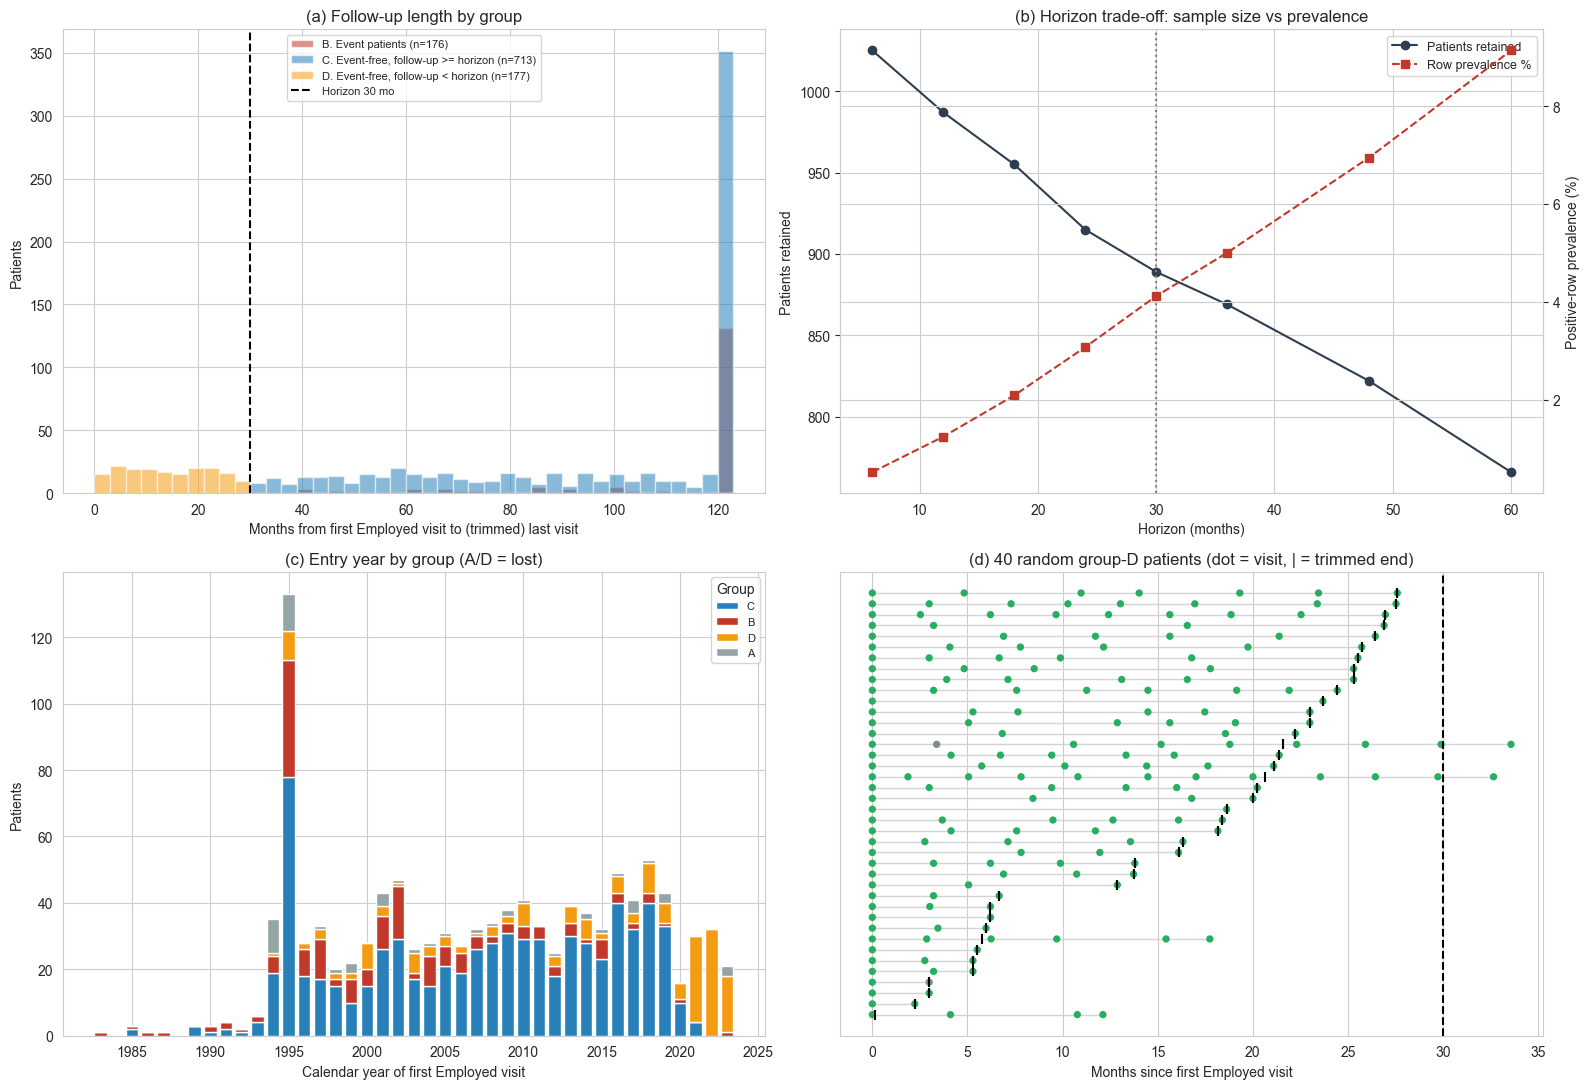

In [3]:
"""
Follow-up diagnostics for the landmark cohort.  Run AFTER the landmark-builder cell (uses its
_load_raw, _plan_patient, FEATURE_COLS, DISPLAY_NAMES, ADMIN_EXIT_STATES, *_TRIM_DAYS, HORIZON_DAYS).

Answers: how long is follow-up for the patients lost at step 4, WHY is it short (late entry vs dropout vs
death/exit), how does it look visit-by-visit, how does the cohort change with the horizon, and does
dropping/keeping patients by follow-up length bias the cohort?
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

GROUP_LABELS = {
    "A": "A. Only Employed visit is the last visit (lost, step 3)",
    "B": "B. Event patients (kept)",
    "C": "C. Event-free, follow-up >= horizon (kept)",
    "D": "D. Event-free, follow-up < horizon (LOST, step 4)",
}
MONTH = 365.25 / 12


def followup_diagnostics(path=RAW_PATH, horizon_days=HORIZON_DAYS, require_continuous_employment=True,
                         horizon_grid_months=(6, 12, 18, 24, 30, 36, 48, 60), ltfu_window_days=365,
                         n_swim=40, seed=240, plot=True):
    df, _ = _load_raw(path)
    data_cut = df["ASSDT"].max()
    frames = {pid: g.sort_values("ASSDT").reset_index(drop=True) for pid, g in df.groupby("PTNO")}
    H_m = horizon_days / MONTH

    # ------------------------------------------------------------------ one row per patient
    recs = []
    for pid, p in frames.items():
        emp = (p["cat"] == "Employed").values
        if not emp.any():
            continue
        plan = _plan_patient(p, horizon_days, require_continuous_employment)
        dates = p["ASSDT"]
        first = int(np.argmax(emp)); idx = dates.iloc[first]
        status, end_state = plan["status"], plan["end_state"]
        trim = DEATH_TRIM_DAYS if status == "D" else ADMIN_TRIM_DAYS if end_state in ADMIN_EXIT_STATES else 0
        last_visit = dates.max()
        db_after = ((p["cat"] == "Disability Benefit") & (dates > idx)).values
        trans = dates[db_after].min() if db_after.any() else pd.NaT
        has_event = bool(pd.notna(trans))
        post = dates[dates >= idx]
        gaps = post.diff().dt.days.dropna()

        if plan["exit"] == "no_forward_visit":
            grp = "A"
        elif plan["exit"] == "no_resolvable_label":
            grp = "D"
        else:
            grp = "B" if has_event else "C"

        reason = ""
        if grp == "D":
            if status == "D":
                reason = "Died (last 12 mo trimmed)"
            elif end_state in ADMIN_EXIT_STATES:
                reason = "Administrative exit (unemployed/retired/inactive)"
            elif (data_cut - last_visit).days <= ltfu_window_days:
                reason = "Still active at data cut (late entry / short observation)"
            else:
                reason = "Stopped attending > 1 yr before data cut (probable LTFU)"

        lcdt = p["LCDT"].max() if "LCDT" in p else pd.NaT
        rec = {"pid": pid, "group": grp, "reason": reason, "has_event": has_event,
               "index_date": idx, "index_year": idx.year, "last_visit": last_visit,
               "fu_raw_m": (last_visit - idx).days / MONTH,                     # index -> last visit
               "fu_trim_m": ((last_visit - pd.Timedelta(days=trim)) - idx).days / MONTH,  # what the builder uses
               "time_to_event_m": (trans - idx).days / MONTH if has_event else np.nan,
               "n_visits": len(post), "n_employed_run": plan["n_run"],
               "median_gap_d": gaps.median() if len(gaps) else np.nan,
               "max_gap_d": gaps.max() if len(gaps) else np.nan,
               "days_last_visit_to_cut": (data_cut - last_visit).days,
               "lcdt_minus_last_visit_d": (lcdt - last_visit).days if pd.notna(lcdt) else np.nan,
               "status": status, "end_state": end_state}
        rec.update({f"base_{c}": p[c].iloc[first] for c in FEATURE_COLS})
        rec["_dates"] = list(zip(post.values, p.loc[dates >= idx, "cat"].values))
        recs.append(rec)
    d = pd.DataFrame(recs)
    d["T_m"] = np.where(d["has_event"], d["time_to_event_m"], d["fu_trim_m"]).clip(min=0.1 / MONTH)
    n_all = len(d)
    W = 100

    # ------------------------------------------------------------------ 1. follow-up length by group
    print("=" * W)
    print(f"1. FOLLOW-UP LENGTH  (months from first Employed visit; horizon = {H_m:.1f} mo; data cut = {data_cut.date()})")
    print("-" * W)
    print(f"{'GROUP':<58}{'N':>5}{'MEDIAN':>8}{'IQR':>16}{'MIN':>7}{'MAX':>7}")
    for g, lab in GROUP_LABELS.items():
        x = d.loc[d.group == g, "fu_trim_m"]
        if len(x):
            print(f"{lab:<58}{len(x):>5}{x.median():>8.1f}{f'{x.quantile(.25):.1f} - {x.quantile(.75):.1f}':>16}"
                  f"{x.min():>7.1f}{x.max():>7.1f}")
    D = d[d.group == "D"]
    if len(D):
        print(f"\nGroup D follow-up in bands (how far short of the {H_m:.0f}-month horizon?):")
        edges = [-np.inf, 0, 6, 12, 18, H_m - 3, H_m]
        labels = ["<= 0 (trim erased it)", "0-6 mo", "6-12 mo", "12-18 mo", f"18-{H_m - 3:.0f} mo", f"{H_m - 3:.0f}-{H_m:.0f} mo (near miss)"]
        band = pd.cut(D["fu_trim_m"], bins=edges, labels=labels)
        t = band.value_counts().reindex(labels)
        for lab, n in t.items():
            print(f"  {lab:<28}{n:>5}  {n / len(D):>6.1%}  cumulative {t.loc[:lab].sum() / len(D):>6.1%}")
        print(f"  Shortfall to horizon: median {(H_m - D['fu_trim_m']).median():.1f} mo; "
              f"would be rescued by a shorter horizon of 18 mo: {int((D['fu_trim_m'] >= 18).sum())}, "
              f"12 mo: {int((D['fu_trim_m'] >= 12).sum())}")

        # ------------------------------------------------------------ 2. why is it short
        print("\n" + "=" * W)
        print("2. WHY IS FOLLOW-UP SHORT? (group D)")
        print("-" * W)
        r = D.groupby("reason").agg(N=("pid", "size"), median_fu_mo=("fu_trim_m", "median"),
                                    median_last_visit_to_cut_d=("days_last_visit_to_cut", "median"))
        r["%"] = r["N"] / len(D) * 100
        print(r.sort_values("N", ascending=False).to_string(float_format=lambda v: f"{v:.1f}"))
        lc = D["lcdt_minus_last_visit_d"].dropna()
        if len(lc):
            print(f"\nLCDT (last contact) minus last visit, group D: median {lc.median():.0f} d, "
                  f"{(lc > 180).mean():.1%} have contact > 6 mo after last visit "
                  f"(known status beyond the last visit that the builder ignores)")

    # ------------------------------------------------------------------ 3. visit pattern
    print("\n" + "=" * W)
    print("3. VISIT PATTERN (from first Employed visit)")
    print("-" * W)
    vp = d.groupby("group").agg(N=("pid", "size"), visits_med=("n_visits", "median"),
                                employed_run_med=("n_employed_run", "median"),
                                gap_med_d=("median_gap_d", "median"), max_gap_med_d=("max_gap_d", "median"),
                                last_visit_to_cut_med_d=("days_last_visit_to_cut", "median"))
    print(vp.to_string(float_format=lambda v: f"{v:.1f}"))

    print("\nBy calendar year of first Employed visit (are recent entrants the short ones?):")
    ct = pd.crosstab(d["index_year"], d["group"]).reindex(columns=list("ABCD"), fill_value=0)
    ct["% lost (A+D)"] = (ct["A"] + ct["D"]) / ct.sum(axis=1) * 100
    print(ct.to_string(float_format=lambda v: f"{v:.0f}"))

    # ------------------------------------------------------------------ 4. horizon sensitivity (exact, via the builder's own rules)
    print("\n" + "=" * W)
    print("4. HORIZON SENSITIVITY  (same eligibility rules re-run at each horizon)")
    print("-" * W)
    rows = []
    for m in horizon_grid_months:
        H = round(m * MONTH)
        pats = pos_pats = n_rows = pos_rows = 0
        for p in frames.values():
            pl = _plan_patient(p, H, require_continuous_employment)
            if pl["kept"]:
                pats += 1; n_rows += len(pl["kept"]); k = sum(l for _, l, _ in pl["kept"])
                pos_rows += k; pos_pats += k > 0
        rows.append({"Horizon (mo)": m, "Patients": pats, "% of index pts": 100 * pats / n_all,
                     "Landmark rows": n_rows, "Positive rows": pos_rows,
                     "Row prevalence %": 100 * pos_rows / max(n_rows, 1), "Patients w/ >=1 event": pos_pats})
    sens = pd.DataFrame(rows)
    print(sens.to_string(index=False, float_format=lambda v: f"{v:.1f}"))

    # ------------------------------------------------------------------ 5. selection-bias checks
    print("\n" + "=" * W)
    print("5. DOES KEEPING/DROPPING BY FOLLOW-UP BIAS THE COHORT?")
    print("-" * W)
    e = d[d.group != "A"]
    kept = e[e.group.isin(["B", "C"])]
    H_days_m = H_m
    within = lambda x: (x["has_event"] & (x["time_to_event_m"] <= H_days_m))
    print(f"Event within {H_m:.0f} mo of index visit:")
    print(f"  crude, ALL index patients (treats censored as event-free)   : {within(e).mean():.1%}  (n={len(e)})")
    print(f"  crude, KEPT patients only (B+C)                             : {within(kept).mean():.1%}  (n={len(kept)})")
    try:
        from lifelines import KaplanMeierFitter
        km = KaplanMeierFitter().fit(e["T_m"], e["has_event"])
        km_r = KaplanMeierFitter().fit(e["T_m"], ~e["has_event"])
        print(f"  Kaplan-Meier cumulative incidence (censoring-aware)         : {1 - km.predict(H_days_m):.1%}")
        print(f"Median potential follow-up (reverse Kaplan-Meier): {km_r.median_survival_time_:.1f} mo")
    except Exception as ex:
        print("  (lifelines unavailable for KM:", ex, ")")
    print("  -> if 'KEPT' is well above the KM figure, the rule 'events kept at any follow-up, event-free need the "
          "full horizon' is inflating prevalence.")

    if len(D):
        print(f"\nBaseline (index-visit) characteristics, kept (B+C) vs lost-at-step-4 (D) -- standardised mean difference:")
        out = []
        for c in FEATURE_COLS:
            a, b = kept[f"base_{c}"].astype(float), D[f"base_{c}"].astype(float)
            sd = np.sqrt((a.var() + b.var()) / 2)
            out.append({"Feature": DISPLAY_NAMES.get(c, c), "Kept mean": a.mean(), "Lost mean": b.mean(),
                        "SMD": (a.mean() - b.mean()) / sd if sd > 0 else np.nan})
        smd = pd.DataFrame(out).sort_values("SMD", key=np.abs, ascending=False)
        smd["Flag"] = np.where(smd["SMD"].abs() > 0.1, "<-- imbalance (>0.1)", "")
        print(smd.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
    print("=" * W)

    # ------------------------------------------------------------------ plots
    if plot:
        fig, ax = plt.subplots(2, 2, figsize=(16, 11))
        a = ax[0, 0]
        bins = np.arange(0, min(d["fu_trim_m"].max(), 120) + 6, 3)
        for g, col in [("B", "#c0392b"), ("C", "#2980b9"), ("D", "#f39c12")]:
            x = d.loc[d.group == g, "fu_trim_m"].clip(upper=bins[-1] - 0.01)
            a.hist(x, bins=bins, alpha=0.55, color=col, label=GROUP_LABELS[g].split(" (")[0] + f" (n={len(x)})")
        a.axvline(H_m, color="black", ls="--", label=f"Horizon {H_m:.0f} mo")
        a.set_xlabel("Months from first Employed visit to (trimmed) last visit"); a.set_ylabel("Patients")
        a.set_title("(a) Follow-up length by group"); a.legend(fontsize=8)

        a = ax[0, 1]
        a.plot(sens["Horizon (mo)"], sens["Patients"], "o-", color="#2c3e50", label="Patients retained")
        a.set_xlabel("Horizon (months)"); a.set_ylabel("Patients retained")
        a2 = a.twinx()
        a2.plot(sens["Horizon (mo)"], sens["Row prevalence %"], "s--", color="#c0392b", label="Row prevalence %")
        a2.set_ylabel("Positive-row prevalence (%)")
        a.axvline(H_m, color="gray", ls=":"); a.set_title("(b) Horizon trade-off: sample size vs prevalence")
        h1, l1 = a.get_legend_handles_labels(); h2, l2 = a2.get_legend_handles_labels()
        a.legend(h1 + h2, l1 + l2, loc="best", fontsize=9)

        a = ax[1, 0]
        yr = pd.crosstab(d["index_year"], d["group"]).reindex(columns=list("ABCD"), fill_value=0)
        bottom = np.zeros(len(yr))
        for g, col in [("C", "#2980b9"), ("B", "#c0392b"), ("D", "#f39c12"), ("A", "#95a5a6")]:
            a.bar(yr.index, yr[g], bottom=bottom, color=col, label=g); bottom += yr[g].values
        a.set_xlabel("Calendar year of first Employed visit"); a.set_ylabel("Patients")
        a.set_title("(c) Entry year by group (A/D = lost)"); a.legend(title="Group", fontsize=8)

        a = ax[1, 1]
        sw = D.sample(min(n_swim, len(D)), random_state=seed).sort_values("fu_trim_m") if len(D) else D
        colmap = {"Employed": "#27ae60", "Disability Benefit": "#c0392b"}
        for k, (_, r) in enumerate(sw.iterrows()):
            xs = [(np.datetime64(dt) - np.datetime64(r["index_date"])).astype("timedelta64[D]").astype(int) / MONTH
                  for dt, _ in r["_dates"]]
            a.plot([0, max(xs)], [k, k], color="lightgray", lw=1, zorder=1)
            a.scatter(xs, [k] * len(xs), c=[colmap.get(c, "#7f8c8d") for _, c in r["_dates"]], s=18, zorder=2)
            a.scatter([r["fu_trim_m"]], [k], marker="|", color="black", s=60, zorder=3)
        a.axvline(H_m, color="black", ls="--"); a.set_yticks([])
        a.set_xlabel("Months since first Employed visit"); a.set_title(f"(d) {len(sw)} random group-D patients (dot = visit, | = trimmed end)")
        plt.tight_layout(); plt.show(); plt.close()
    return d, sens

fu_df, horizon_table = followup_diagnostics()

In [4]:
"""
Table 1 — Baseline characteristics by outcome group.

Groups (mutually exclusive, patient-level):
  - Became Disabled   : patient had a Disability Benefit transition (event==1)
  - Deceased          : event-free, STATUS == 'D'
  - Other Exits       : event-free, end_state in ADMIN_EXIT_STATES
  - Remained Employed : event-free, none of the above
Plus an 'Overall' column across all patients in the modeling cohort (i.e.
patients who contributed at least one row to `land`).

Sections:
  1. Sociodemographics       -- sex, race, ethnicity, education, age, disease duration
  2. Follow-up               -- number of visits, total follow-up, mean gap between visits
  3. Disease activity/damage -- SLEDAI-2K, SDI, at baseline and across follow-up
  4. Treatment                -- ever-treated flags + average dose while treated,
                                  computed across each patient's FULL visit history
                                  (not a single row, so no more "one row per dose").

Continuous -> mean (SD) | median [IQR], compared with Kruskal-Wallis.
Categorical -> n (%), compared with chi-square.
"""
import numpy as np
import pandas as pd
from scipy import stats


def _patient_outcome_group(land_sub):
    r = land_sub.iloc[0]
    if r["event"] == 1:
        return "Became Disabled"
    if r["status"] == "D":
        return "Deceased"
    if r["end_state"] in ADMIN_EXIT_STATES:
        return "Other Exits"
    return "Remained Employed"


def _first_nonnull(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else np.nan


def build_table1_baseline(land, raw_path=RAW_PATH):
    """One row per patient (restricted to the modeling cohort in `land`):
    demographics, follow-up structure, disease activity/damage, and
    treatment history, all aggregated across that patient's FULL visit
    record -- not read off a single row."""
    df_raw, _ = _load_raw(raw_path)
    df_raw = df_raw.sort_values(["PTNO", "ASSDT"])

    outcome = (land.groupby("pid", group_keys=False)
                    .apply(_patient_outcome_group)
                    .rename("outcome_group"))
    cohort_ids = outcome.index

    df_c = df_raw[df_raw["PTNO"].isin(cohort_ids)]
    idx_rows = df_c.groupby("PTNO", as_index=False).first().set_index("PTNO")
    last_rows = df_c.groupby("PTNO", as_index=False).last().set_index("PTNO")
    g = df_c.groupby("PTNO")

    agg = pd.DataFrame(index=cohort_ids)

    # ---- 1. Sociodemographics (patient-constant; may not be on row 1, so
    #         take the first non-null value across ALL of that patient's visits) ----
    agg["sex"] = g["SEX"].apply(_first_nonnull)
    agg["race"] = g["RACE_LABEL"].apply(_first_nonnull)
    agg["ethnicity"] = g["DS_ETHNICITY"].apply(_first_nonnull)
    agg["education"] = g["DS_MAX_EDU"].apply(_first_nonnull)
    agg["age_index"] = idx_rows["age_at_record"]
    agg["disease_duration_yrs"] = idx_rows["disease_duration_yrs"]

    # ---- 2. Follow-up structure (across the FULL raw visit history) ----
    agg["n_visits"] = g.size()
    agg["followup_years"] = (last_rows["ASSDT"] - idx_rows["ASSDT"]).dt.days / 365.25
    agg["mean_gap_days"] = g["DAYS_SINCE_LAST_VISIT"].mean()

    # ---- 3. Disease activity & damage ----
    agg["sledai_baseline"] = idx_rows["SLEDAI2_I"]
    agg["sledai_mean"] = g["SLEDAI2_I"].mean()
    agg["sdi_baseline"] = idx_rows["score_n"]
    agg["sdi_last"] = last_rows["score_n"]

    # ---- 4. Treatment (ever-treated flags + average dose while treated,
    #         computed across the full record, not a single row) ----
    agg["ever_steroid"] = g["HAS_STEROID_REC"].max()
    agg["steroid_dose_mean"] = g["STERAVER"].mean()
    agg["ever_steroid_pulse"] = g["STPDOSE"].apply(lambda s: int((s.fillna(0) > 0).any()))
    agg["ever_antimalarial"] = g["HAS_ANTIMALARIAL_REC"].max()
    agg["ever_immunosuppressive"] = g["HAS_IMMUNOSUPPRESSIVE_REC"].max()
    agg["ever_cyclophosphamide"] = g["IS_CYCLOPHOSPHAMIDE_DOSE"].apply(lambda s: int((s.fillna(0) > 0).any()))
    agg["ever_mycophenolate"] = g["IS_MYCOPHENOLATE_DOSE"].apply(lambda s: int((s.fillna(0) > 0).any()))
    agg["ever_methotrexate"] = g["IS_METHOTREXATE_DOSE"].apply(lambda s: int((s.fillna(0) > 0).any()))
    agg["ever_biologic"] = g["HAS_BIOLOGIC_REC"].max()
    agg["ever_rituximab"] = g["BIOG_RIT"].apply(lambda s: int(s.fillna(0).max() > 0))
    agg["ever_belimumab"] = g["BIOG_BEL"].apply(lambda s: int(s.fillna(0).max() > 0))

    agg = agg.join(outcome, how="inner")
    return agg


def _fmt_continuous(s):
    s = s.dropna().astype(float)
    if len(s) == 0:
        return "n=0"
    return f"{s.mean():.1f} ({s.std():.1f})  |  {s.median():.1f} [{s.quantile(.25):.1f}\u2013{s.quantile(.75):.1f}]"


def _fmt_categorical(s, level):
    s = s.dropna()
    n = (s == level).sum()
    denom = len(s)
    pct = 100 * n / denom if denom else 0.0
    return f"{n} ({pct:.1f}%)"


def _section_row(groups, title):
    return {"Variable": f"**{title}**", "Overall": "", **{g: "" for g in groups}, "p": ""}


def _continuous_row(base, col, label, groups):
    arrs = [base.loc[base["outcome_group"] == g, col].dropna().astype(float) for g in groups]
    arrs = [a for a in arrs if len(a) > 0]
    try:
        _, p = stats.kruskal(*arrs) if len(arrs) > 1 else (np.nan, np.nan)
        p_str = f"{p:.3f}" if pd.notna(p) else "n/a"
    except ValueError:
        p_str = "n/a"
    row = {"Variable": f"{label}, mean (SD) | median [IQR]", "Overall": _fmt_continuous(base[col]), "p": p_str}
    for g in groups:
        row[g] = _fmt_continuous(base.loc[base["outcome_group"] == g, col])
    return row


def _categorical_rows(base, col, label, groups, level_labels=None):
    rows = [{"Variable": f"**{label}**, n (%)", "Overall": "", **{g: "" for g in groups}, "p": ""}]
    ct = pd.crosstab(base[col], base["outcome_group"])
    try:
        _, p, _, _ = stats.chi2_contingency(ct)
        p_str = f"{p:.3f}"
    except ValueError:
        p_str = "n/a"
    levels = sorted(base[col].dropna().unique().tolist(), key=str)
    for i, lvl in enumerate(levels):
        lvl_label = (level_labels or {}).get(lvl, lvl)
        row = {"Variable": f"    {lvl_label}", "Overall": _fmt_categorical(base[col], lvl), "p": p_str if i == 0 else ""}
        for g in groups:
            row[g] = _fmt_categorical(base.loc[base["outcome_group"] == g, col], lvl)
        rows.append(row)
    return rows


def _binary_row(base, col, label, groups):
    """For 0/1 'ever-treated' flags: a single n (%) row for the '1' level."""
    ct = pd.crosstab(base[col], base["outcome_group"])
    try:
        _, p, _, _ = stats.chi2_contingency(ct)
        p_str = f"{p:.3f}"
    except ValueError:
        p_str = "n/a"
    row = {"Variable": f"{label}, n (%)", "Overall": _fmt_categorical(base[col], 1), "p": p_str}
    for g in groups:
        row[g] = _fmt_categorical(base.loc[base["outcome_group"] == g, col], 1)
    return row


def make_table1(base, group_order=("Remained Employed", "Became Disabled", "Deceased", "Other Exits")):
    groups = [g for g in group_order if g in base["outcome_group"].unique()]
    rows = []

    # ---- Sociodemographics ----
    rows.append(_section_row(groups, "Sociodemographics"))
    rows.append(_continuous_row(base, "age_index", "Age at baseline (years)", groups))
    rows += _categorical_rows(base, "sex", "Sex", groups)
    rows += _categorical_rows(base, "race", "Race", groups)
    rows += _categorical_rows(base, "ethnicity", "Ethnicity", groups)
    rows += _categorical_rows(base, "education", "Education (DS_MAX_EDU)", groups,
                               level_labels={0: "Lower", 1: "Higher"})  # relabel once you confirm coding
    rows.append(_continuous_row(base, "disease_duration_yrs", "Disease duration at baseline (years)", groups))

    # ---- Follow-up ----
    rows.append(_section_row(groups, "Follow-up"))
    rows.append(_continuous_row(base, "n_visits", "Number of visits", groups))
    rows.append(_continuous_row(base, "followup_years", "Total follow-up (years)", groups))
    rows.append(_continuous_row(base, "mean_gap_days", "Mean time between visits (days)", groups))

    # ---- Disease activity & damage ----
    rows.append(_section_row(groups, "Disease Activity & Damage"))
    rows.append(_continuous_row(base, "sledai_baseline", "SLEDAI-2K at baseline", groups))
    rows.append(_continuous_row(base, "sledai_mean", "SLEDAI-2K, mean across follow-up", groups))
    rows.append(_continuous_row(base, "sdi_baseline", "SDI damage score at baseline", groups))
    rows.append(_continuous_row(base, "sdi_last", "SDI damage score at last visit", groups))

    # ---- Treatment ----
    rows.append(_section_row(groups, "Treatment (ever during follow-up)"))
    rows.append(_binary_row(base, "ever_steroid", "Ever on steroids", groups))
    rows.append(_continuous_row(base, "steroid_dose_mean", "Average daily steroid dose, mg (among those with a value)", groups))
    rows.append(_binary_row(base, "ever_steroid_pulse", "Ever received steroid pulse", groups))
    rows.append(_binary_row(base, "ever_antimalarial", "Ever on antimalarial", groups))
    rows.append(_binary_row(base, "ever_immunosuppressive", "Ever on immunosuppressive therapy", groups))
    rows.append(_binary_row(base, "ever_cyclophosphamide", "    Ever cyclophosphamide", groups))
    rows.append(_binary_row(base, "ever_mycophenolate", "    Ever mycophenolate", groups))
    rows.append(_binary_row(base, "ever_methotrexate", "    Ever methotrexate", groups))
    rows.append(_binary_row(base, "ever_biologic", "Ever on biologic therapy", groups))
    rows.append(_binary_row(base, "ever_rituximab", "    Ever rituximab", groups))
    rows.append(_binary_row(base, "ever_belimumab", "    Ever belimumab", groups))

    n_row = {"Variable": "N", "Overall": str(len(base)), "p": ""}
    for g in groups:
        n_row[g] = str((base["outcome_group"] == g).sum())
    rows = [n_row] + rows

    return pd.DataFrame(rows)[["Variable", "Overall"] + groups + ["p"]]


table1_base = build_table1_baseline(land)
table1 = make_table1(table1_base)

pd.set_option("display.max_rows", None)
display(table1)
table1.to_csv("table1_baseline_characteristics.csv", index=False)

/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_1245/2132404623.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_patient_outcome_group)


,Variable,Overall,Remained Employed,Became Disabled,Deceased,p
0,N,889,678,176,35,
1,**Sociodemographics**,,,,,
2,"Age at baseline (years), mean (SD) | median [IQR]",35.3 (11.4) | 33.9 [26.0–43.4],34.3 (11.1) | 33.0 [25.8–41.7],37.7 (11.9) | 37.8 [27.0–46.5],42.6 (11.2) | 42.4 [34.8–49.5],0.000
3,"**Sex**, n (%)",,,,,
4,F,796 (89.5%),607 (89.5%),160 (90.9%),29 (82.9%),0.364
5,M,93 (10.5%),71 (10.5%),16 (9.1%),6 (17.1%),
6,"**Race**, n (%)",,,,,
7,Black,127 (14.5%),86 (13.0%),35 (19.9%),6 (17.1%),0.226
8,Caucasian,538 (61.5%),401 (60.4%),115 (65.3%),22 (62.9%),
9,Chinese,91 (10.4%),76 (11.4%),12 (6.8%),3 (8.6%),


## Model 1/5 — Logistic Regression (DAE-imputed features)

Training Denoising Autoencoder for imputation...
[LogReg] Landmark sample prevalence: 4.1%  |  Calibration-fold prevalence: 4.1%  |  Target prevalence used: 4.1%

LogReg (DAE-imputed) -- 30-MONTH WORK-DISABILITY RISK: COMPREHENSIVE METRICS
------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO            
------------------------------------------------------------------------------
Concordance Index              | 0.6147     | Discrimination
Brier Score                    | 0.0743     | Overall accuracy (lower=better)
Calibration Slope              | 0.2416     | Ideal = 1.0
Calibration Intercept          | -0.0117     | Ideal = 0.0
Sensitivity                    | 0.1934     | [0.163, 0.229]
Specificity                    | 0.9427     | [0.939, 0.947]
PPV                            | 0.1266     | [0.106, 0.151]
NPV                            | 0.9646     | [0.961, 0.968]
Balanced Accuracy             

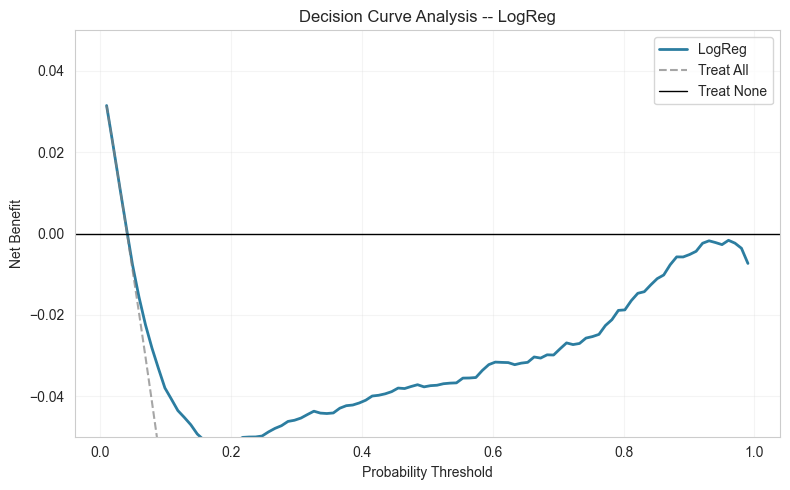

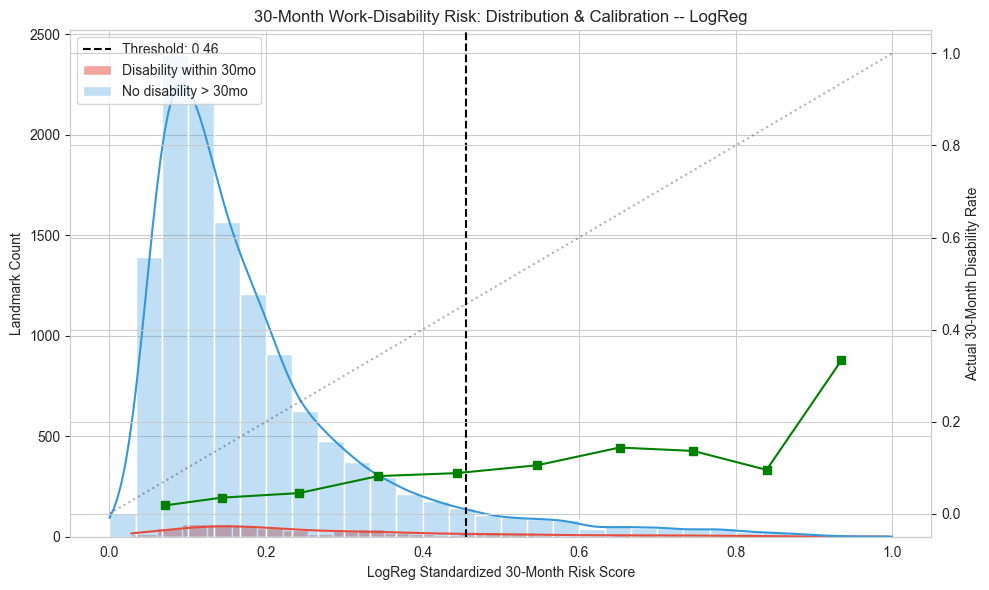

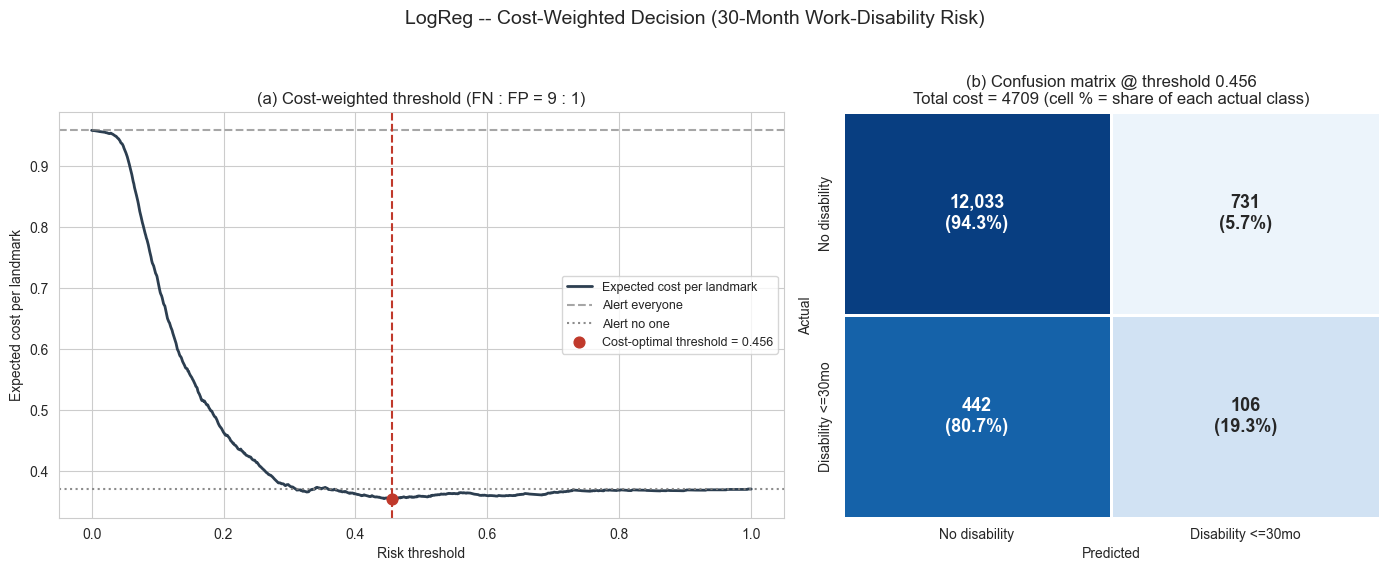

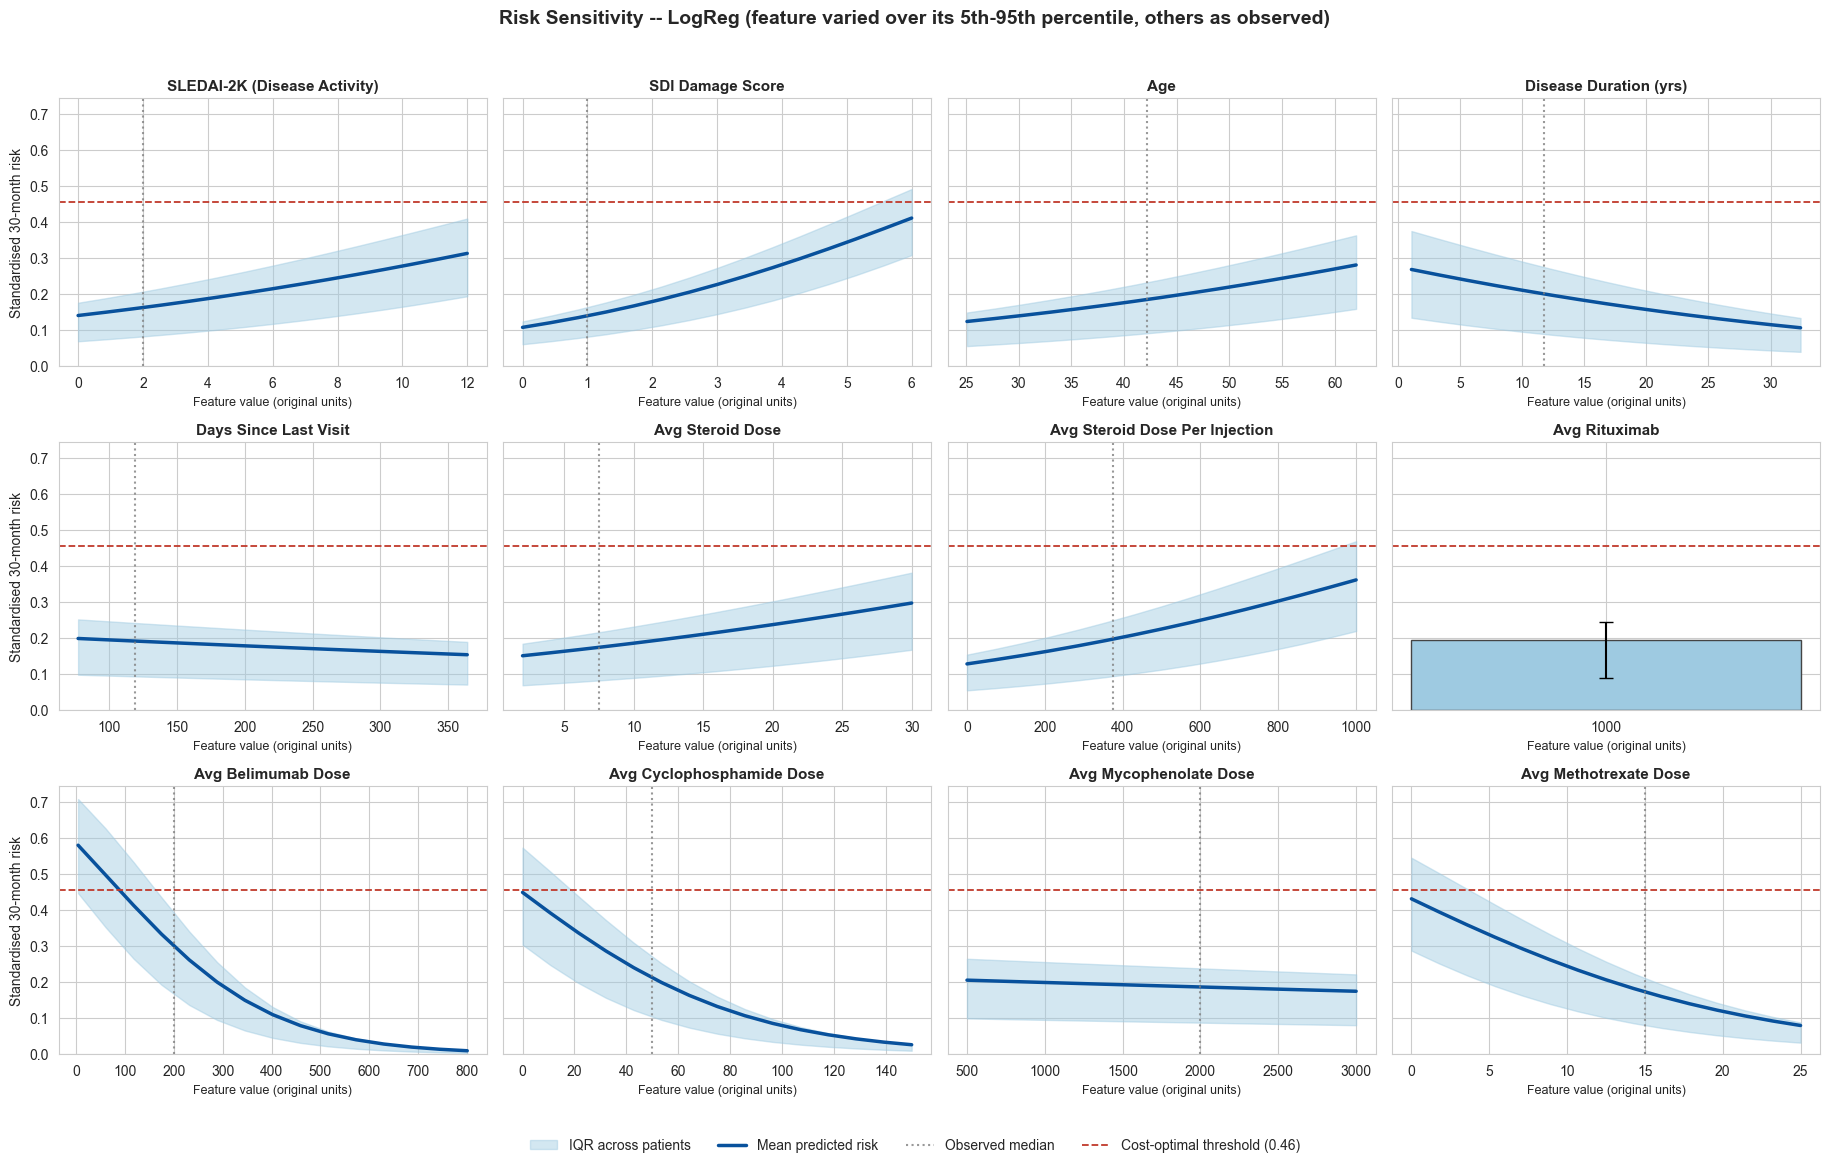


Risk-sensitivity summary -- LogReg (mean standardised risk; ranked by swing)
                       Feature  Risk @ low value  Risk @ high value  Risk swing (max-min)
            Avg Belimumab Dose             0.581              0.010                 0.571
     Avg Cyclophosphamide Dose             0.450              0.026                 0.423
         Avg Methotrexate Dose             0.432              0.080                 0.352
              SDI Damage Score             0.108              0.412                 0.303
Avg Steroid Dose Per Injection             0.129              0.362                 0.233
  SLEDAI-2K (Disease Activity)             0.141              0.313                 0.172
        Disease Duration (yrs)             0.269              0.107                 0.162
                           Age             0.124              0.281                 0.157
              Avg Steroid Dose             0.151              0.298                 0.146
         Days Since La

In [5]:
"""Landmark Logistic Regression, 30-month work-disability risk (SLE),
DAE-imputed features. Adapted from the notebook's LandmarkSurvivalLogReg."""
import numpy as np
import pandas as pd
import random
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from lifelines.utils import concordance_index


random.seed(240); np.random.seed(240); torch.manual_seed(240)


class LandmarkSurvivalLogReg:
    def __init__(self, horizon_days=913):
        self.horizon_days = horizon_days
        self.feature_cols = FEATURE_COLS
        self.scaler = StandardScaler()
        self.model = LogisticRegression(class_weight="balanced", random_state=240, max_iter=1000)
        self.dae = None
        self.final_scaler = MinMaxScaler(feature_range=(0, 1))
        self.calibrator = None
    def prepare_data(self, land):
        raw = land[self.feature_cols].values.astype(float)
        print("Training Denoising Autoencoder for imputation...")
        self.dae = train_dae(raw, epochs=50)
        imputed = impute_with_dae(self.dae, raw)
        self.imputed = imputed  # unscaled, imputed features (used by risk-sensitivity analysis)
        scaled = self.scaler.fit_transform(imputed)
        X = scaled
        y = land["label"].values
        w = land["weight"].values
        return X, y, w

    def _predict_risk_override(self, rows, j, v):
        Xm = self.imputed[rows].copy()
        Xm[:, j] = v
        p = self.model.predict_proba(self.scaler.transform(Xm))[:, 1]
        calibrated = apply_risk_calibrator(self.calibrator, p)
        return np.clip(self.final_scaler.transform(calibrated.reshape(-1, 1)).flatten(), 1e-5, 1 - 1e-5)    
    def run_analysis(self, land):
        X, y, w = self.prepare_data(land)
        self.model.fit(X, y, sample_weight=w)

        risks_raw = self.model.predict_proba(X)[:, 1]
        self.calibrator = fit_risk_calibrator(risks_raw, y, seed=240, model_name="LogReg")   # or "RSF" / "CoxPH" / "GRU" / "LSTM"
        calibrated = apply_risk_calibrator(self.calibrator, risks_raw)
        risks = self.final_scaler.fit_transform(calibrated.reshape(-1, 1)).flatten()
        risks = np.clip(risks, 1e-5, 1 - 1e-5)        

        best_t = find_cost_optimal_threshold(y, risks)
        y_pred = (risks >= best_t).astype(int)

        c_idx = concordance_index(land["duration"], -risks, land["event"])

        report_comprehensive_metrics("LogReg (DAE-imputed)", y, y_pred, risks, c_idx)
        meta = land.copy()
        meta["y_pred"] = y_pred
        print_operational_metrics("LogReg", meta, label_col="label")
        print_cost_metrics("LogReg", y, y_pred, best_t)
        plot_decision_curve("LogReg", y, risks, color="#2c7da0")
        plot_risk_distribution_and_calibration("LogReg", risks, y, best_t)
        plot_cost_decision_and_confusion("LogReg", y, risks, best_t)

        sens_curves = compute_risk_sensitivity(self.feature_cols, land, self._predict_risk_override)
        plot_risk_sensitivity("LogReg", sens_curves, best_t)

        return {"model": self, "risks": risks, "y": y, "y_pred": y_pred, "c_index": c_idx,
                "best_t": best_t, "sensitivity": sens_curves}

logreg_pipeline = LandmarkSurvivalLogReg(horizon_days=HORIZON_DAYS)
res_logreg = logreg_pipeline.run_analysis(land)

## Model 2/5 — Random Survival Forest (DAE-imputed features)

Training Denoising Autoencoder for feature imputation...
[RSF] Landmark sample prevalence: 4.1%  |  Calibration-fold prevalence: 4.1%  |  Target prevalence used: 4.1%

RSF (DAE-imputed) -- 30-MONTH WORK-DISABILITY RISK: COMPREHENSIVE METRICS
------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO            
------------------------------------------------------------------------------
Concordance Index              | 0.8416     | Discrimination
Brier Score                    | 0.0338     | Overall accuracy (lower=better)
Calibration Slope              | 0.6340     | Ideal = 1.0
Calibration Intercept          | 0.0754     | Ideal = 0.0
Sensitivity                    | 0.6606     | [0.620, 0.699]
Specificity                    | 0.9002     | [0.895, 0.905]
PPV                            | 0.2213     | [0.202, 0.242]
NPV                            | 0.9841     | [0.982, 0.986]
Balanced Accuracy            

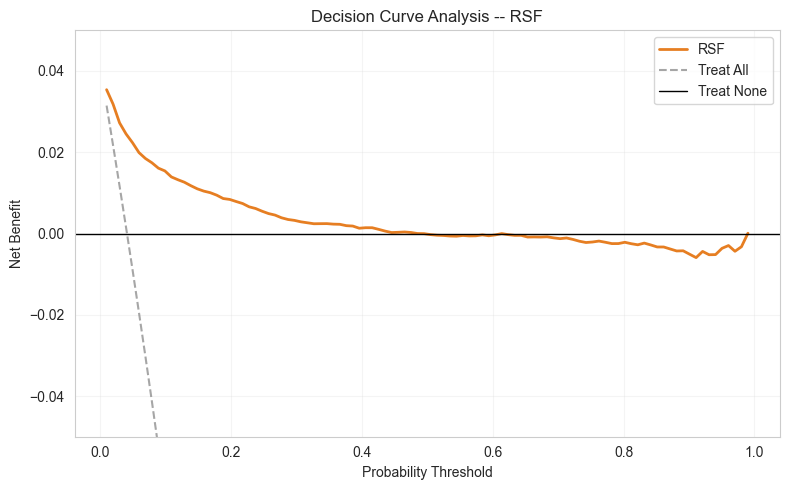

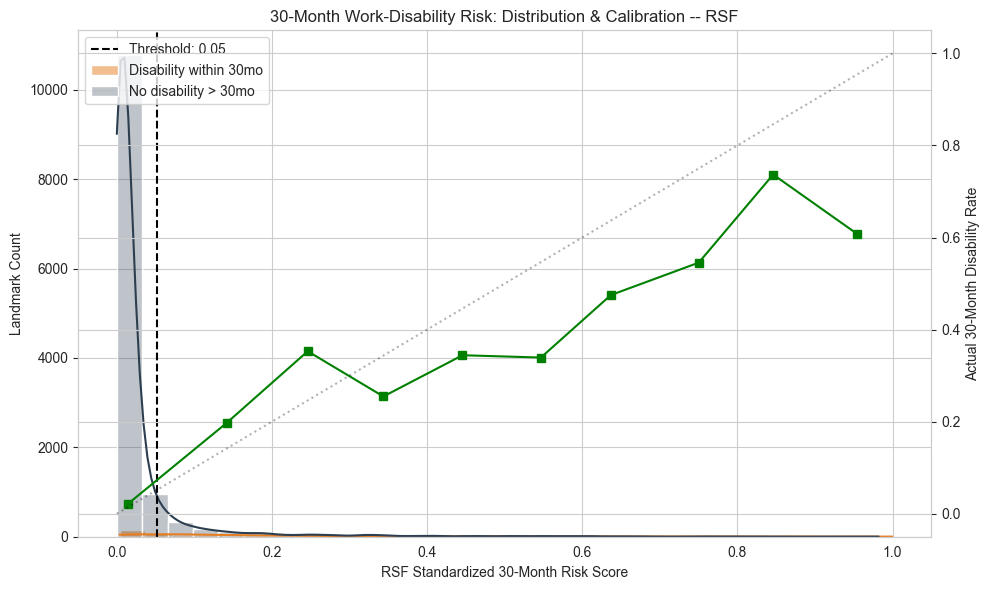

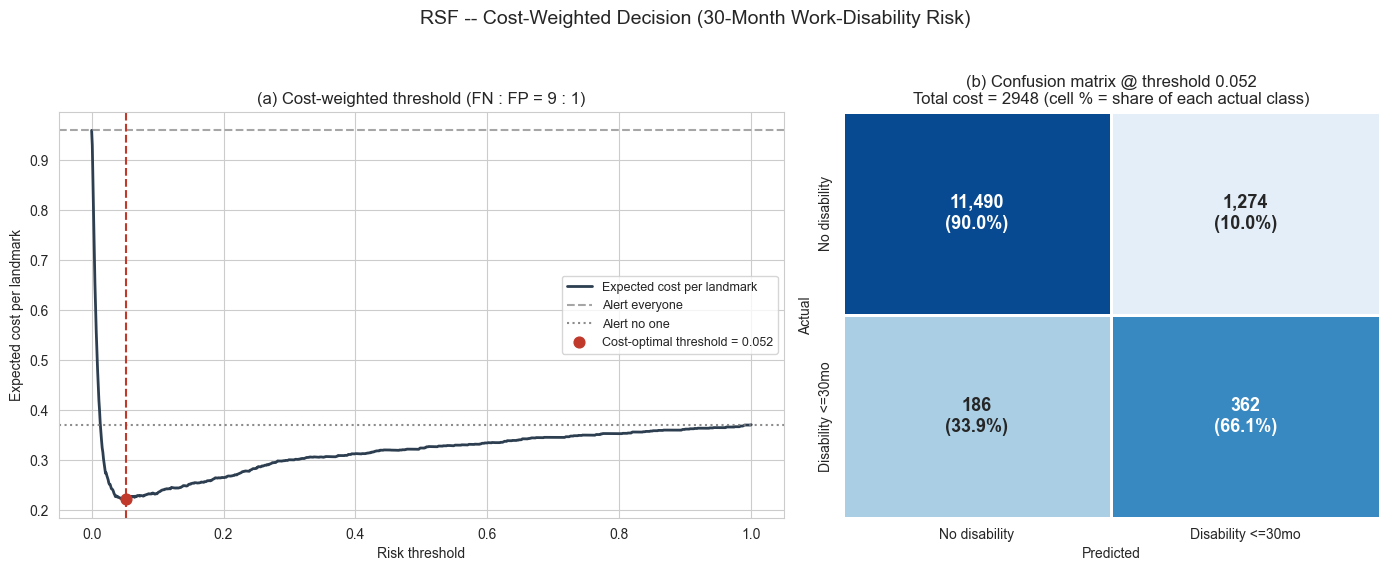

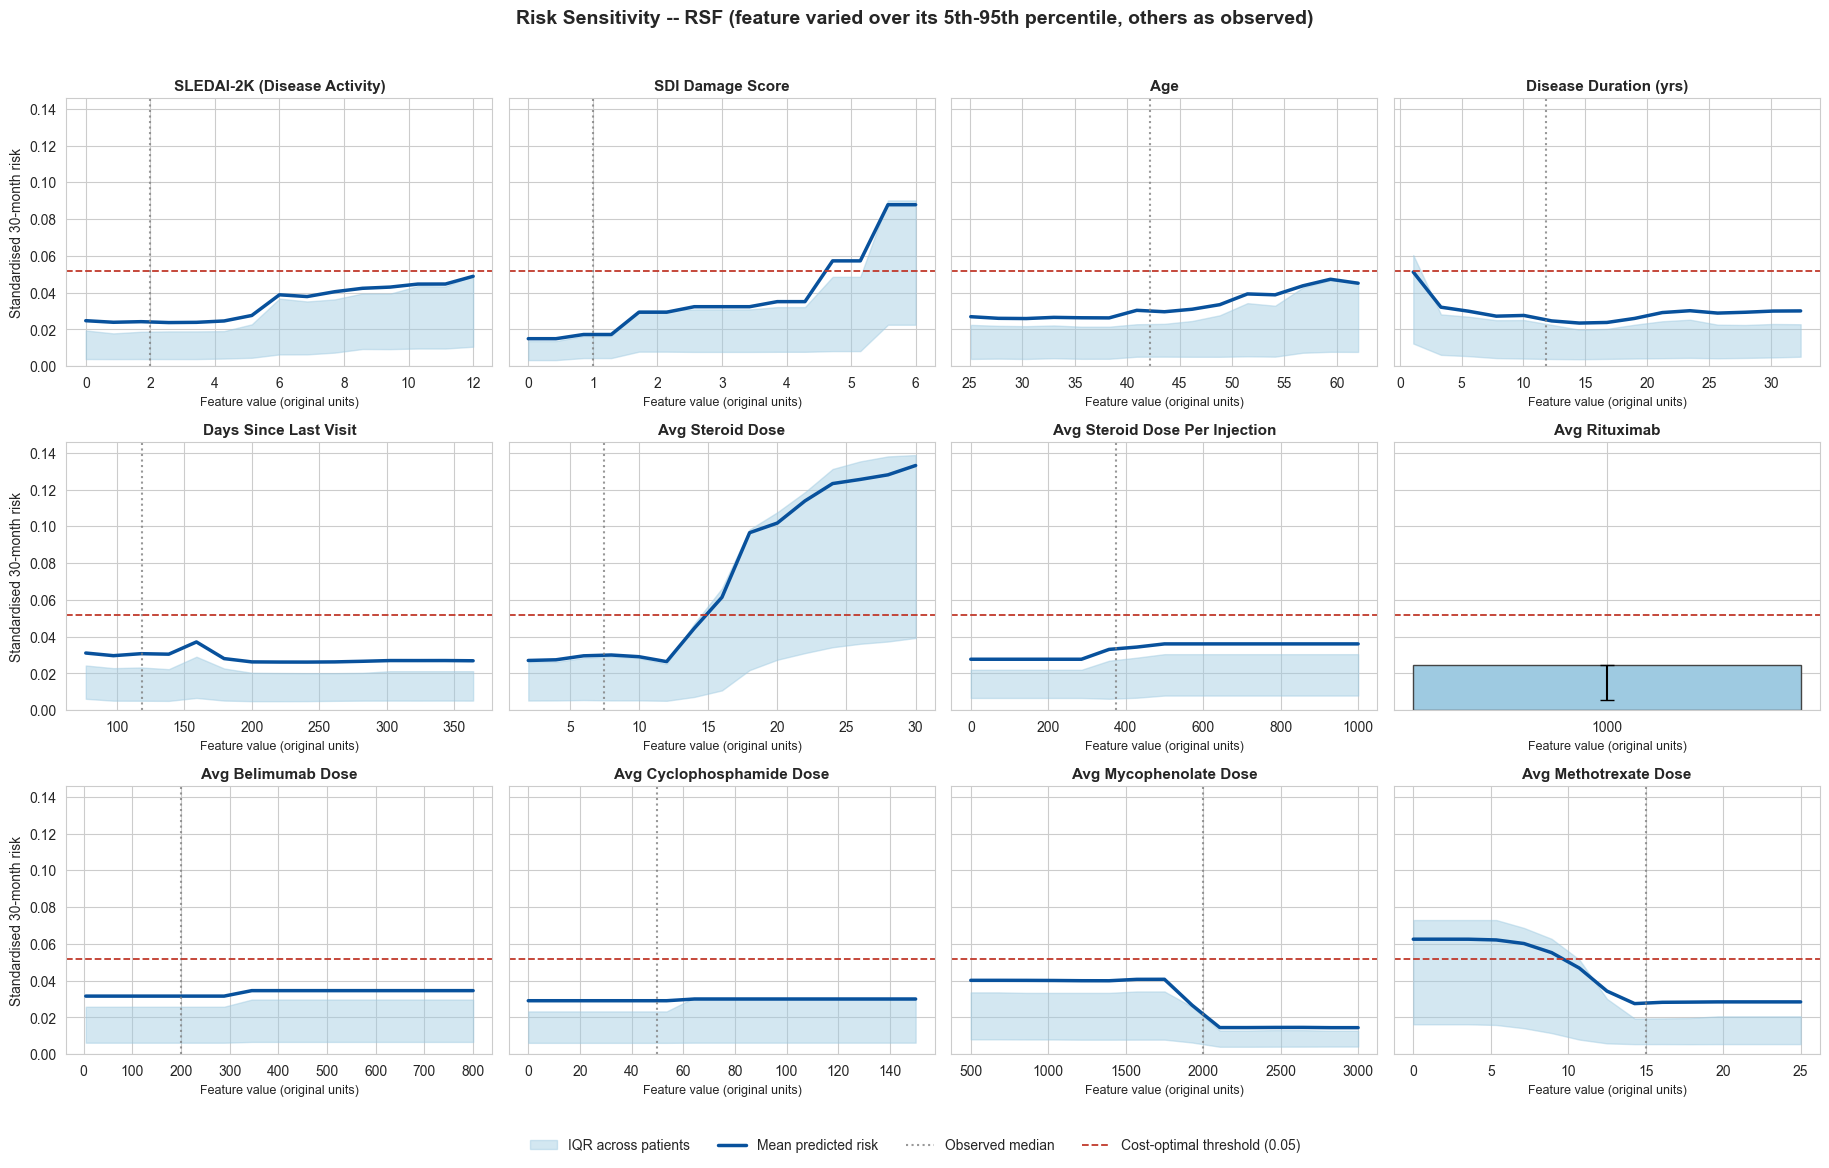


Risk-sensitivity summary -- RSF (mean standardised risk; ranked by swing)
                       Feature  Risk @ low value  Risk @ high value  Risk swing (max-min)
              Avg Steroid Dose             0.027              0.133                 0.107
              SDI Damage Score             0.015              0.088                 0.073
         Avg Methotrexate Dose             0.063              0.028                 0.035
        Disease Duration (yrs)             0.051              0.030                 0.028
        Avg Mycophenolate Dose             0.040              0.014                 0.026
  SLEDAI-2K (Disease Activity)             0.025              0.049                 0.025
                           Age             0.027              0.045                 0.021
         Days Since Last Visit             0.031              0.027                 0.011
Avg Steroid Dose Per Injection             0.028              0.036                 0.008
            Avg Belimumab

In [6]:
"""Landmark Random Survival Forest, 30-month work-disability risk (SLE),
DAE-imputed features. Adapted from the notebook's LandmarkSurvivalRSF."""
import numpy as np
import pandas as pd
import random
import torch
from sklearn.preprocessing import StandardScaler
from sksurv.ensemble import RandomSurvivalForest
from lifelines.utils import concordance_index


random.seed(240); np.random.seed(240); torch.manual_seed(240)


class LandmarkSurvivalRSF:
    def __init__(self, horizon_days=913):
        self.horizon_days = horizon_days
        self.feature_cols = FEATURE_COLS
        self.scaler = StandardScaler()
        self.model = RandomSurvivalForest(
            n_estimators=50, min_samples_split=10, min_samples_leaf=15,
            max_features="sqrt", n_jobs=-1, random_state=240,
        )
        self.dae = None
        self.final_scaler = MinMaxScaler(feature_range=(0, 1))
        self.calibrator = None
    def prepare_data(self, land):
        raw = land[self.feature_cols].values.astype(float)
        print("Training Denoising Autoencoder for feature imputation...")
        self.dae = train_dae(raw, epochs=60)
        imputed = impute_with_dae(self.dae, raw)
        self.imputed = imputed  # unscaled, imputed features (used by risk-sensitivity analysis)
        scaled = self.scaler.fit_transform(imputed)

        y_struct = np.array(
            list(zip(land["event"].astype(bool), land["duration"].astype(float))),
            dtype=[("event", "bool"), ("time", "float")],
        )
        return scaled, land["label"].values, y_struct, land["weight"].values

    def _predict_risk_override(self, rows, j, v):
        """Calibrated risk for landmark `rows` with feature j forced to v (original units)."""
        Xm = self.imputed[rows].copy()
        Xm[:, j] = v
        p = self.model.predict(self.scaler.transform(Xm))
        calibrated = apply_risk_calibrator(self.calibrator, p)   # or `raw` in the GRU/LSTM cell
        return np.clip(self.final_scaler.transform(calibrated.reshape(-1, 1)).flatten(), 1e-5, 1 - 1e-5)
        #return apply_risk_calibrator(self.calibrator, p)

    def run_analysis(self, land):
        X, y, y_surv, w = self.prepare_data(land)
        try:
            self.model.fit(X, y_surv, sample_weight=w)
        except TypeError:
            self.model.fit(X, y_surv)

        risks_raw = self.model.predict(X)
        self.calibrator = fit_risk_calibrator(risks_raw, y, seed=240, model_name="RSF")   # or "RSF" / "CoxPH" / "GRU" / "LSTM"
        calibrated = apply_risk_calibrator(self.calibrator, risks_raw)
        risks = self.final_scaler.fit_transform(calibrated.reshape(-1, 1)).flatten()
        risks = np.clip(risks, 1e-5, 1 - 1e-5)        

        best_t = find_cost_optimal_threshold(y, risks)
        y_pred = (risks >= best_t).astype(int)

        c_idx = concordance_index(land["duration"], -risks, land["event"])

        report_comprehensive_metrics("RSF (DAE-imputed)", y, y_pred, risks, c_idx)
        meta = land.copy()
        meta["y_pred"] = y_pred
        print_operational_metrics("RSF", meta, label_col="label")
        print_cost_metrics("RSF", y, y_pred, best_t)
        plot_decision_curve("RSF", y, risks, color="#e67e22")
        plot_risk_distribution_and_calibration("RSF", risks, y, best_t,
                                                color_pos="#e67e22", color_neg="#2c3e50")
        plot_cost_decision_and_confusion("RSF", y, risks, best_t)

        sens_curves = compute_risk_sensitivity(self.feature_cols, land, self._predict_risk_override)
        plot_risk_sensitivity("RSF", sens_curves, best_t)

        return {"model": self, "risks": risks, "y": y, "y_pred": y_pred, "c_index": c_idx,
                "best_t": best_t, "sensitivity": sens_curves}

rsf_pipeline = LandmarkSurvivalRSF(horizon_days=HORIZON_DAYS)
res_rsf = rsf_pipeline.run_analysis(land)

## Model 3/5 — Cox Proportional Hazards (DAE-imputed, balanced fit)

Training Denoising Autoencoder for feature imputation...
[CoxPH] Landmark sample prevalence: 4.1%  |  Calibration-fold prevalence: 4.1%  |  Target prevalence used: 4.1%

CoxPH (DAE-imputed, balanced fit) -- 30-MONTH WORK-DISABILITY RISK: COMPREHENSIVE METRICS
------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO            
------------------------------------------------------------------------------
Concordance Index              | 0.6059     | Discrimination
Brier Score                    | 0.1001     | Overall accuracy (lower=better)
Calibration Slope              | 0.3317     | Ideal = 1.0
Calibration Intercept          | -0.0502     | Ideal = 0.0
Sensitivity                    | 0.1405     | [0.114, 0.172]
Specificity                    | 0.9656     | [0.962, 0.969]
PPV                            | 0.1492     | [0.121, 0.183]
NPV                            | 0.9632     | [0.960, 0.966]
Balanced A

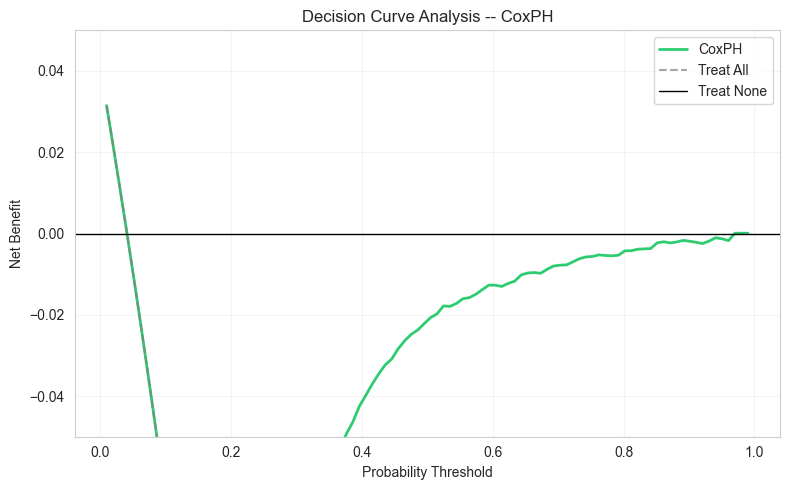

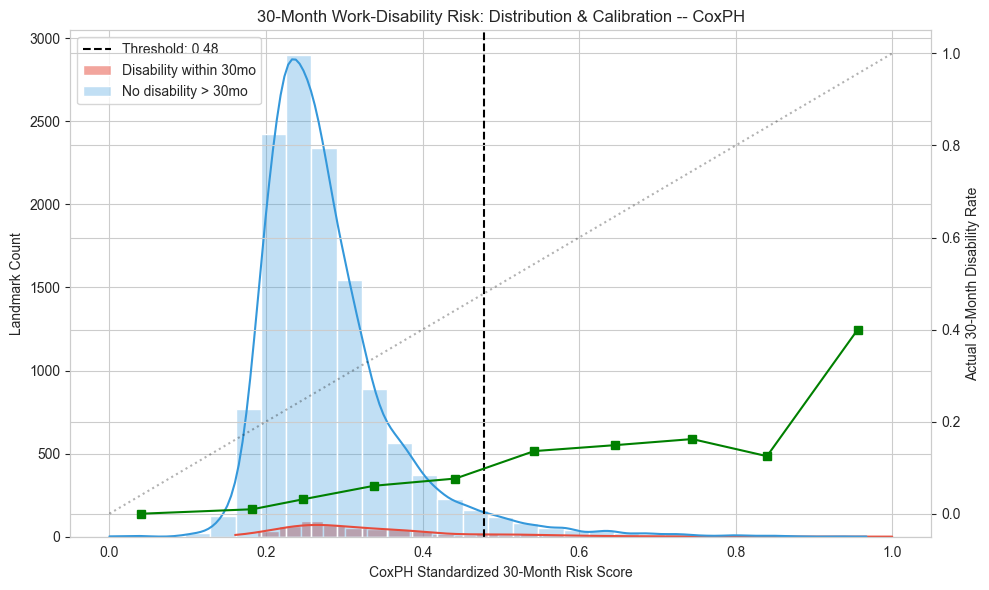

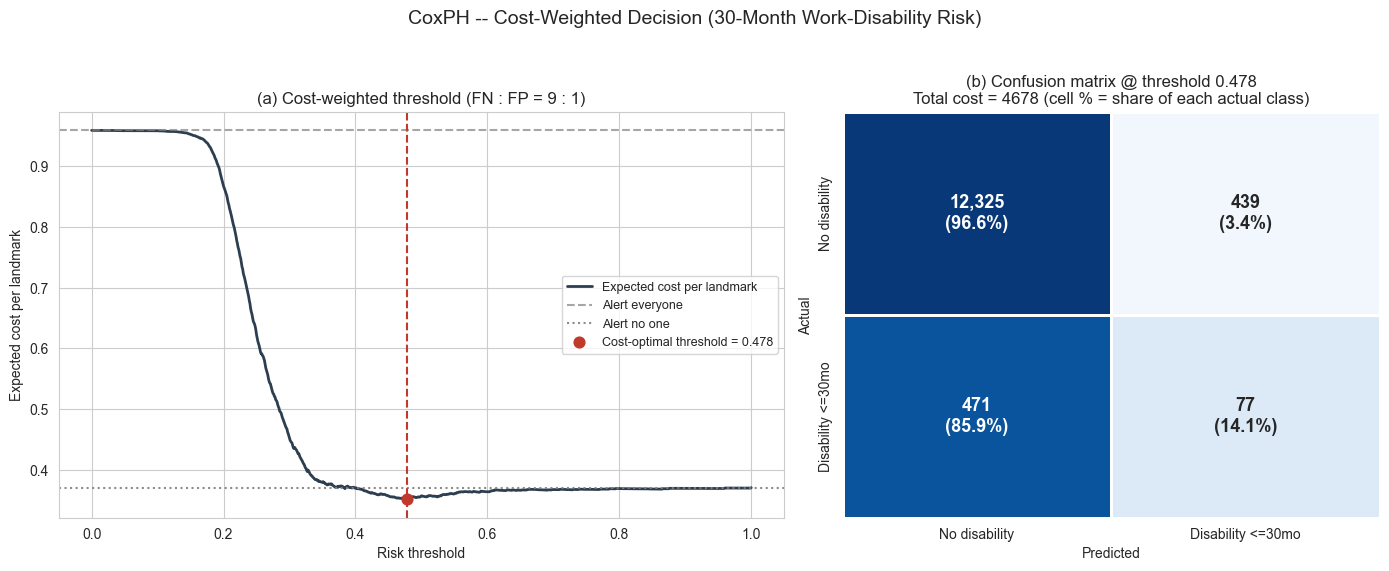

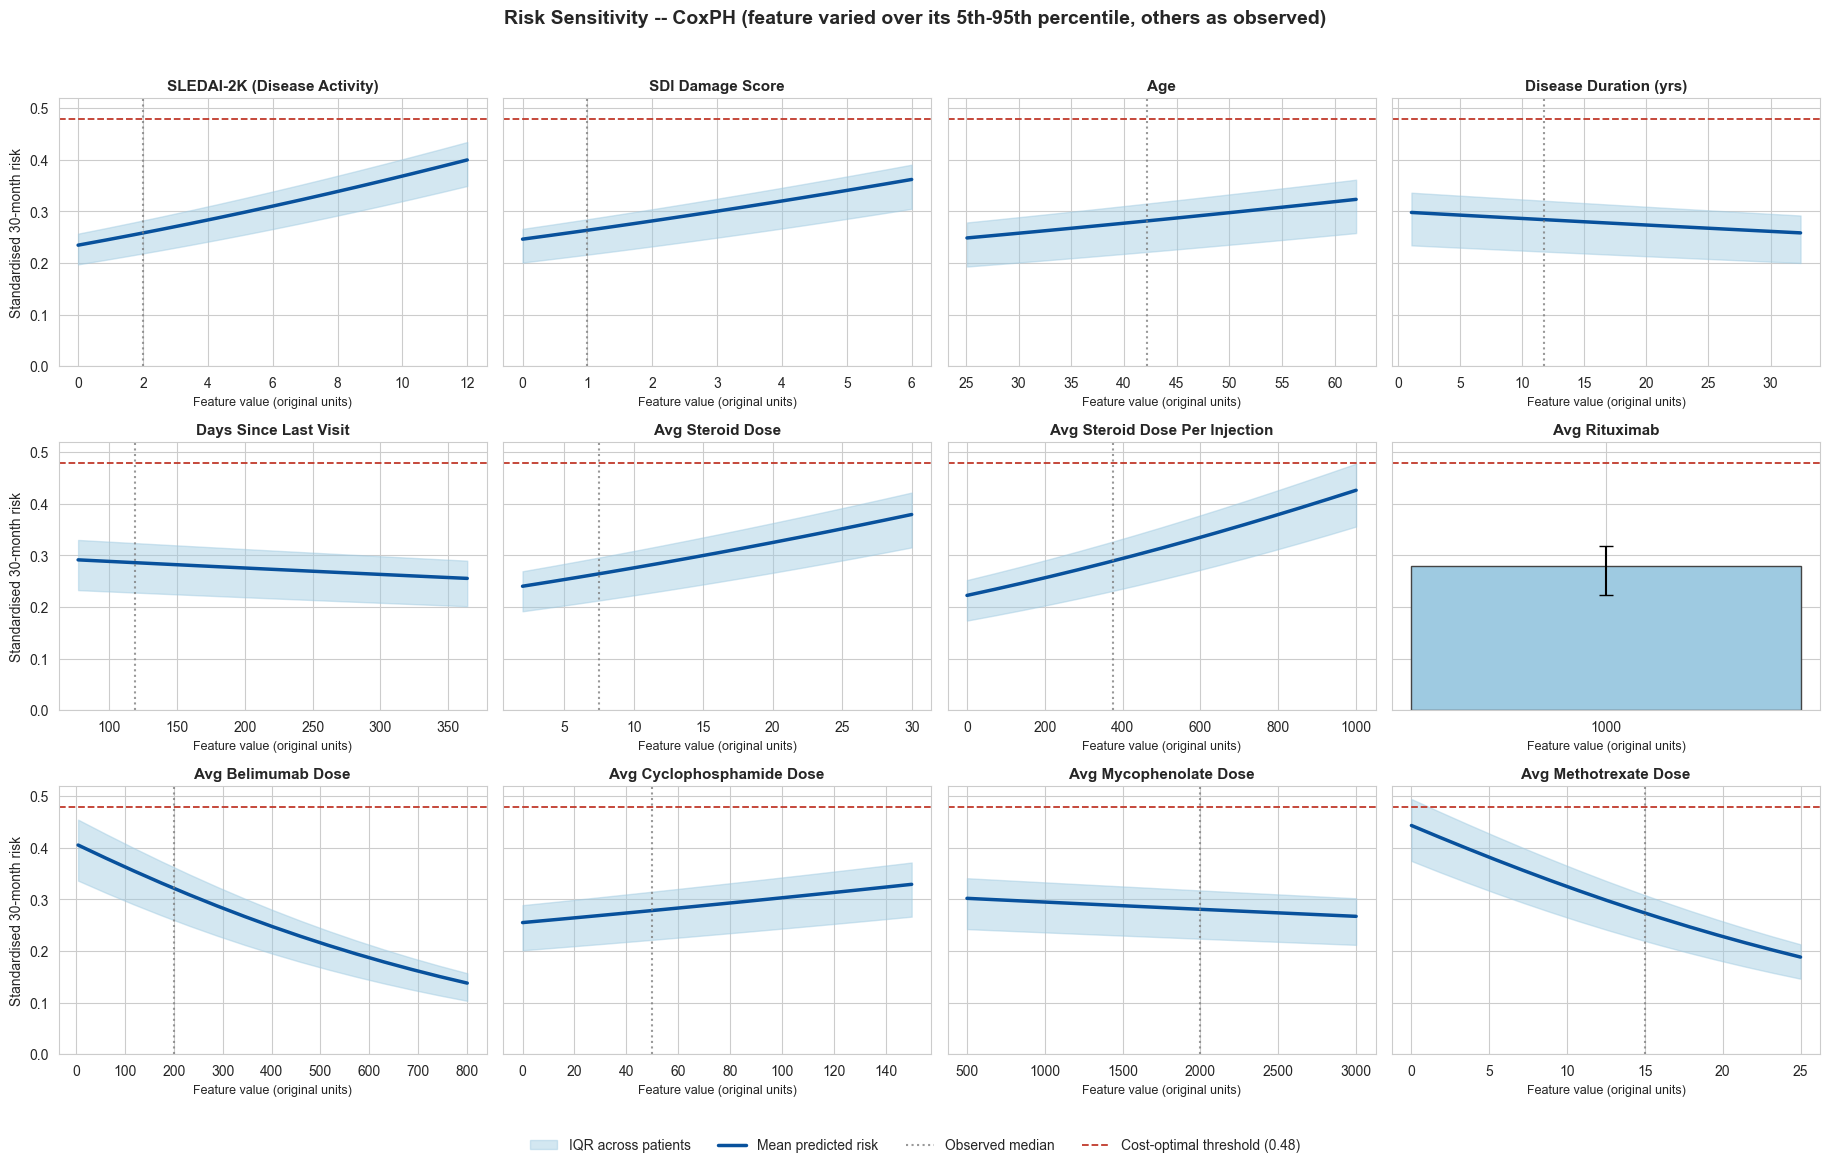


Risk-sensitivity summary -- CoxPH (mean standardised risk; ranked by swing)
                       Feature  Risk @ low value  Risk @ high value  Risk swing (max-min)
            Avg Belimumab Dose             0.405              0.138                 0.267
         Avg Methotrexate Dose             0.443              0.188                 0.255
Avg Steroid Dose Per Injection             0.222              0.426                 0.204
  SLEDAI-2K (Disease Activity)             0.235              0.400                 0.165
              Avg Steroid Dose             0.240              0.379                 0.139
              SDI Damage Score             0.246              0.362                 0.116
                           Age             0.249              0.323                 0.075
     Avg Cyclophosphamide Dose             0.255              0.329                 0.074
        Disease Duration (yrs)             0.298              0.258                 0.040
         Days Since Las

In [7]:
"""Landmark Cox Proportional Hazards model, 30-month work-disability risk
(SLE), DAE-imputed features, balanced (oversampled) fit. Adapted from the
notebook's LandmarkSurvivalCoxPH."""
import numpy as np
import pandas as pd
import random
import torch
from sklearn.preprocessing import StandardScaler
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index


random.seed(240); np.random.seed(240); torch.manual_seed(240)


class LandmarkSurvivalCoxPH:
    def __init__(self, horizon_days=913):
        self.horizon_days = horizon_days
        self.feature_cols = FEATURE_COLS
        self.scaler = StandardScaler()
        self.model = CoxPHFitter(penalizer=0.1)
        self.dae = None
        self.final_scaler = MinMaxScaler(feature_range=(0, 1))
        self.calibrator = None
    def prepare_data(self, land):
        raw = land[self.feature_cols].values.astype(float)
        print("Training Denoising Autoencoder for feature imputation...")
        self.dae = train_dae(raw, epochs=100)
        imputed = impute_with_dae(self.dae, raw)
        self.imputed = imputed  # unscaled, imputed features (used by risk-sensitivity analysis)
        scaled = self.scaler.fit_transform(imputed)

        data = land.copy().reset_index(drop=True)
        data[self.feature_cols] = scaled
        return data

    def _predict_risk_override(self, rows, j, v):
        """Calibrated risk for landmark `rows` with feature j forced to v (original units)."""
        Xm = self.imputed[rows].copy()
        Xm[:, j] = v
        df = pd.DataFrame(self.scaler.transform(Xm), columns=self.feature_cols)
        surv = self.model.predict_survival_function(df, times=[self.horizon_days]).T
        p = 1 - surv.values.flatten()
        calibrated = apply_risk_calibrator(self.calibrator, p)   # or `raw` in the GRU/LSTM cell
        return np.clip(self.final_scaler.transform(calibrated.reshape(-1, 1)).flatten(), 1e-5, 1 - 1e-5)
    def run_analysis(self, land):
        data = self.prepare_data(land)

        pos_df = data[data["label"] == 1]
        neg_df = data[data["label"] == 0]
        pos_over = pos_df.sample(n=len(neg_df), replace=True, random_state=240)
        balanced = pd.concat([neg_df, pos_over]).sample(frac=1, random_state=240)

        train_cols = self.feature_cols + ["duration", "event", "weight"]
        self.model.fit(balanced[train_cols], duration_col="duration", event_col="event",
                        weights_col="weight", robust=True)

        surv = self.model.predict_survival_function(data[self.feature_cols],
                                                      times=[self.horizon_days]).T
        risks_raw = 1 - surv.values.flatten()
        y = data["label"].values
        self.calibrator = fit_risk_calibrator(risks_raw, y, seed=240, model_name="CoxPH")   # or "RSF" / "CoxPH" / "GRU" / "LSTM"
        calibrated = apply_risk_calibrator(self.calibrator, risks_raw)
        risks = self.final_scaler.fit_transform(calibrated.reshape(-1, 1)).flatten()
        risks = np.clip(risks, 1e-5, 1 - 1e-5)        
        best_t = find_cost_optimal_threshold(y, risks)
        y_pred = (risks >= best_t).astype(int)
        c_idx = concordance_index(data["duration"], -risks, data["event"])

        report_comprehensive_metrics("CoxPH (DAE-imputed, balanced fit)", y, y_pred, risks, c_idx)
        meta = data.copy()
        meta["y_pred"] = y_pred
        print_operational_metrics("CoxPH", meta, label_col="label")
        print_cost_metrics("CoxPH", y, y_pred, best_t)
        plot_decision_curve("CoxPH", y, risks, color="#2ecc71")
        plot_risk_distribution_and_calibration("CoxPH", risks, y, best_t)
        plot_cost_decision_and_confusion("CoxPH", y, risks, best_t)

        sens_curves = compute_risk_sensitivity(self.feature_cols, land, self._predict_risk_override)
        plot_risk_sensitivity("CoxPH", sens_curves, best_t)

        print("\nCox model coefficients (hazard ratios):")
        print(self.model.summary[["coef", "exp(coef)", "p"]])

        return {"model": self, "risks": risks, "y": y, "y_pred": y_pred, "c_index": c_idx,
                "best_t": best_t, "sensitivity": sens_curves}

cox_pipeline = LandmarkSurvivalCoxPH(horizon_days=HORIZON_DAYS)
res_cox = cox_pipeline.run_analysis(land)

## Model 4/5 — Sequential GRU

Temporal (GRU) autoencoder imputation over the last 12 visits, followed by a
2-layer GRU classifier trained on class-balanced minibatches. Reports the
same comprehensive metrics as the tabular models plus the full performance
grid (ROC / PR / sensitivity-specificity / PPV-NPV), a cost-weighted
confusion matrix, and risk-sensitivity plots (in place of permutation feature
importance).


Training Temporal GRU Autoencoder for Imputation...
Training Survival GRU...
[GRU] Landmark sample prevalence: 4.1%  |  Calibration-fold prevalence: 4.1%  |  Target prevalence used: 4.1%

GRU (Sequential) -- 30-MONTH WORK-DISABILITY RISK: COMPREHENSIVE METRICS
------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO            
------------------------------------------------------------------------------
Concordance Index              | 0.7468     | Discrimination
Brier Score                    | 0.0433     | Overall accuracy (lower=better)
Calibration Slope              | 0.6236     | Ideal = 1.0
Calibration Intercept          | -0.0770     | Ideal = 0.0
Sensitivity                    | 0.8066     | [0.771, 0.837]
Specificity                    | 0.9121     | [0.907, 0.917]
PPV                            | 0.2826     | [0.261, 0.305]
NPV                            | 0.9910     | [0.989, 0.993]
Balanced 

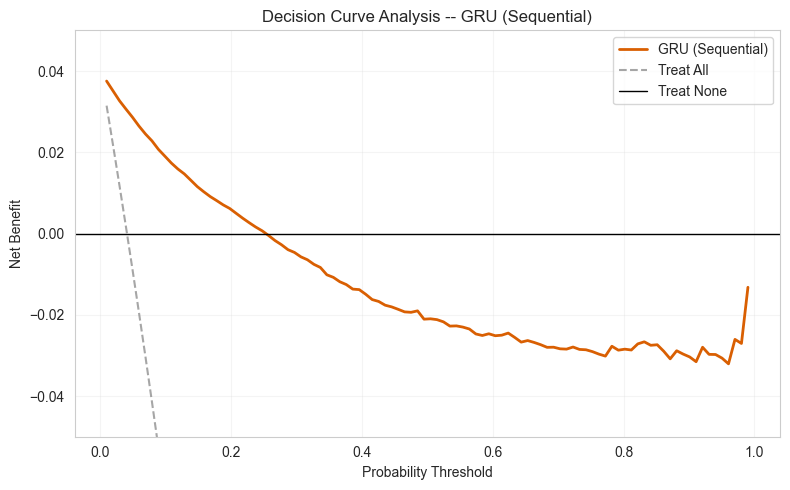

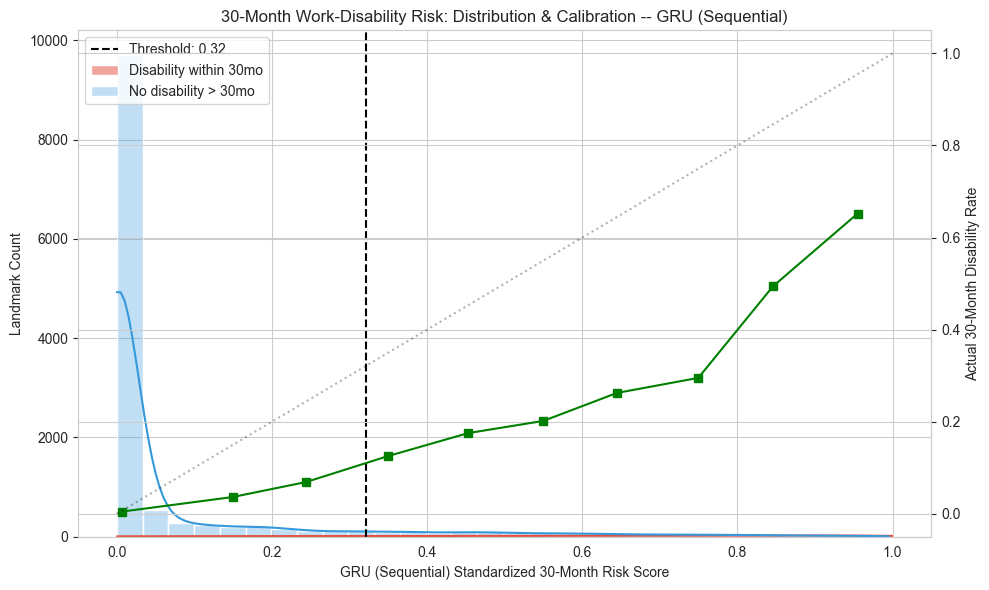

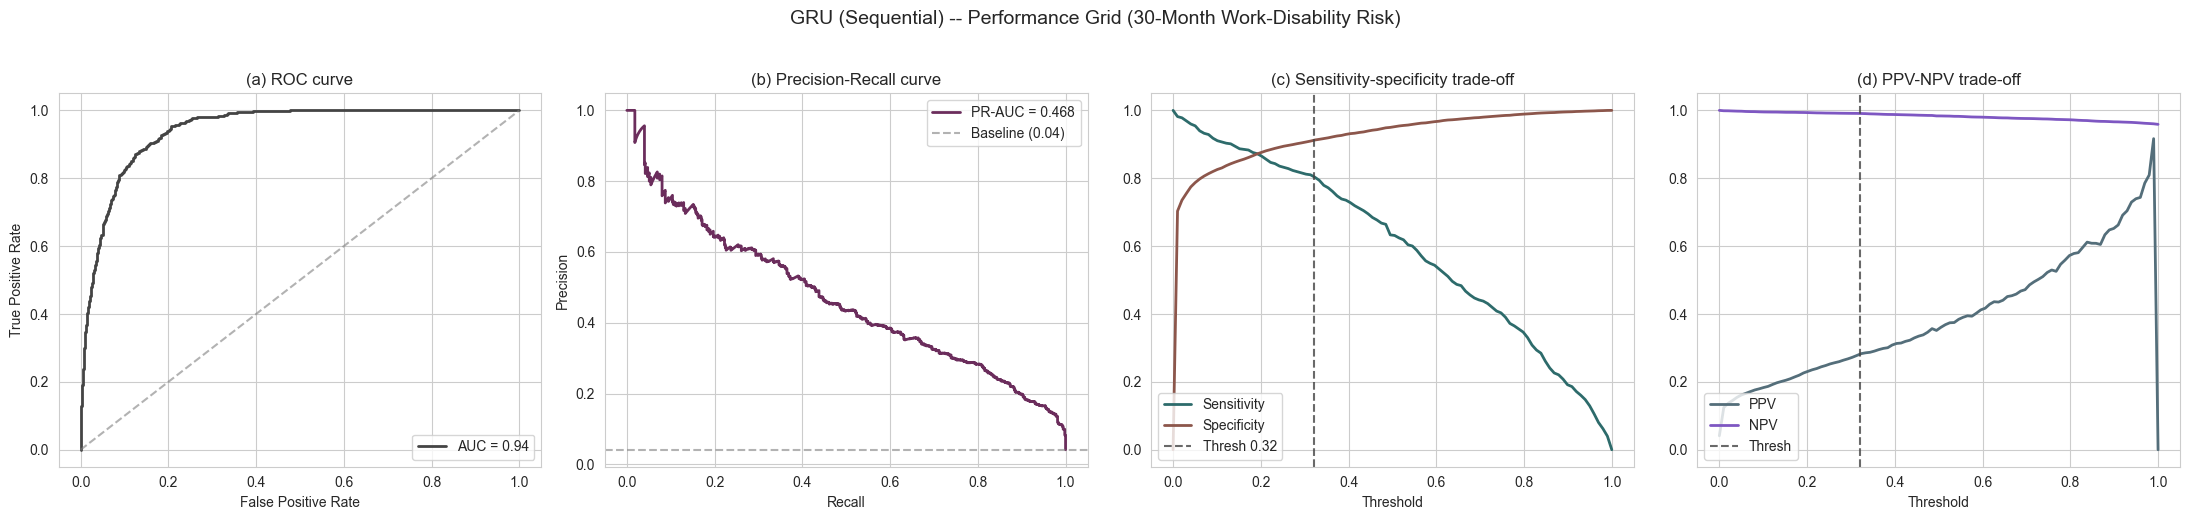

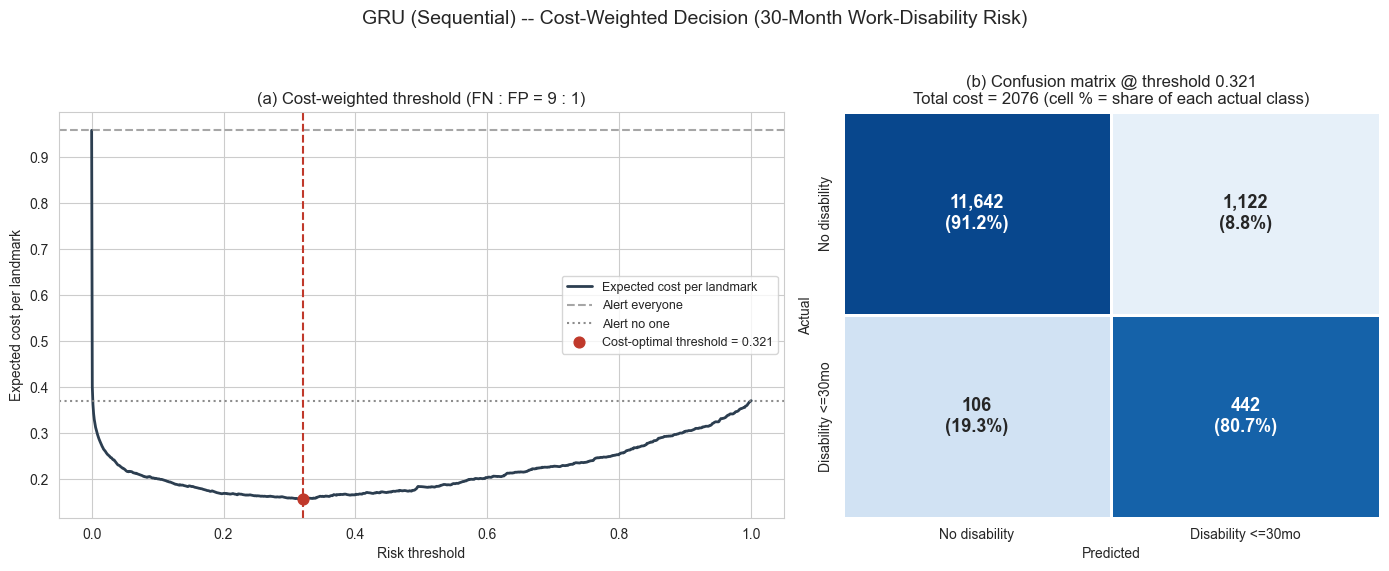

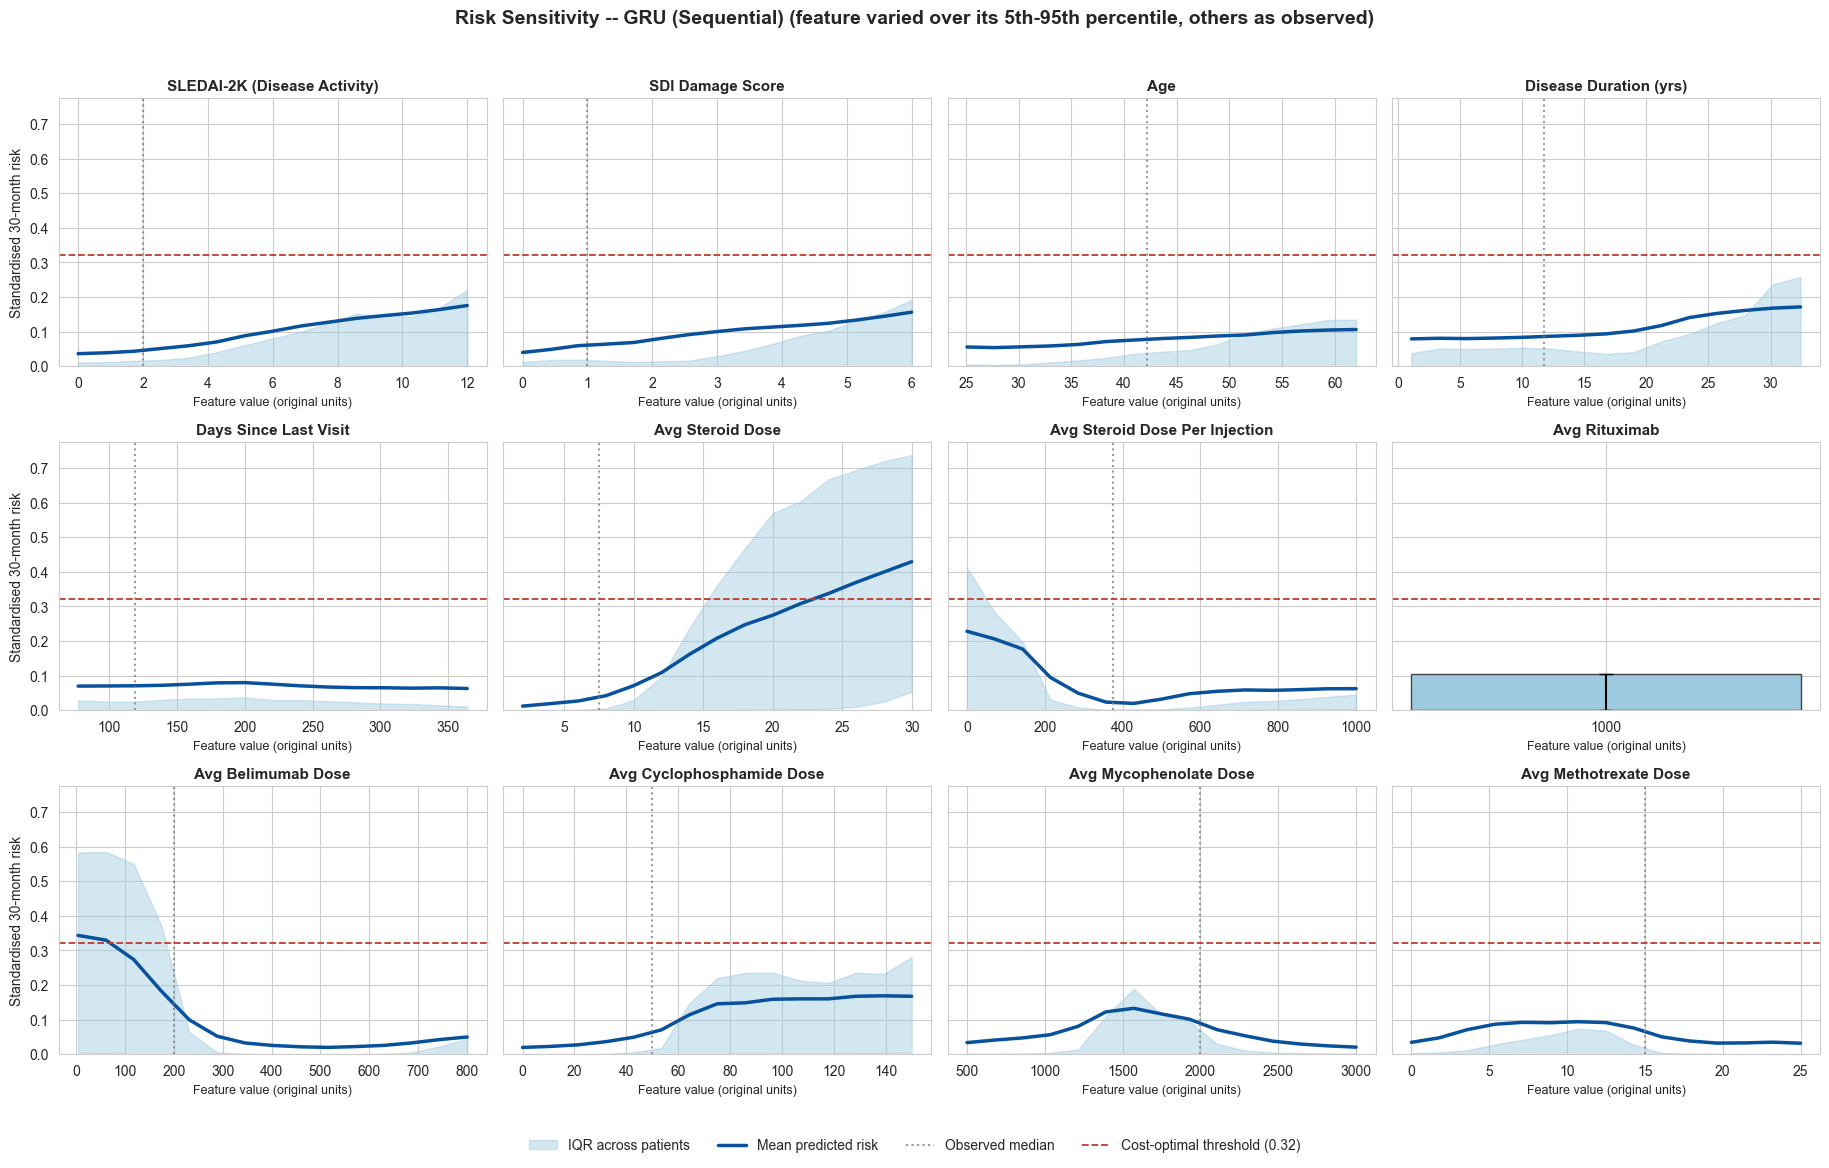


Risk-sensitivity summary -- GRU (Sequential) (mean standardised risk; ranked by swing)
                       Feature  Risk @ low value  Risk @ high value  Risk swing (max-min)
              Avg Steroid Dose             0.012              0.429                 0.417
            Avg Belimumab Dose             0.344              0.050                 0.324
Avg Steroid Dose Per Injection             0.228              0.062                 0.208
     Avg Cyclophosphamide Dose             0.020              0.168                 0.149
  SLEDAI-2K (Disease Activity)             0.036              0.176                 0.139
              SDI Damage Score             0.040              0.156                 0.116
        Avg Mycophenolate Dose             0.034              0.021                 0.112
        Disease Duration (yrs)             0.079              0.171                 0.092
         Avg Methotrexate Dose             0.034              0.032                 0.062
            

In [8]:
"""Sequential (GRU / LSTM) landmark model for 30-month work-disability risk.
Same architecture as before (temporal autoencoder imputer + 2-layer recurrent
classifier with sigmoid head, trained on balanced 1:1 minibatches), but the
final MinMaxScaler rescale is replaced with a post-hoc Platt/isotonic
calibrator fit on a held-out split -- see fit_risk_calibrator /
apply_risk_calibrator in the shared-utilities cell."""
import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from lifelines.utils import concordance_index


def masked_mse(y_true, y_pred, mask):
    diff2 = (y_true - y_pred) ** 2 * mask
    return diff2.sum() / (mask.sum() + 1e-7)


class RecurrentAutoencoder(nn.Module):
    def __init__(self, input_dim, cell="gru"):
        super().__init__()
        rnn = nn.GRU if cell == "gru" else nn.LSTM
        self.enc1 = rnn(input_dim, 64, batch_first=True)
        self.enc2 = rnn(64, 32, batch_first=True)
        self.dec1 = rnn(32, 32, batch_first=True)
        self.dec2 = rnn(32, 64, batch_first=True)
        self.out = nn.Linear(64, input_dim)

    def forward(self, x):
        seq_len = x.shape[1]
        h, _ = self.enc1(x)
        _, hN = self.enc2(h)
        latent = hN[0] if isinstance(hN, tuple) else hN
        latent = latent[-1]  # (batch, 32)
        rep = latent.unsqueeze(1).repeat(1, seq_len, 1)
        h, _ = self.dec1(rep)
        h, _ = self.dec2(h)
        return self.out(h)


class RecurrentClassifier(nn.Module):
    def __init__(self, input_dim, cell="gru"):
        super().__init__()
        rnn = nn.GRU if cell == "gru" else nn.LSTM
        self.rnn1 = rnn(input_dim, 64, batch_first=True)
        self.drop1 = nn.Dropout(0.3)
        self.bn = nn.BatchNorm1d(64)
        self.rnn2 = rnn(64, 32, batch_first=True)
        self.drop2 = nn.Dropout(0.2)
        self.head = nn.Linear(32, 1)

    def forward(self, x):
        h, _ = self.rnn1(x)
        h = self.drop1(h)
        b, t, f = h.shape
        h = self.bn(h.reshape(b * t, f)).reshape(b, t, f)
        h, _ = self.rnn2(h)
        h = self.drop2(h)
        out = torch.sigmoid(self.head(h))
        return out  # (batch, seq, 1)


class SequentialSurvivalRNN:
    """cell='gru' or 'lstm'"""

    def __init__(self, cell="gru", sequence_length=12, horizon_days=913, seed=240):
        self.cell = cell
        self.sequence_length = sequence_length
        self.horizon_days = horizon_days
        self.feature_cols = FEATURE_COLS
        self.scaler = StandardScaler()
        self.autoencoder = None
        self.model = None
        self.final_scaler = MinMaxScaler(feature_range=(0, 1))
        self.calibrator = None        
        self.seed = seed
        random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

    def _train_autoencoder(self, X_with_nan, epochs=30, batch_size=32):
        name = self.cell.upper()
        print(f"Training Temporal {name} Autoencoder for Imputation...")
        X_masked = np.nan_to_num(X_with_nan, nan=-999.0)
        mask = ~np.isnan(X_with_nan)
        X_t = torch.FloatTensor(X_masked)
        mask_t = torch.FloatTensor(mask.astype(float))

        ae = RecurrentAutoencoder(self.input_dim, cell=self.cell)
        opt = optim.Adam(ae.parameters(), lr=1e-3)
        n = len(X_t)
        for _ in range(epochs):
            perm = torch.randperm(n)
            for start in range(0, n, batch_size):
                idx = perm[start:start + batch_size]
                xb, mb = X_t[idx], mask_t[idx]
                opt.zero_grad()
                pred = ae(xb)
                loss = masked_mse(xb, pred, mb)
                loss.backward()
                opt.step()
        self.autoencoder = ae

    def _impute(self, X_raw):
        self.autoencoder.eval()
        X_masked = np.nan_to_num(X_raw, nan=-999.0)
        with torch.no_grad():
            preds = self.autoencoder(torch.FloatTensor(X_masked)).numpy()
        return np.where(np.isnan(X_raw), preds, X_raw)

    def prepare_data(self, land, X_seq):
        self.input_dim = len(self.feature_cols)
        flat = land[self.feature_cols].values.astype(float)
        self.scaler.fit(np.nan_to_num(flat, nan=np.nanmedian(flat, axis=0)))

        seq_shape = X_seq.shape
        flat_seq = X_seq.reshape(-1, seq_shape[-1])
        scaled_flat = np.full_like(flat_seq, np.nan)
        not_nan = ~np.isnan(flat_seq).all(axis=1)
        scaled_flat[not_nan] = self.scaler.transform(
            np.nan_to_num(flat_seq[not_nan], nan=np.nanmedian(flat, axis=0)))
        scaled_flat[np.isnan(flat_seq)] = np.nan
        X_scaled = scaled_flat.reshape(seq_shape)

        if self.autoencoder is None:
            self._train_autoencoder(X_scaled)
        X_final = self._impute(X_scaled)

        y = land["label"].values.astype(np.float32)
        weight = land["weight"].values.astype(np.float32)
        return X_final.astype(np.float32), y, weight

    def _build_classifier(self):
        return RecurrentClassifier(self.input_dim, cell=self.cell)

    def _balanced_batch(self, X, y, weight, batch_size=32):
        pos_idx = np.where(y == 1)[0]
        neg_idx = np.where(y == 0)[0]
        pos_w = weight[pos_idx] / weight[pos_idx].sum()
        neg_w = weight[neg_idx] / weight[neg_idx].sum()
        half = batch_size // 2
        while True:
            bp = np.random.choice(pos_idx, half, p=pos_w)
            bn = np.random.choice(neg_idx, half, p=neg_w)
            idx = np.concatenate([bp, bn])
            np.random.shuffle(idx)
            yield X[idx], y[idx]

    def run_analysis(self, land, X_seq, epochs=25, steps_per_epoch=None):
        X, y_true, weight = self.prepare_data(land, X_seq)
        self.model = self._build_classifier()
        opt = optim.Adam(self.model.parameters(), lr=1e-3)
        bce = nn.BCELoss()

        gen = self._balanced_batch(X, y_true, weight, 32)
        spe = steps_per_epoch or max(1, len(X) // 32)

        print(f"Training Survival {self.cell.upper()}...")
        self.model.train()
        for ep in range(epochs):
            for _ in range(spe):
                xb, yb = next(gen)
                xb_t = torch.FloatTensor(xb)
                yb_t = torch.FloatTensor(yb).view(-1, 1, 1).repeat(1, self.sequence_length, 1)
                opt.zero_grad()
                pred = self.model(xb_t)
                loss = bce(pred, yb_t)
                loss.backward()
                opt.step()

        self.model.eval()
        with torch.no_grad():
            raw_preds = self.model(torch.FloatTensor(X)).numpy()
        visit_risks_raw = raw_preds[:, -1, 0]
        self.calibrator = fit_risk_calibrator(visit_risks_raw, y_true, seed=240, model_name="GRU")
        calibrated = apply_risk_calibrator(self.calibrator, visit_risks_raw)
        visit_risks = self.final_scaler.fit_transform(calibrated.reshape(-1, 1)).flatten()
        visit_risks = np.clip(visit_risks, 1e-5, 1 - 1e-5)        

        duration = land["duration"].values
        event = land["event"].values
        c_val = concordance_index(duration, 1 - visit_risks, event)

        best_t = find_cost_optimal_threshold(y_true, visit_risks)
        y_pred = (visit_risks >= best_t).astype(int)

        name = f"{self.cell.upper()} (Sequential)"
        report_comprehensive_metrics(name, y_true, y_pred, visit_risks, c_val)
        meta = land.copy()
        meta["y_pred"] = y_pred
        print_operational_metrics(name, meta, label_col="label")
        print_cost_metrics(name, y_true, y_pred, best_t)
        color = "#d95f02" if self.cell == "gru" else "#2c7da0"
        plot_decision_curve(name, y_true, visit_risks, color=color)
        plot_risk_distribution_and_calibration(name, visit_risks, y_true, best_t)
        plot_performance_grid(name, y_true, visit_risks, best_t)

        plot_cost_decision_and_confusion(name, y_true, visit_risks, best_t)

        sens_curves = compute_risk_sensitivity(
            self.feature_cols, land,
            lambda rows, j, v: self._predict_risk_override(X, rows, j, v))
        plot_risk_sensitivity(name, sens_curves, best_t)

        return {"model": self, "risks": visit_risks, "y": y_true, "y_pred": y_pred,
                "c_index": c_val, "best_t": best_t, "X": X, "sensitivity": sens_curves}

    def _predict_risk_override(self, X, rows, j, v):
        """Calibrated risk for landmark `rows` with feature j held at value v (original
        units) at every visit of the 12-visit input window."""
        Xm = X[rows].copy()
        Xm[:, :, j] = (v - self.scaler.mean_[j]) / self.scaler.scale_[j]
        self.model.eval()
        with torch.no_grad():
            raw = self.model(torch.FloatTensor(Xm)).numpy()[:, -1, 0]
        calibrated = apply_risk_calibrator(self.calibrator, raw)   # or `raw` in the GRU/LSTM cell
        return np.clip(self.final_scaler.transform(calibrated.reshape(-1, 1)).flatten(), 1e-5, 1 - 1e-5)
gru_pipeline = SequentialSurvivalRNN(cell='gru', horizon_days=HORIZON_DAYS)
res_gru = gru_pipeline.run_analysis(land, X_seq, epochs=25)

## Model 5/5 — Sequential LSTM

Training Temporal LSTM Autoencoder for Imputation...
Training Survival LSTM...
[GRU] Landmark sample prevalence: 4.1%  |  Calibration-fold prevalence: 4.1%  |  Target prevalence used: 4.1%

LSTM (Sequential) -- 30-MONTH WORK-DISABILITY RISK: COMPREHENSIVE METRICS
------------------------------------------------------------------------------
METRIC                         | VALUE      | 95% CI / INFO            
------------------------------------------------------------------------------
Concordance Index              | 0.7623     | Discrimination
Brier Score                    | 0.0306     | Overall accuracy (lower=better)
Calibration Slope              | 0.7324     | Ideal = 1.0
Calibration Intercept          | -0.1137     | Ideal = 0.0
Sensitivity                    | 0.8577     | [0.826, 0.884]
Specificity                    | 0.9366     | [0.932, 0.941]
PPV                            | 0.3675     | [0.341, 0.394]
NPV                            | 0.9935     | [0.992, 0.995]
Balanc

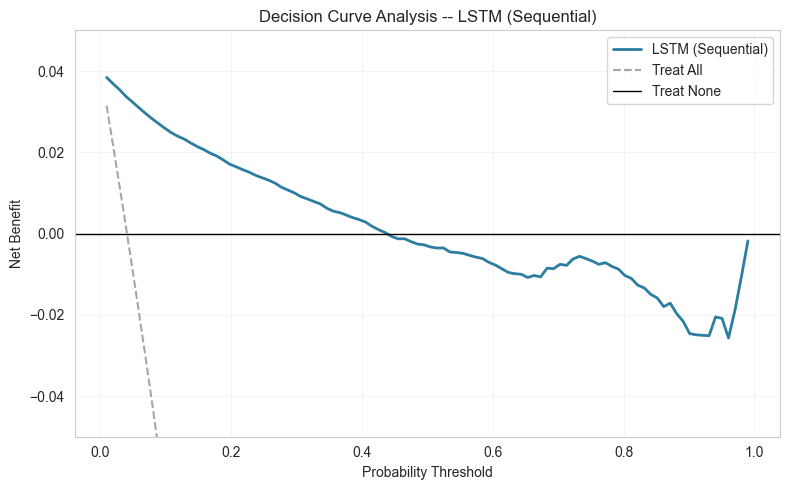

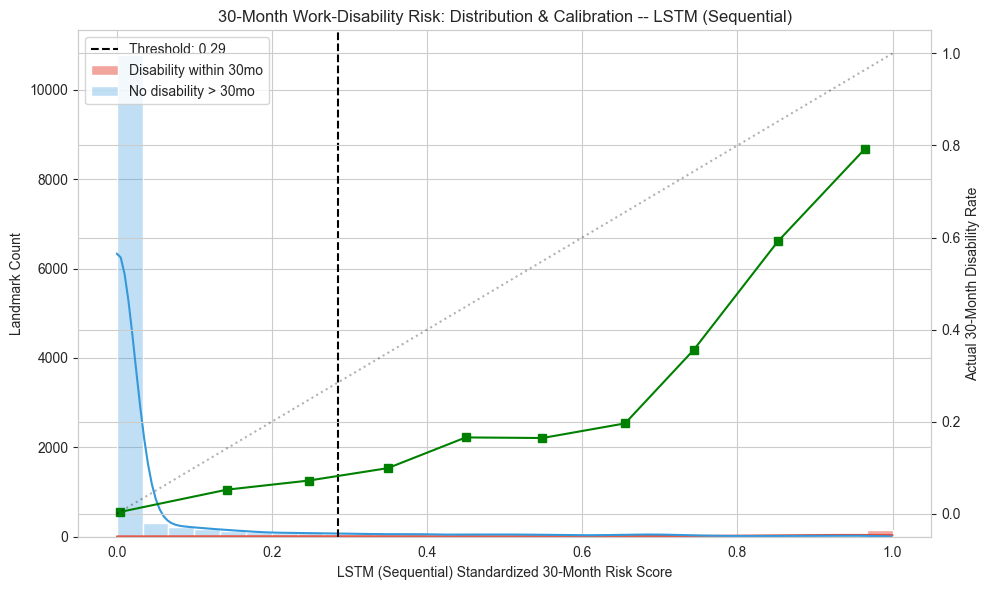

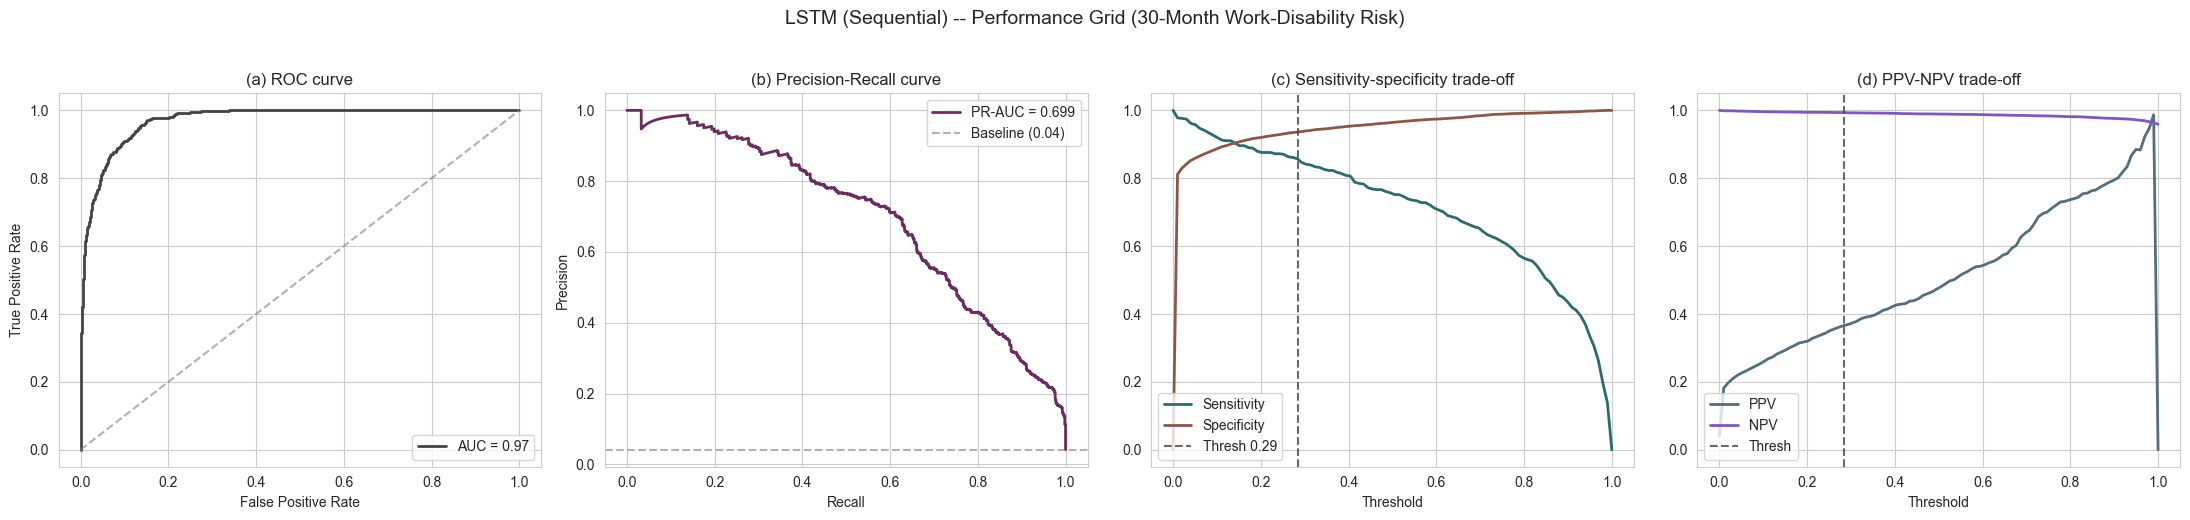

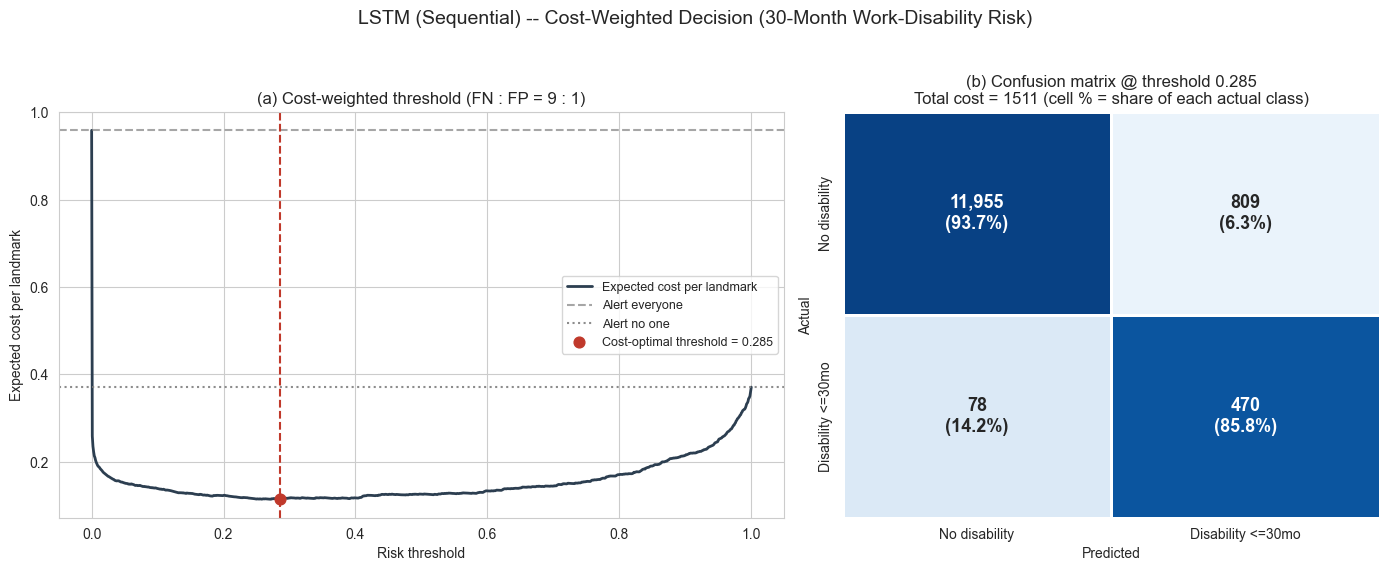

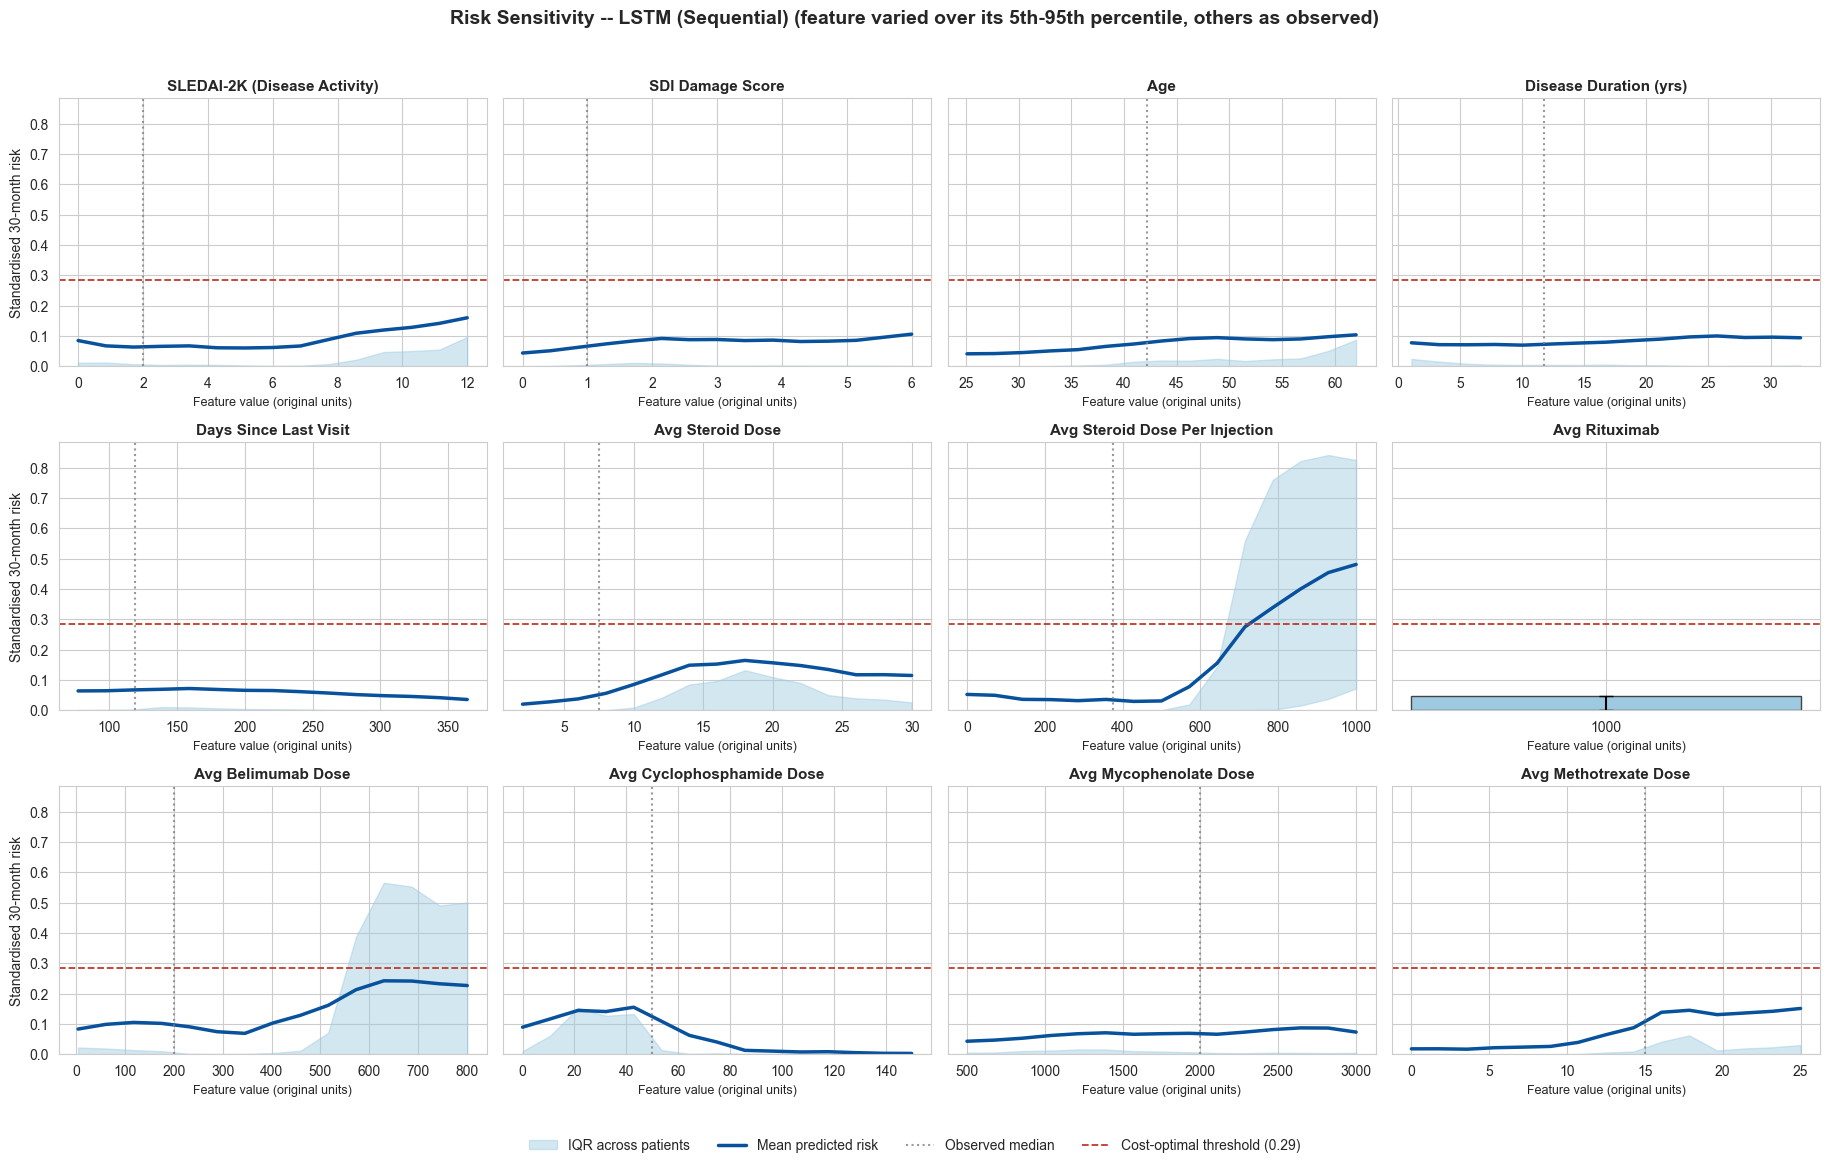


Risk-sensitivity summary -- LSTM (Sequential) (mean standardised risk; ranked by swing)
                       Feature  Risk @ low value  Risk @ high value  Risk swing (max-min)
Avg Steroid Dose Per Injection             0.052              0.481                 0.451
            Avg Belimumab Dose             0.083              0.227                 0.173
     Avg Cyclophosphamide Dose             0.089              0.003                 0.152
              Avg Steroid Dose             0.020              0.115                 0.144
         Avg Methotrexate Dose             0.018              0.151                 0.134
  SLEDAI-2K (Disease Activity)             0.085              0.160                 0.100
                           Age             0.041              0.104                 0.063
              SDI Damage Score             0.044              0.106                 0.062
        Avg Mycophenolate Dose             0.043              0.073                 0.044
         Da

In [9]:
lstm_pipeline = SequentialSurvivalRNN(cell='lstm', horizon_days=HORIZON_DAYS)
res_lstm = lstm_pipeline.run_analysis(land, X_seq, epochs=25)

In [10]:
w_eff = land["weight"].values * np.where(land["label"]==1, 
        len(land)/(2*land["label"].sum()), len(land)/(2*(len(land)-land["label"].sum())))
print(pd.Series(w_eff).groupby(land["label"]).sum())

label
0     418.843987
1    1042.079108
dtype: float64


## Cross-Model Calibration Comparison

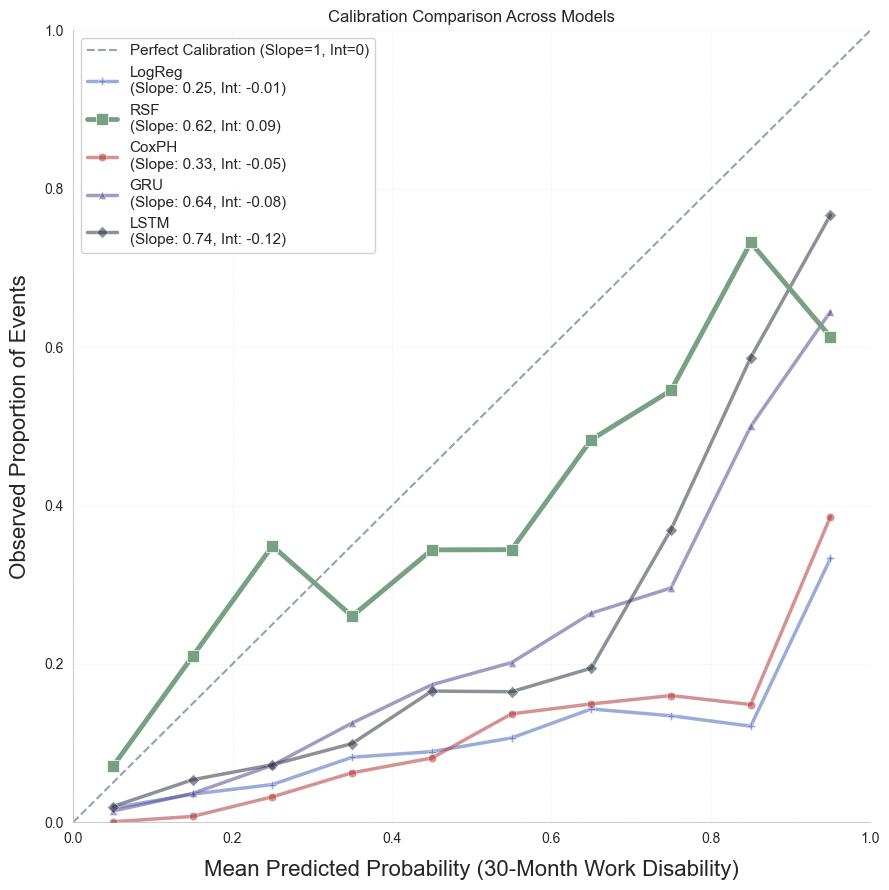

In [11]:
"""Cross-model calibration comparison plot (mirrors the notebook's 'Plots'
cell), built here from each model's *actual* calibration-curve output on
the SLE landmark data rather than the original notebook's hard-coded demo
numbers."""
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.calibration import calibration_curve


def plot_calibration_comparison(results, save="figs/calibration_comparison.pdf"):
    """results: dict of {model_name: (y_true, risks)}"""
    bin_centers = np.linspace(0.05, 0.95, 10)

    plt.figure(figsize=(9, 9), facecolor="white")
    plt.plot([0, 1], [0, 1], linestyle="--", color="#7f8c8d",
              label="Perfect Calibration (Slope=1, Int=0)", alpha=0.8, lw=1.5)

    colors = ["#4a69bd", "#78a083", "#b33939", "#574b90", "#2f3542"]
    markers = ["P", "s", "o", "^", "D"]
    highlight = max(results, key=lambda k: results[k][2])  # highest c-index gets highlighted

    for (model_name, (y_true, risks, _)), color, marker in zip(results.items(), colors, markers):
        prob_true, prob_pred = calibration_curve(y_true, risks, n_bins=10)
        # align onto common bin centers via interpolation for a clean comparison line
        observed = np.interp(bin_centers, prob_pred, prob_true)
        slope, intercept, _, _, _ = stats.linregress(bin_centers, observed)
        label_text = f"{model_name}\n(Slope: {slope:.2f}, Int: {intercept:.2f})"

        is_highlight = model_name == highlight
        plt.plot(bin_centers, observed, marker=marker, label=label_text, color=color,
                  lw=3.5 if is_highlight else 2.5, markersize=9 if is_highlight else 6,
                  alpha=1.0 if is_highlight else 0.55,
                  zorder=10 if is_highlight else 5, markeredgecolor="white", markeredgewidth=0.5)

    plt.xlabel("Mean Predicted Probability (30-Month Work Disability)", fontsize=16, labelpad=10)
    plt.ylabel("Observed Proportion of Events", fontsize=16, labelpad=10)
    plt.legend(loc="upper left", fontsize=11, frameon=True, facecolor="white", framealpha=0.9)
    plt.grid(True, linestyle=":", alpha=0.4, color="#ced4da")
    plt.xlim([0, 1]); plt.ylim([0, 1])
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.title("Calibration Comparison Across Models")
    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

all_results = {
    'LogReg': (res_logreg['y'], res_logreg['risks'], res_logreg['c_index']),
    'RSF': (res_rsf['y'], res_rsf['risks'], res_rsf['c_index']),
    'CoxPH': (res_cox['y'], res_cox['risks'], res_cox['c_index']),
    'GRU': (res_gru['y'], res_gru['risks'], res_gru['c_index']),
    'LSTM': (res_lstm['y'], res_lstm['risks'], res_lstm['c_index']),
}
plot_calibration_comparison(all_results)

## SHAP Dashboard

The original notebook's SHAP cell imports an external `grumodelwdashboard.py`
module that was not included in the uploaded files, so it could not be run
verbatim. This reproduces its intent directly against the best-discriminating
sequential model using the `shap` package: SHAP attribution is computed for
each landmark's most recent ("current-visit") feature vector, tiled across
the model's fixed 12-visit input window.


Best model by C-index: RSF (0.8416)
Computing SHAP values (KernelExplainer over the last-visit state)...


PermutationExplainer explainer: 301it [07:35,  1.53s/it]                         


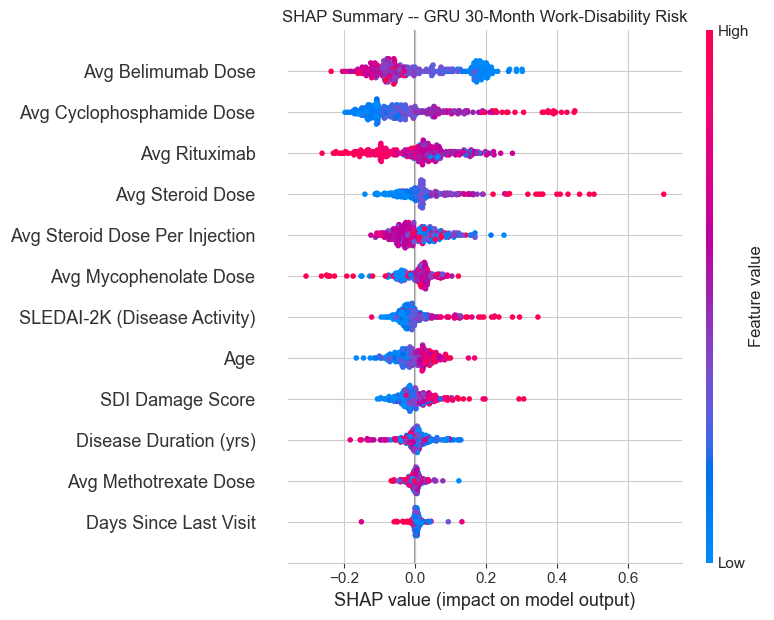

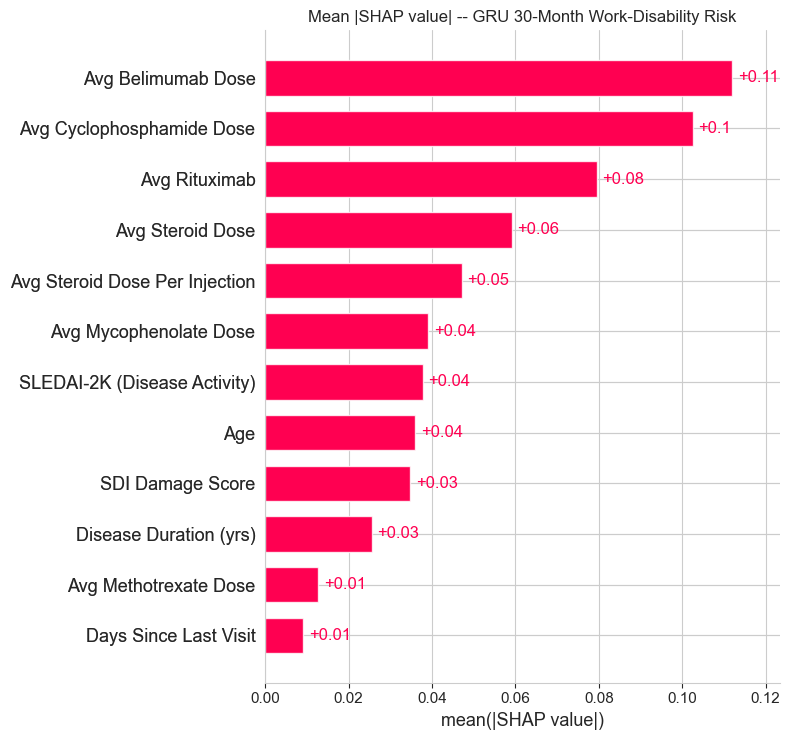

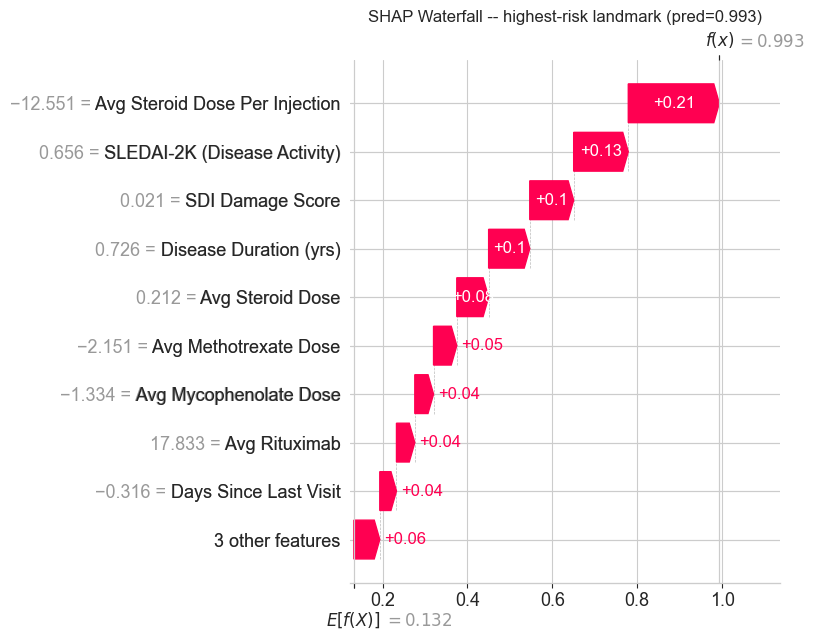

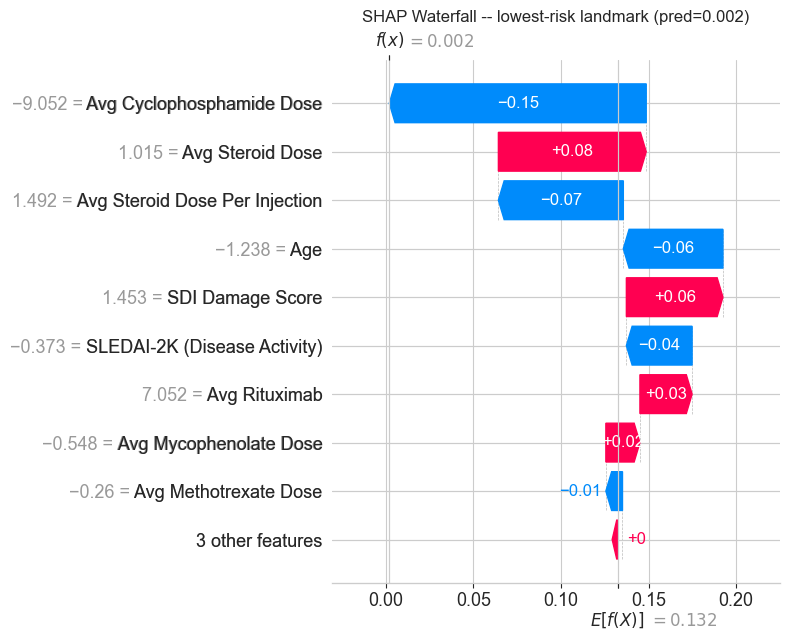


SHAP FEATURE IMPORTANCE (mean |SHAP| over sampled landmarks)
-------------------------------------------------------
                       Feature  Mean |SHAP|
            Avg Belimumab Dose     0.111979
     Avg Cyclophosphamide Dose     0.102556
                 Avg Rituximab     0.079544
              Avg Steroid Dose     0.059130
Avg Steroid Dose Per Injection     0.047151
        Avg Mycophenolate Dose     0.039132
  SLEDAI-2K (Disease Activity)     0.037870
                           Age     0.035961
              SDI Damage Score     0.034766
        Disease Duration (yrs)     0.025607
         Avg Methotrexate Dose     0.012708
         Days Since Last Visit     0.009140


In [12]:
"""SHAP explainability dashboard for the trained GRU sequential model.

The original notebook's SHAP/dashboard cell imports a separate, not-supplied
module (`grumodelwdashboard.py`) that is not part of this upload, so it
cannot be executed verbatim. This module reproduces its intent -- a SHAP
explanation layer on top of the best-performing sequential model -- using
the `shap` package directly against the trained GRU classifier from
model_sequential.py.

Because the classifier consumes a (patients, 12-visit, 8-feature) tensor,
SHAP attribution is computed for the "current visit" (the most recent,
last-timestep) feature vector: a background/foreground wrapper tiles each
candidate current-visit vector across the model's fixed sequence length so
that the model sees a constant short-term trajectory ending at that visit.
This is the standard simplification used to make a recurrent risk model
locally explainable at the point of a single clinical visit.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import torch



def run_shap_dashboard(pipeline, land, X_seq, n_background=100, n_explain=300, seed=240):
    rng = np.random.RandomState(seed)
    model = pipeline.model
    model.eval()
    seq_len = pipeline.sequence_length
    feature_names = [DISPLAY_NAMES.get(c, c) for c in pipeline.feature_cols]

    # Last-visit (current-state) feature vectors, in the *model's* scaled
    # space, for every landmark row.
    last_visit = X_seq[:, -1, :]  # already imputed+scaled inside prepare_data
    # Recompute scaled/imputed last-visit features the same way prepare_data does.
    X_full, y_true, weight = pipeline.prepare_data(land, X_seq)
    last_visit_scaled = X_full[:, -1, :]

    def predict_fn(current_visit_batch):
        current_visit_batch = np.asarray(current_visit_batch, dtype=np.float32)
        n = current_visit_batch.shape[0]
        seq = np.repeat(current_visit_batch[:, None, :], seq_len, axis=1)
        with torch.no_grad():
            out = model(torch.FloatTensor(seq)).numpy()
        return out[:, -1, 0]

    bg_idx = rng.choice(len(last_visit_scaled), size=min(n_background, len(last_visit_scaled)),
                         replace=False)
    background = last_visit_scaled[bg_idx]

    ex_idx = rng.choice(len(last_visit_scaled), size=min(n_explain, len(last_visit_scaled)),
                         replace=False)
    explain_set = last_visit_scaled[ex_idx]

    print("Computing SHAP values (KernelExplainer over the last-visit state)...")
    masker = shap.maskers.Independent(background, max_samples=len(background))
    explainer = shap.Explainer(predict_fn, masker, feature_names=feature_names)
    shap_values = explainer(explain_set)

    # --- Summary (beeswarm) plot ---
    plt.figure()
    shap.plots.beeswarm(shap_values, show=False, max_display=len(feature_names))
    plt.title("SHAP Summary -- GRU 30-Month Work-Disability Risk")
    plt.tight_layout()
    plt.savefig("figs/shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # --- Mean |SHAP| bar plot ---
    plt.figure()
    shap.plots.bar(shap_values, show=False, max_display=len(feature_names))
    plt.title("Mean |SHAP value| -- GRU 30-Month Work-Disability Risk")
    plt.tight_layout()
    plt.savefig("figs/shap_bar.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # --- Individual waterfall plots for a high-risk and a low-risk patient ---
    preds = predict_fn(explain_set)
    hi = int(np.argmax(preds))
    lo = int(np.argmin(preds))
    for label, idx in [("highest-risk", hi), ("lowest-risk", lo)]:
        plt.figure()
        shap.plots.waterfall(shap_values[idx], show=False)
        plt.title(f"SHAP Waterfall -- {label} landmark (pred={preds[idx]:.3f})")
        plt.tight_layout()
        plt.savefig(f"figs/shap_waterfall_{label.replace('-', '_')}.png", dpi=150,
                     bbox_inches="tight")
        plt.show()
        plt.close()

    mean_abs = np.abs(shap_values.values).mean(axis=0)
    imp_df = pd.DataFrame({"Feature": feature_names, "Mean |SHAP|": mean_abs}) \
        .sort_values("Mean |SHAP|", ascending=False)
    print("\n" + "=" * 55)
    print("SHAP FEATURE IMPORTANCE (mean |SHAP| over sampled landmarks)")
    print("-" * 55)
    print(imp_df.to_string(index=False))
    print("=" * 55)

    return shap_values, imp_df

best_name = max(all_results, key=lambda k: all_results[k][2])
print(f'Best model by C-index: {best_name} ({all_results[best_name][2]:.4f})')
shap_pipeline = lstm_pipeline if best_name == 'LSTM' else gru_pipeline
shap_values, shap_imp = run_shap_dashboard(shap_pipeline, land, X_seq,
                                            n_background=100, n_explain=300)

## Summary — All Models

In [ ]:
"""
Comprehensive Model Comparison & LaTeX Table Generator
Extracts metrics directly from trained model results with bootstrap standard errors,
automatically identifies top performers for bolding, and exports LaTeX tabular code.
"""
import numpy as np
import pandas as pd
from lifelines.utils import concordance_index
from sklearn.metrics import confusion_matrix

# 1. Map models to their result dictionaries
models = {
    "CoxPH": res_cox,
    "LR":    res_logreg,
    "RSF":   res_rsf,
    "GRU":   res_gru,
    "LSTM":  res_lstm,
}

# 2. Extract shared survival targets from the landmark dataset
durations = land["duration"].values.astype(float)
events = land["event"].values.astype(int)
n_samples = len(durations)

# 3. Helper to compute binary classification metrics
def compute_binary_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    bal_acc = 0.5 * (sens + spec)
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    return {
        "Sensitivity": sens,
        "Specificity": spec,
        "Bal. Acc": bal_acc,
        "PPV": ppv,
        "NPV": npv,
    }

# 4. Bootstrap routine to calculate mean/point estimates and standard deviations
N_BOOT = 500
RNG_SEED = 240
rng = np.random.RandomState(RNG_SEED)

metric_names = ["C-Index", "Sensitivity", "Specificity", "Bal. Acc", "PPV", "NPV"]
table_data = {}

print(f"Calculating point estimates and bootstrap SEs ({N_BOOT} iterations)...")

for name, res in models.items():
    risks = np.asarray(res["risks"], dtype=float)
    y_true = np.asarray(res["y"], dtype=int)
    threshold = float(res["best_t"])
    y_pred = (risks >= threshold).astype(int)

    # Point estimates on full landmark sample
    c_pt = concordance_index(durations, -risks, events)
    bin_pt = compute_binary_metrics(y_true, y_pred)
    point_estimates = {"C-Index": c_pt, **bin_pt}

    # Bootstrap distributions
    boot_metrics = {m: [] for m in metric_names}
    for _ in range(N_BOOT):
        boot_idx = rng.choice(n_samples, size=n_samples, replace=True)
        dur_b, ev_b = durations[boot_idx], events[boot_idx]
        y_b, risk_b = y_true[boot_idx], risks[boot_idx]
        pred_b = (risk_b >= threshold).astype(int)

        try:
            boot_metrics["C-Index"].append(concordance_index(dur_b, -risk_b, ev_b))
        except (ZeroDivisionError, ValueError):
            pass

        b_bin = compute_binary_metrics(y_b, pred_b)
        for k in b_bin:
            boot_metrics[k].append(b_bin[k])

    # Store point estimates and standard deviations
    stats_dict = {}
    for m in metric_names:
        pt = point_estimates[m]
        std = np.nanstd(boot_metrics[m])
        stats_dict[m] = (pt, std)
    
    stats_dict["Threshold"] = threshold
    table_data[name] = stats_dict

# 5. Identify maximum values across models for automatic bolding
max_values = {
    m: max(table_data[model][m][0] for model in table_data)
    for m in metric_names
}

# 6. Construct formatted rows for LaTeX and Pandas
latex_rows = []
df_display_rows = []

for model_name, metrics in table_data.items():
    latex_row = [f"{model_name:<5}"]
    df_row = {"Model": model_name}

    for m in metric_names:
        val, std = metrics[m]
        cell_str = f"{val:.2f} ({std:.2f})"
        
        # Bold if within 0.005 of max to account for rounding/ties
        is_best = (val >= max_values[m] - 0.005)
        
        latex_cell = f"\\textbf{{{cell_str}}}" if is_best else cell_str
        latex_row.append(latex_cell)
        
        df_row[m] = f"**{cell_str}**" if is_best else cell_str

    thresh_str = f"{metrics['Threshold']:.2f}"
    latex_row.append(thresh_str)
    df_row["Threshold"] = thresh_str

    latex_rows.append(" & ".join(latex_row) + " \\\\")
    df_display_rows.append(df_row)
    


# 9. Return interactive summary dataframe
summary_df = pd.DataFrame(df_display_rows)
summary_df

Calculating point estimates and bootstrap SEs (500 iterations)...


Model	C-Index	Sensitivity	Specificity	Bal. Acc	PPV	NPV	Threshold
0	CoxPH	0.60 (0.01)	0.67 (0.02)	0.55 (0.01)	0.61 (0.01)	0.23 (0.01)	0.89 (0.01)	0.57
1	LR	0.61 (0.01)	0.67 (0.02)	0.58 (0.01)	0.63 (0.01)	0.24 (0.01)	0.90 (0.01)	0.52
2	RSF	0.75 (0.01)	0.71 (0.02)	0.73 (0.01)	0.72 (0.01)	0.35 (0.01)	0.93 (0.01)	0.39
3	GRU	0.80 (0.01)	0.80 (0.02)	**0.83 (0.01)**	0.81 (0.01)	0.48 (0.01)	0.95 (0.00)	0.64
4	LSTM	**0.81 (0.01)**	**0.89 (0.01)**	**0.82 (0.01)**	**0.86 (0.01)**	**0.50 (0.01)**	**0.97 (0.00)**	0.5

## LSTM Landmark Sensitivity Analysis (6–48 Months)

Re-runs **only the sequential LSTM pipeline** (`SequentialSurvivalRNN`,
`cell='lstm'`) at a grid of prediction horizons ("landmarks"): 6, 12, 18, 24,
30, 36, 42 and 48 months, in 6-month steps.

At each landmark the landmark-building step (`build_landmark_dataset`) is
re-run with that landmark's `horizon_days`, but the **censoring trims are left
unchanged**: `DEATH_TRIM_DAYS` (12 months) and `ADMIN_TRIM_DAYS` are the same
module-level constants used inside `_plan_patient` for every horizon below, so
only the outcome window moves -- the death/administrative-exit censoring rule
does not. A fresh LSTM (new weights, same architecture, training recipe and
random seed as the Model 5/5 cell above) is trained at every landmark, since
the labels, durations and landmark rows themselves are horizon-specific.

The cells below report, for each landmark: discrimination (C-index),
calibration (slope, intercept, Brier score, reliability curve), and the usual
binary-classification metrics at the cost-optimal threshold -- in a summary
table (bootstrap SEs, same methodology as the "Comprehensive Model
Comparison" table above) and in trend / calibration-curve plots.

In [11]:
"""
=============================================================================
LSTM LANDMARK SENSITIVITY -- TRAINING LOOP (6 TO 48 MONTHS, 6-MONTH STEPS)
=============================================================================
Rebuilds the landmark dataset at each horizon and trains a fresh LSTM with
the identical architecture / training recipe used by the main Model 5/5 cell
(`SequentialSurvivalRNN(cell="lstm")`), just without that cell's per-model
plotting so the loop output stays readable across 8 horizons. The death
(`DEATH_TRIM_DAYS`) and administrative-exit (`ADMIN_TRIM_DAYS`) censoring
trims are module-level constants used unconditionally by `_plan_patient`, so
they are identical at every landmark below -- only `horizon_days` changes.
"""
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from lifelines.utils import concordance_index

LANDMARK_MONTHS = list(range(12, 49, 6))   # 12, 18, 24, 30, 36, 42, 48
LANDMARK_EPOCHS = 25                       # same as the main LSTM cell (Model 5/5)
LANDMARK_SEED = 240                        # same seed as the main LSTM cell


def _months_to_days(m):
    return round(m * 365.25 / 12)


def train_lstm_at_landmark(horizon_months, epochs=LANDMARK_EPOCHS, seed=LANDMARK_SEED, verbose=False):
    """Rebuild the landmark set at `horizon_months` (same death/admin censoring
    trims as the main pipeline) and train a fresh LSTM exactly as the Model
    5/5 cell does (same balanced-minibatch BCE training loop), returning the
    trained pipeline plus risks/labels for downstream reporting."""
    horizon_days = _months_to_days(horizon_months)
    land_h, X_seq_h = build_landmark_dataset(
        horizon_days=horizon_days, verbose=verbose,
        with_sequences=True, sequence_length=12,
        require_continuous_employment=True)

    pipeline = SequentialSurvivalRNN(cell="lstm", horizon_days=horizon_days, seed=seed)
    X, y_true, weight = pipeline.prepare_data(land_h, X_seq_h)
    model = pipeline._build_classifier()
    opt = optim.Adam(model.parameters(), lr=1e-3)
    bce = nn.BCELoss()

    gen = pipeline._balanced_batch(X, y_true, weight, 32)
    spe = max(1, len(X) // 32)
    model.train()
    for _ep in range(epochs):
        for _ in range(spe):
            xb, yb = next(gen)
            xb_t = torch.FloatTensor(xb)
            yb_t = torch.FloatTensor(yb).view(-1, 1, 1).repeat(1, pipeline.sequence_length, 1)
            opt.zero_grad()
            pred = model(xb_t)
            loss = bce(pred, yb_t)
            loss.backward()
            opt.step()
    pipeline.model = model

    model.eval()
    with torch.no_grad():
        raw_preds = model(torch.FloatTensor(X)).numpy()
    visit_risks_raw = raw_preds[:, -1, 0]
    visit_risks = pipeline.final_scaler.fit_transform(visit_risks_raw.reshape(-1, 1)).flatten()
    visit_risks = np.clip(visit_risks, 1e-5, 1 - 1e-5)

    duration = land_h["duration"].values
    event = land_h["event"].values
    c_val = concordance_index(duration, 1 - visit_risks, event)
    best_t = find_cost_optimal_threshold(y_true, visit_risks)
    y_pred = (visit_risks >= best_t).astype(int)

    return {"horizon_months": horizon_months, "horizon_days": horizon_days,
            "pipeline": pipeline, "land": land_h, "risks": visit_risks,
            "y": y_true, "y_pred": y_pred, "c_index": c_val, "best_t": best_t}


print(f"Re-training the LSTM at {len(LANDMARK_MONTHS)} landmarks: {LANDMARK_MONTHS} months "
      f"(censoring trims unchanged: death={DEATH_TRIM_DAYS}d, admin exit={ADMIN_TRIM_DAYS}d)\n")

landmark_results = {}
for _m in LANDMARK_MONTHS:
    print(f"--- Landmark: {_m} months ({_months_to_days(_m)} days) ---")
    landmark_results[_m] = train_lstm_at_landmark(_m)
    _r = landmark_results[_m]
    print(f"    n={len(_r['y'])}, events={int(_r['y'].sum())} ({_r['y'].mean():.1%}), "
          f"C-index={_r['c_index']:.3f}, cost-optimal threshold={_r['best_t']:.3f}\n")


Re-training the LSTM at 7 landmarks: [12, 18, 24, 30, 36, 42, 48] months (censoring trims unchanged: death=365d, admin exit=30d)

--- Landmark: 12 months (365 days) ---
Training Temporal LSTM Autoencoder for Imputation...
    n=14486, events=180 (1.2%), C-index=0.648, cost-optimal threshold=0.920

--- Landmark: 18 months (548 days) ---
Training Temporal LSTM Autoencoder for Imputation...
    n=13989, events=292 (2.1%), C-index=0.692, cost-optimal threshold=0.945

--- Landmark: 24 months (730 days) ---
Training Temporal LSTM Autoencoder for Imputation...
    n=13603, events=418 (3.1%), C-index=0.726, cost-optimal threshold=0.895

--- Landmark: 30 months (913 days) ---
Training Temporal LSTM Autoencoder for Imputation...
    n=13312, events=548 (4.1%), C-index=0.764, cost-optimal threshold=0.859

--- Landmark: 36 months (1096 days) ---
Training Temporal LSTM Autoencoder for Imputation...
    n=13072, events=654 (5.0%), C-index=0.766, cost-optimal threshold=0.782

--- Landmark: 42 months 

In [12]:
"""
Comparison table across LSTM landmarks -- same bootstrap-SE methodology as
the "Comprehensive Model Comparison" cell above (point estimate + bootstrap
standard deviation over 500 resamples), extended with calibration slope,
calibration intercept and Brier score so discrimination AND calibration can
both be read off directly for each landmark.
"""
import numpy as np
import pandas as pd
from lifelines.utils import concordance_index
from sklearn.metrics import confusion_matrix, brier_score_loss


def _compute_binary_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    bal_acc = 0.5 * (sens + spec)
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    return {"Sensitivity": sens, "Specificity": spec, "Bal. Acc": bal_acc, "PPV": ppv, "NPV": npv}


N_BOOT_LANDMARK = 500
RNG_SEED_LANDMARK = 240
metric_names_lm = ["C-Index", "Sensitivity", "Specificity", "Bal. Acc", "PPV", "NPV",
                    "Brier", "Cal. Slope", "Cal. Intercept"]

landmark_table_rows = []
calibration_curves_by_landmark = {}

print(f"Calculating point estimates and bootstrap SEs ({N_BOOT_LANDMARK} iterations per landmark)...")

for _m in LANDMARK_MONTHS:
    _res = landmark_results[_m]
    land_h = _res["land"]
    risks = np.asarray(_res["risks"], dtype=float)
    y_true = np.asarray(_res["y"], dtype=int)
    threshold = float(_res["best_t"])
    y_pred = (risks >= threshold).astype(int)
    durations = land_h["duration"].values.astype(float)
    events = land_h["event"].values.astype(int)
    n_samples = len(durations)

    c_pt = _res["c_index"]
    bin_pt = _compute_binary_metrics(y_true, y_pred)
    slope, intercept, r2, prob_true, prob_pred = calibration_stats(y_true, risks)
    brier_pt = brier_score_loss(y_true, risks)
    calibration_curves_by_landmark[_m] = {"prob_true": prob_true, "prob_pred": prob_pred,
                                           "n": n_samples, "event_rate": y_true.mean()}

    point_estimates = {"C-Index": c_pt, **bin_pt, "Brier": brier_pt,
                        "Cal. Slope": slope, "Cal. Intercept": intercept}

    rng = np.random.RandomState(RNG_SEED_LANDMARK)
    boot_metrics = {mm: [] for mm in metric_names_lm}
    for _ in range(N_BOOT_LANDMARK):
        boot_idx = rng.choice(n_samples, size=n_samples, replace=True)
        dur_b, ev_b = durations[boot_idx], events[boot_idx]
        y_b, risk_b = y_true[boot_idx], risks[boot_idx]
        pred_b = (risk_b >= threshold).astype(int)
        try:
            boot_metrics["C-Index"].append(concordance_index(dur_b, -risk_b, ev_b))
        except (ZeroDivisionError, ValueError):
            pass
        b_bin = _compute_binary_metrics(y_b, pred_b)
        for k in b_bin:
            boot_metrics[k].append(b_bin[k])
        try:
            boot_metrics["Brier"].append(brier_score_loss(y_b, risk_b))
        except ValueError:
            pass
        try:
            if len(np.unique(y_b)) > 1:
                s_b, i_b, _, _, _ = calibration_stats(y_b, risk_b)
                boot_metrics["Cal. Slope"].append(s_b)
                boot_metrics["Cal. Intercept"].append(i_b)
        except Exception:
            pass

    row = {"Landmark (mo)": _m, "N": n_samples, "Events": int(y_true.sum()),
           "Event rate": y_true.mean(), "Threshold": threshold}
    for mm in metric_names_lm:
        pt = point_estimates[mm]
        std = np.nanstd(boot_metrics[mm]) if len(boot_metrics[mm]) else np.nan
        row[mm] = pt
        row[f"{mm} SE"] = std
    landmark_table_rows.append(row)

landmark_summary_df = pd.DataFrame(landmark_table_rows)

# Display-formatted version: "value (SE)" per metric, mirroring the all-model table above
_display_rows = []
for row in landmark_table_rows:
    d = {"Landmark (mo)": int(row["Landmark (mo)"]), "N": row["N"], "Events": row["Events"],
         "Event rate": f"{row['Event rate']:.1%}", "Threshold": f"{row['Threshold']:.2f}"}
    for mm in metric_names_lm:
        d[mm] = f"{row[mm]:.3f} ({row[f'{mm} SE']:.3f})"
    _display_rows.append(d)
landmark_summary_display = pd.DataFrame(_display_rows)
landmark_summary_display


Calculating point estimates and bootstrap SEs (500 iterations per landmark)...


,Landmark (mo),N,Events,Event rate,Threshold,C-Index,Sensitivity,Specificity,Bal. Acc,PPV,NPV,Brier,Cal. Slope,Cal. Intercept
0,12,14486,180,1.2%,0.92,0.648 (0.007),0.811 (0.030),0.986 (0.001),0.899 (0.015),0.424 (0.026),0.998 (0.000),0.060 (0.001),0.246 (0.016),-0.070 (0.005)
1,18,13989,292,2.1%,0.95,0.692 (0.007),0.723 (0.028),0.987 (0.001),0.855 (0.014),0.545 (0.025),0.994 (0.001),0.066 (0.002),0.280 (0.014),-0.073 (0.004)
2,24,13603,418,3.1%,0.90,0.726 (0.006),0.407 (0.024),0.981 (0.001),0.694 (0.012),0.401 (0.024),0.981 (0.001),0.124 (0.002),0.292 (0.015),-0.066 (0.005)
3,30,13312,548,4.1%,0.86,0.764 (0.006),0.726 (0.019),0.973 (0.001),0.850 (0.009),0.537 (0.018),0.988 (0.001),0.078 (0.002),0.438 (0.015),-0.105 (0.005)
4,36,13072,654,5.0%,0.78,0.766 (0.006),0.515 (0.019),0.950 (0.002),0.732 (0.010),0.350 (0.015),0.974 (0.001),0.133 (0.002),0.466 (0.018),-0.106 (0.006)
5,42,12798,751,5.9%,0.80,0.780 (0.005),0.554 (0.018),0.949 (0.002),0.751 (0.009),0.402 (0.015),0.972 (0.002),0.145 (0.002),0.465 (0.015),-0.104 (0.005)
6,48,12346,858,6.9%,0.75,0.820 (0.005),0.798 (0.014),0.921 (0.002),0.860 (0.007),0.431 (0.012),0.984 (0.001),0.110 (0.002),0.476 (0.013),-0.104 (0.004)


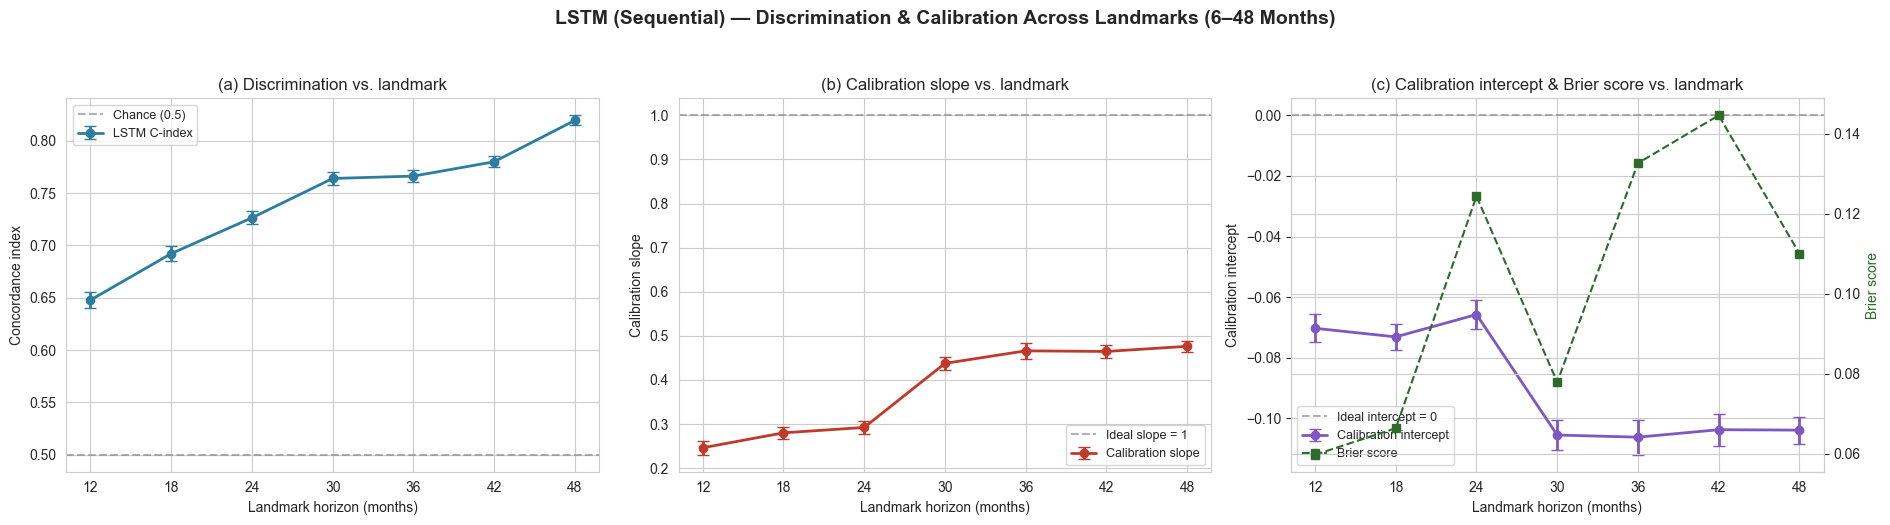

In [13]:
"""
Trend plots: how LSTM discrimination (C-index) and calibration (slope,
intercept, Brier score) move across the 6-48 month landmarks.
"""
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
xs = landmark_summary_df["Landmark (mo)"].values

ax = axes[0]
ax.errorbar(xs, landmark_summary_df["C-Index"], yerr=landmark_summary_df["C-Index SE"],
            fmt="o-", color="#2c7da0", capsize=4, lw=2, label="LSTM C-index")
ax.axhline(0.5, color="gray", ls="--", alpha=0.6, label="Chance (0.5)")
ax.set_xlabel("Landmark horizon (months)")
ax.set_ylabel("Concordance index")
ax.set_title("(a) Discrimination vs. landmark")
ax.set_xticks(xs)
ax.legend(fontsize=9)

ax = axes[1]
ax.errorbar(xs, landmark_summary_df["Cal. Slope"], yerr=landmark_summary_df["Cal. Slope SE"],
            fmt="o-", color="#c0392b", capsize=4, lw=2, label="Calibration slope")
ax.axhline(1.0, color="gray", ls="--", alpha=0.6, label="Ideal slope = 1")
ax.set_xlabel("Landmark horizon (months)")
ax.set_ylabel("Calibration slope")
ax.set_title("(b) Calibration slope vs. landmark")
ax.set_xticks(xs)
ax.legend(fontsize=9)

ax = axes[2]
ax.errorbar(xs, landmark_summary_df["Cal. Intercept"], yerr=landmark_summary_df["Cal. Intercept SE"],
            fmt="o-", color="#7e57c2", capsize=4, lw=2, label="Calibration intercept")
ax.axhline(0.0, color="gray", ls="--", alpha=0.6, label="Ideal intercept = 0")
ax2 = ax.twinx()
ax2.plot(xs, landmark_summary_df["Brier"], "s--", color="#2d6b2d", lw=1.5, label="Brier score")
ax2.set_ylabel("Brier score", color="#2d6b2d")
ax.set_xlabel("Landmark horizon (months)")
ax.set_ylabel("Calibration intercept")
ax.set_title("(c) Calibration intercept & Brier score vs. landmark")
ax.set_xticks(xs)
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=9, loc="best")

plt.suptitle("LSTM (Sequential) \u2014 Discrimination & Calibration Across Landmarks (6\u201348 Months)",
             y=1.04, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
plt.close()


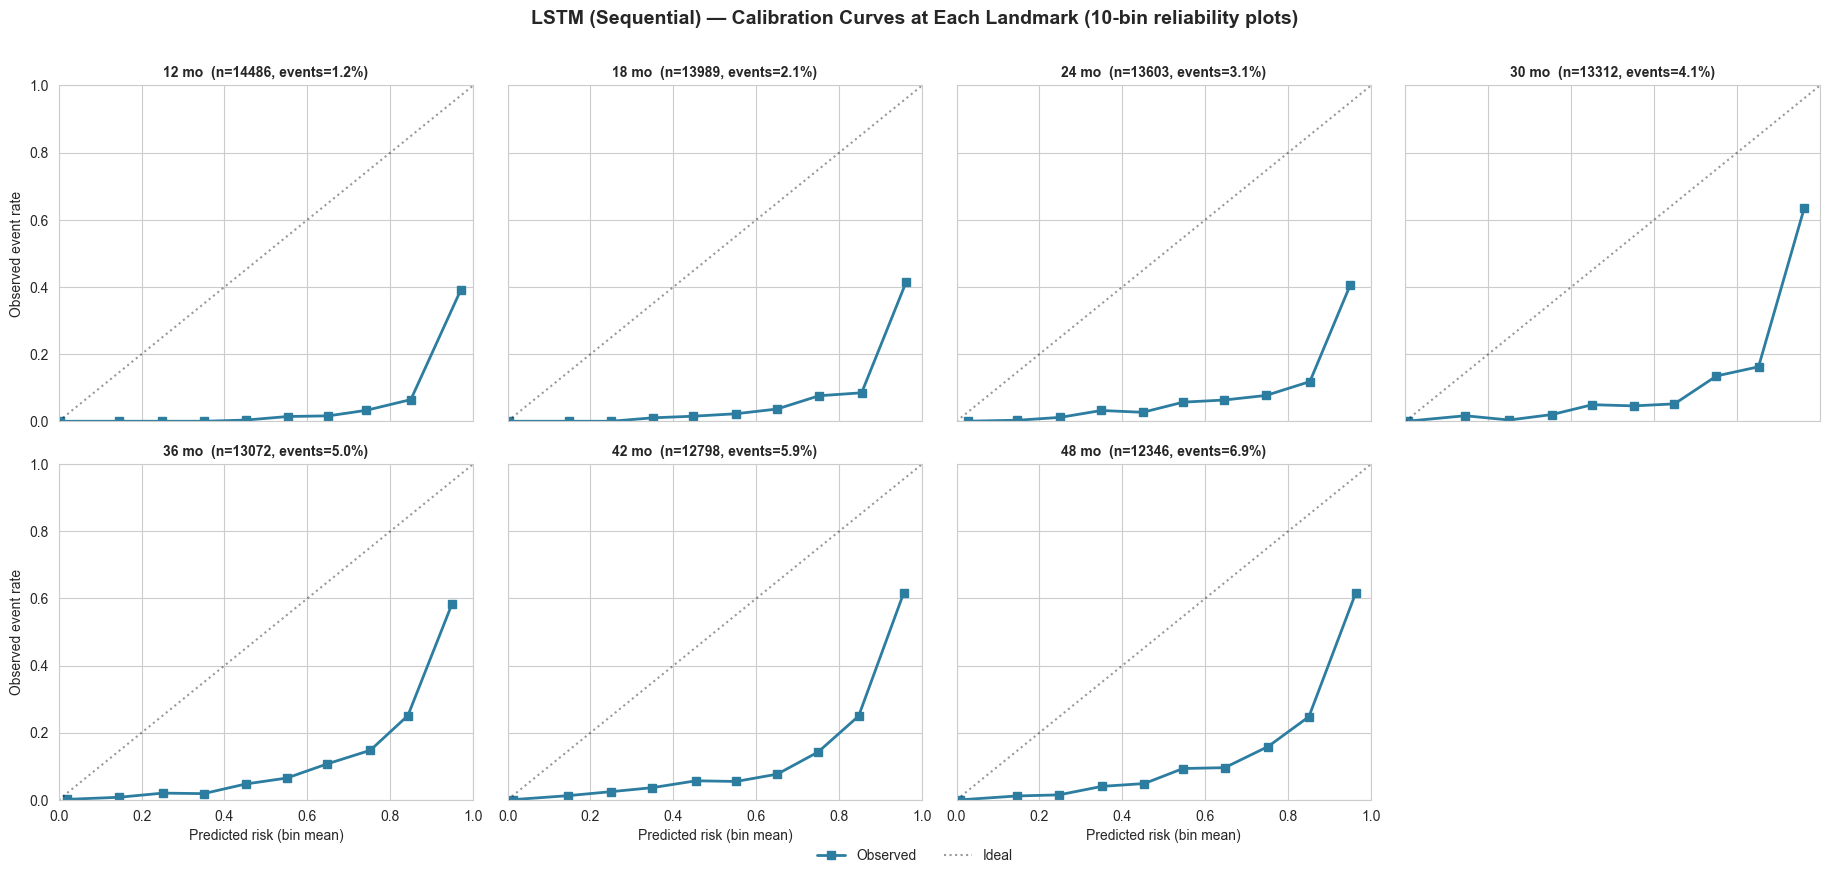

In [14]:
"""
Small-multiples reliability (calibration) plot: one panel per landmark, each
showing the observed vs. predicted event rate in 10 risk bins -- the same
`calibration_curve` construction used by `plot_risk_distribution_and_calibration`
above, just laid out side-by-side across horizons for direct comparison.
"""
import numpy as np
import matplotlib.pyplot as plt

ncols = 4
nrows = int(np.ceil(len(LANDMARK_MONTHS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 4.2 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, _m in zip(axes, LANDMARK_MONTHS):
    c = calibration_curves_by_landmark[_m]
    ax.plot(c["prob_pred"], c["prob_true"], "s-", color="#2c7da0", lw=2, label="Observed")
    ax.plot([0, 1], [0, 1], "k:", alpha=0.4, label="Ideal")
    ax.set_title(f"{_m} mo  (n={c['n']}, events={c['event_rate']:.1%})", fontsize=10, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

for ax in axes[len(LANDMARK_MONTHS):]:
    ax.set_visible(False)
for r in range(nrows):
    axes[r * ncols].set_ylabel("Observed event rate")
for c_i in range(ncols):
    idx = (nrows - 1) * ncols + c_i
    if idx < len(axes):
        axes[idx].set_xlabel("Predicted risk (bin mean)")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
plt.suptitle("LSTM (Sequential) \u2014 Calibration Curves at Each Landmark (10-bin reliability plots)",
             y=1.01, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
plt.close()
